# NFL Player Performance — Eksplorativna Analiza Podataka

Ovaj notebook predstavlja strukturiranu, kompletnu eksplorativnu analizu podataka za NFL igrače po pozicijama:

QB (quarterback), RB (running back), TE (tight end) i WR (wide receiver).

| Position | Data Source | Method |
|----------|-------------|--------|
| Quarterback | [Pro Football Reference](https://www.pro-football-reference.com) and [NFL Elo](https://www.nfeloapp.com/qb-rankings/) | Selenium web scraper and pre-built dataset |
| Running Back | [Pro Football Reference](https://www.pro-football-reference.com) | Selenium web scraper |
| Tight End | [Pro Football Reference](https://www.pro-football-reference.com) | Selenium web scraper |
| Wide Receiver | [HuggingFace / nflverse](https://huggingface.co/datasets/SebastianAndreu/24679_NFL_WR_Dataset_2025) | Pre-built dataset |

In [3]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from notebook_setup import *
from notebook_setup import setup
setup()

In [4]:
DATA_DIR = os.path.join("..", "data", "fully combined")

qb = pd.read_csv(os.path.join(DATA_DIR, "qb_master.csv"))
rb = pd.read_csv(os.path.join(DATA_DIR, "rb_master.csv"))
te = pd.read_csv(os.path.join(DATA_DIR, "te_master.csv"))
wr_seasons = pd.read_csv(os.path.join(DATA_DIR, "wr_all_seasons.csv"))

datasets = {
    "QB (qb_master)":          qb,
    "RB (rb_master)":          rb,
    "TE (te_master)":          te,
    "WR (wr_all_seasons)": wr_seasons,
}

print("Skupovi podataka uspešno učitani:\n")
for name, df in datasets.items():
    print(f"  {name:40s}    {df.shape[0]:>6} redova  ×  {df.shape[1]:>3} kolona")

Skupovi podataka uspešno učitani:

  QB (qb_master)                                 845 redova  ×  188 kolona
  RB (rb_master)                                 622 redova  ×  115 kolona
  TE (te_master)                                 351 redova  ×   70 kolona
  WR (wr_all_seasons)                           5529 redova  ×  102 kolona


- QB skup ima 845 redova i 188 kolona - najveći broj feature-a zbog kombinacije standardnih sezonskih statistika, naprednih passing metrika, ELO rejting komponenti i snap count podataka. Svaki red = jedna sezona jednog QB-a.
- RB skup ima 622 redova i 115 kolona - uključuje rushing i receiving statistike, napredne metrike poput broken tackles i YBC/YAC, te defensive i snap count kolone.
- TE skup je najmanji sa 351 reda i 70 kolona - fokusiran na receiving i rush statistike tight end-ova.
- WR Seasons je najobimniji skup sa 5.529 redova i 102 kolone - prikupljen iz nflverse/nflfastR izvora i sadrži kontekstualne varijable (situacione metrike, VP sekcije, vremenske uslove).

In [5]:
for name, df in datasets.items():
    print(f"{'_'*70}")
    print(f"  {name}")
    display(df.head(3))

______________________________________________________________________
  QB (qb_master)


,Player,PlayerID,Season,Age,Team,Pos,G,GS,QBrec,Cmp,Att,Cmp%,Yds,TD,TD%,Int,Int%,1D,Succ%,Lng,Y/A,AY/A,Y/C,Y/G,Rate,...,elo_QB Elo,elo_QBR,elo_Rushing,elo_Sacks,elo_Sacks.1,elo_Starts,elo_Success,elo_T,elo_TD%,elo_TD%-INT%,elo_TDs,elo_TDs.1,elo_Total,elo_Total WPA,elo_W,elo_WPA / DB,elo_YAC,elo_YPA,elo_YPC,elo_Yards,elo_Yards.1,elo_aDOT,elo_vs Sticks,Team_Changed,Prev_Season_Yds
0,Aaron Rodgers,RodgAa00,2005,22,GNB,QB,3,0,NaN,9,16,56.30,65,0,0.00,1,6.30,3,31.60,16.00,4.10,1.25,7.20,21.70,39.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.00
1,Aaron Rodgers,RodgAa00,2006,23,GNB,QB,2,0,NaN,6,15,40.00,46,0,0.00,0,0.00,2,16.70,16.00,3.10,3.07,7.70,23.00,48.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,65.00
2,Aaron Rodgers,RodgAa00,2007,24,GNB,QB,2,0,NaN,20,28,71.40,218,1,3.60,0,0.00,9,45.20,43.00,7.80,8.50,10.90,109.00,106.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,46.00


______________________________________________________________________
  RB (rb_master)


,Player,PlayerID,Season,Age,Team,Lg,Pos,G,GS,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,Rush_Succ%,Rush_Lng,Rush_Y/A,Rush_Y/G,Rush_A/G,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,Rec_Succ%,...,def_FR_TD,def_FR_Yds,def_Fmb,def_PD,def_QBHits,def_Sfty,def_Sk,def_Solo,def_TFL,def_Tkl_Ast,def_Tkl_Comb,def_Tkl_Solo,def_safety_md,def_tackles_loss,snp_Def%,snp_Def_Snaps,snp_Off%,snp_Off_Snaps,snp_ST%,snp_ST_Snaps,snp_defense,snp_offense,snp_special_teams,Team_Changed,Prev_Season_Yds
0,Aaron Jones,JoneAa00,2017,23,GNB,NaN,RB,12,4,81,448,4,23,53.10,46.00,5.50,37.30,6.80,18,9,22,2.40,0,2,11.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0%,0.00,31%,236.00,10%,32.00,NaN,NaN,NaN,0,0.00
1,Aaron Jones,JoneAa00,2018,24,GNB,NaN,RB,12,8,133,728,8,41,54.90,67.00,5.50,60.70,11.10,35,26,206,7.90,1,12,51.40,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0%,0.00,48%,376.00,6%,19.00,NaN,NaN,NaN,0,448.00
2,Aaron Jones,JoneAa00,2019,25,GNB,NaN,RB,16,16,236,1084,16,55,54.20,56.00,4.60,67.80,14.80,68,49,474,9.70,3,18,47.10,...,0.00,0.00,3.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0%,0.00,62%,663.00,0%,0.00,NaN,NaN,NaN,0,728.00


______________________________________________________________________
  TE (te_master)


,Player,PlayerID,Season,Age,Team,Pos,G,GS,Tgt,Rec,Rec_Yds,Rec_Y/R,Rec_TD,Rec_1D,Rec_Succ%,Rec_Lng,Rec/G,Rec_Y/G,Catch%,Rec_Y/Tgt,Rush_Att,Rush_Yds,Rush_TD,Rush_1D,Rush_Y/G,...,adv_Rec_PassRtg,adv_Rec_YAC,adv_Rec_YAC/R,adv_Rec_YBC,adv_Rec_YBC/R,adv_Rec_Yds,adv_Rec_aDOT,adv_Rush_1D,adv_Rush_Att,adv_Rush_Att/Br,adv_Rush_BrkTkl,adv_Rush_BrkTkl/A,adv_Rush_YAC,adv_Rush_YAC/A,adv_Rush_YBC,adv_Rush_YBC/A,adv_Rush_Yds,snp_Def%,snp_Def_Snaps,snp_Off%,snp_Off_Snaps,snp_ST%,snp_ST_Snaps,Team_Changed,Prev_Season_Yds
0,Antonio Gates,GateAn00,2003,23,SDG,TE,15,11,42,24,389,16.20,2,19,52.40,48.00,1.60,25.90,57.10,9.30,0,0,0,0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.00
1,Antonio Gates,GateAn00,2004,24,SDG,TE,15,15,114,81,964,11.90,13,55,63.20,72.00,5.40,64.30,71.10,8.50,0,0,0,0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,389.00
2,Antonio Gates,GateAn00,2005,25,SDG,TE,15,15,140,89,1101,12.40,10,62,53.60,38.00,5.90,73.40,63.60,7.90,0,0,0,0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,964.00


______________________________________________________________________
  WR (wr_all_seasons)


,receiver_player_id,receiver_player_name,season,games_played,posteam,targets,receptions,receiving_yards,air_yards,yac,tds,red_zone_targets,end_zone_targets,third_down_targets,fourth_down_targets,high_leverage_targets,explosive_plays,first_downs,second_and_long_targets,third_and_medium_targets,lost_yards_due_to_penalty,yards_Q1,yards_Q2,yards_Q3,yards_Q4,...,leading_pct,wp_var,target_share_std,temp_f,humidity_pct,wind_mph,success_rate,big_play_rate,reception_std,avg_start_yardline,avg_target_depth_vs_qb,pregame_spread,pregame_total,passer_player_id,surface,is_dome,is_rain,is_snow,is_clear,defteam,home_team,away_team,player_team,team_changed,prev_season_rec_yds
0,00-0019596,T.Brady,2015,1,22,1.00,1.00,36.00,7.00,29.00,0.00,0,0,1,0,1,1.00,1.00,0.00,0.00,0.00,0.00,0.00,36.00,0.00,...,1.00,0.00,0.02,52.00,49.00,5.00,1.00,1.00,0.00,75.00,0.00,9.50,49.50,00-0026035,4.00,0.00,0.00,0.00,1.00,26.00,22.00,26.00,PHI,0,0.00
1,00-0019596,T.Brady,2017,1,22,1.00,0.00,0.00,7.00,0.00,0.00,0,0,1,0,0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,3.00,0.00,0.00,0.00,0.00,0.00,35.00,0.00,4.50,48.50,00-0026035,3.00,1.00,0.00,0.00,1.00,26.00,22.00,26.00,PHI,0,36.00
2,00-0019596,T.Brady,2018,1,22,1.00,1.00,6.00,0.00,6.00,0.00,0,0,1,0,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.00,...,1.00,0.00,0.01,46.00,42.00,4.00,1.00,0.00,0.00,43.00,0.00,-6.00,47.00,00-0027150,2.00,0.00,0.00,0.00,1.00,31.00,31.00,22.00,NE,1,0.00


### Opis pojedinih kolona po skupu podataka

---

#### QB 

| Kolona | Opis |
|--------|------|
| `Player` / `Season` | Identifikacija igrača i sezone |
| `G` / `GS` | Odigrane utakmice / startovi |
| `Cmp` / `Att` / `Cmp%` | Kompletirana dodavanja / pokušaji / procenat |
| `Yds` / `TD` / `Int` | Passing jardi / touchdowni / interceptions |
| `Y/A` | Jardi po pokušaju |
| `Rate` | NFL Passer Rating |
| `QBR` | ESPN Total QBR (0-100, napredna metrika) |
| `adv_pass_*` | Napredne passing metrike (air yards, pressure, play-action itd.) |
| `elo_*` | ELO rejting komponente (CPOE, WPA, rushing itd.) |
| `snp_Off%` | Procenat offensive snapova |

---

#### RB 

| Kolona | Opis |
|--------|------|
| `Player`  / `Season` | Identifikacija igrača i sezone |
| `Rush_Att` / `Rush_Yds` / `Rush_TD` | Rushing pokušaji / jardi / touchdowni |
| `Rush_Y/A` | Jardi po pokušaju (yards per carry) |
| `Rec` / `Rec_Yds` / `Rec_TD` | Receiving statistike |
| `Scrimmage_Yds` / `Touches` | Ukupni jardi i dodiri lopte (rush + rec) |
| `adv_Rush_BrkTkl` | Broken tackles |
| `adv_Rush_YBC` / `adv_Rush_YAC` | Yards before/after contact |


---

#### TE 

| Kolona | Opis |
|--------|------|
| `Player`  / `Season` | Identifikacija igrača i sezone |
| `G` / `GS` | Odigrane utakmice / startovi |
| `Tgt` / `Rec` / `Rec_Yds` / `Rec_TD` | Targeti / hvatanja / jardi / touchdowni |
| `Rec_Y/R` | Jardi po hvatanju |
| `catch_pct` | Procenat uhvacenih targeta |
| `adv_ADOT` | Average Depth of Target (prosecna dubina targeta) |
| `adv_Rec_YAC` / `adv_Rec_YBC` | Yards after catch / yards before contact |

---

#### WR Seasons

| Kolona | Opis |
|--------|------|
| `receiver_player_name` / `season` | Identifikacija igrača i sezone |
| `targets` / `receptions` / `receiving_yards` / `tds` | Osnovne receiving statistike |
| `catch_rate` / `target_share` | Efikasnost i udeo u timskim targetima |
| `adot` | Average Depth of Target (prosecna dubina targeta) |
| `air_yards` / `yac` | Air jardi i yards after catch |
| `epa` / `wpa` | Expected Points Added / Win Probability Added |
| `red_zone_targets` | Targeti u red zone |
| `temp_f` / `wind_mph` / `surface` | Vremenski uslovi i tip terena |
| `yards_Q1/Q2/Q3/Q4` / `receptions_Q1/.../Q4` | Situacioni splitovi po kvartalu i win probability bucketima |
| `pregame_spread` / `pregame_total` | Kontekstualni podaci - spread, total |

In [6]:
rows = []
for name, df in datasets.items():
    for dtype, count in df.dtypes.value_counts().items():
        rows.append({"Pozicija": name.split("(")[0].strip(), "Tip": str(dtype), "Broj kolona": count})

result = pd.DataFrame(rows).pivot_table(index="Pozicija", columns="Tip", values="Broj kolona", fill_value=0).astype(int)
result.index.name = None
result.columns.name = None
display(result)

,float64,int64,object
QB,163,16,9
RB,91,15,9
TE,43,19,8
WR,81,17,4


- Većina kolona su tipa `float64` - numeričke statistike sa mogućim `NaN` vrednostima.
- Kategorijske kolone poput `Player`, `Team`, `PlayerID`, `surface`, `awards` itd. su tipa `object` (string).

---
## Analiza Nedostajućih Vrednosti

Pregled ukupnog broja i procenta `NaN` vrednosti po skupu podataka, kao i vizualizacija kolona s najviše nedostajućih vrednosti.

In [7]:
# Sažetna tabela nedostajućih vrednosti po skupu
null_summary = []
for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    total_nulls = df.isnull().sum().sum()
    cols_with_nulls = (df.isnull().sum() > 0).sum()
    null_summary.append({
        "Skup": name.split("(")[0].strip(),
        "Ukupno ćelija": total_cells,
        "Null ćelija": total_nulls,
        "Null %": round(total_nulls / total_cells * 100, 2),
        "Kolona s nullovima": cols_with_nulls,
        "Ukupno kolona": df.shape[1],
    })

display(pd.DataFrame(null_summary))

,Skup,Ukupno ćelija,Null ćelija,Null %,Kolona s nullovima,Ukupno kolona
0,QB,158860,57521,36.21,167,188
1,RB,71530,33089,46.26,92,115
2,TE,24570,7085,28.84,46,70
3,WR,563958,0,0.00,0,102


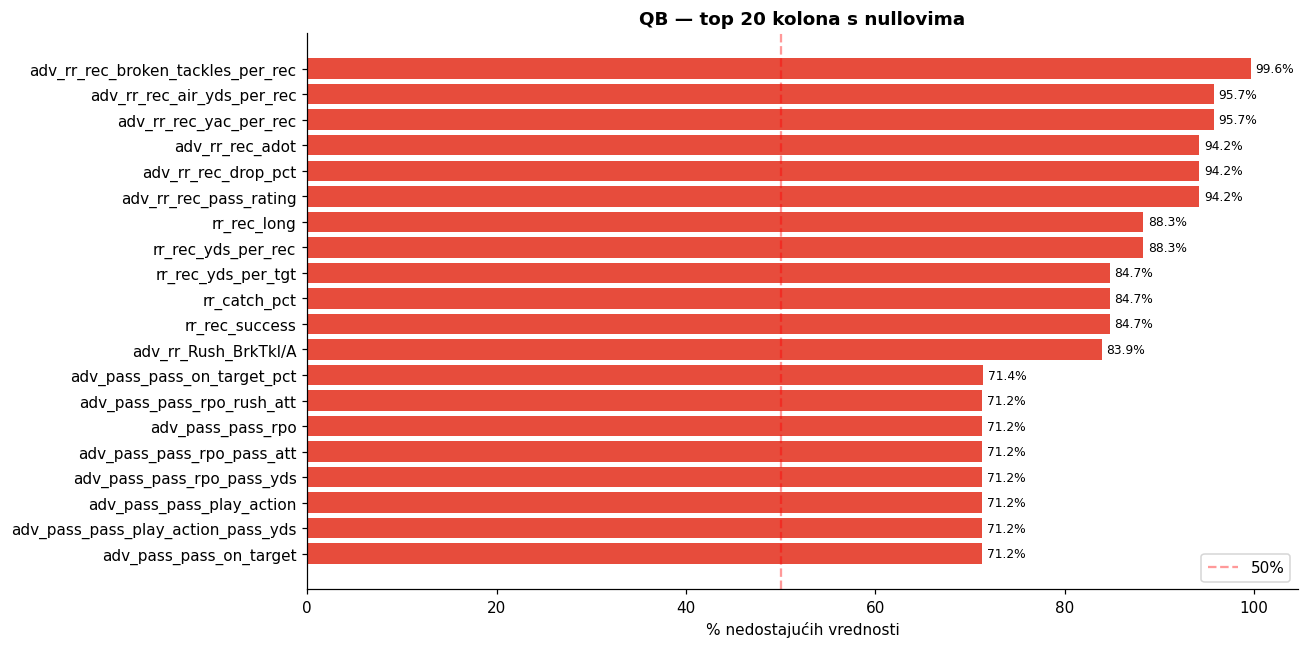

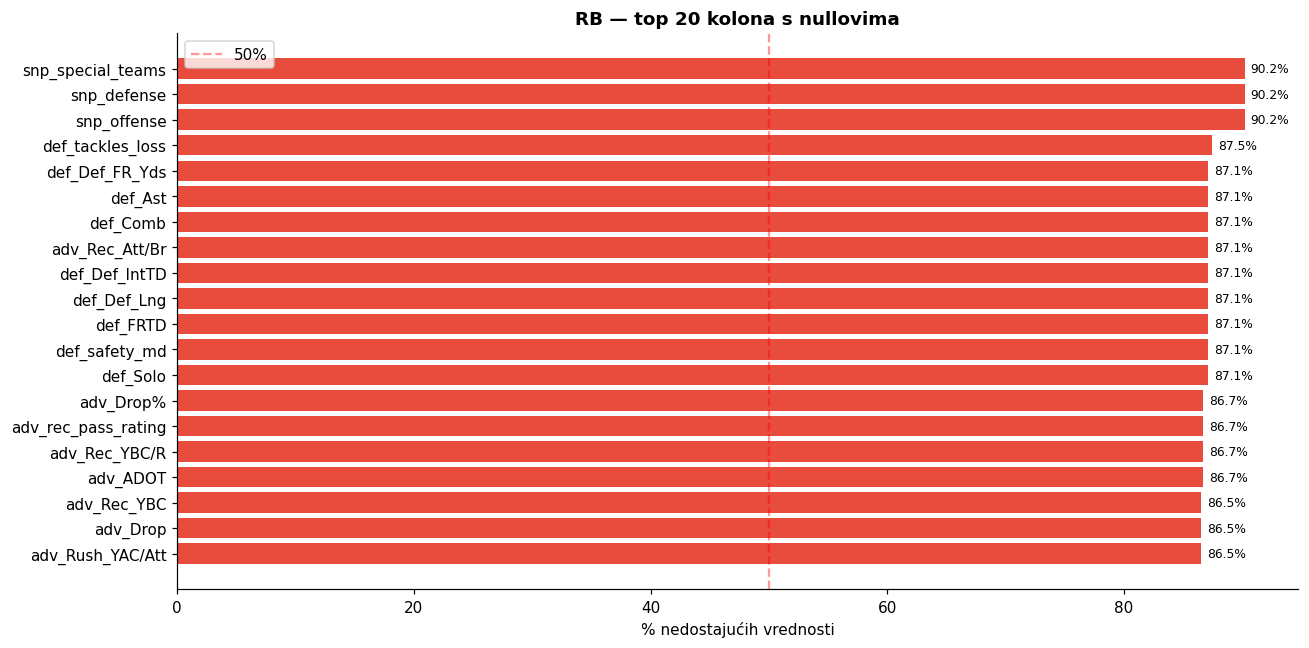

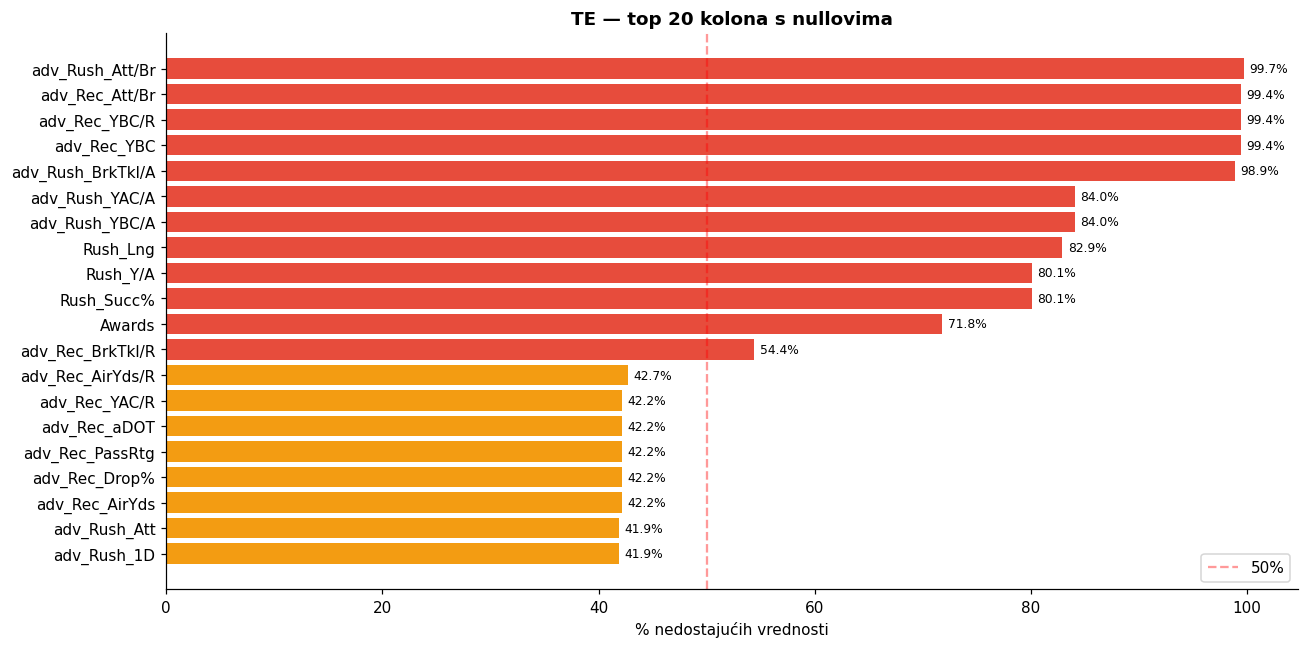

WR: nema nedostajućih vrednosti.


In [8]:
# Vizualizacija top 20 kolona s najviše nullova po skupu
def plot_missing(df, name, top_n=20):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0].sort_values(ascending=False).head(top_n)
    if null_pct.empty:
        print(f"{name}: nema nedostajućih vrednosti.")
        return
    fig, ax = plt.subplots(figsize=(12, max(3, len(null_pct) * 0.3)))
    colors = ["#e74c3c" if v >= 50 else "#f39c12" if v >= 10 else "#2ecc71" for v in null_pct.values]
    ax.barh(null_pct.index[::-1], null_pct.values[::-1], color=colors[::-1])
    ax.axvline(50, color="red", linestyle="--", alpha=0.4, label="50%")
    ax.set_xlabel("% nedostajućih vrednosti")
    ax.set_title(f"{name} — top {len(null_pct)} kolona s nullovima", fontweight="bold")
    ax.legend()
    for i, v in enumerate(null_pct.values[::-1]):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_missing(df, name.split("(")[0].strip())

Visok procenat null vrednosti u ovim kolonama nije greška u podacima - to je posledica prirode same pozicije. Statistike koje za neku poziciju gotovo i ne postoje jednostavno neće biti popunjene.


 Na primer, QB skupu kolone poput `adv_rr_rec_drop_pct` ili `adv_rr_rec_yac_per_rec` odnose se na receiving metrike — QB praktično nikad nije targetovan kao receiver, pa su te vrednosti null.


Ove kolone su u skupu podataka prisutne jer se koristi isti šablon kolekcije podataka za sve igrače, ali pri modeliranju će biti isključene ili ignorisane kao nebitne za predviđanje performansi te pozicije.

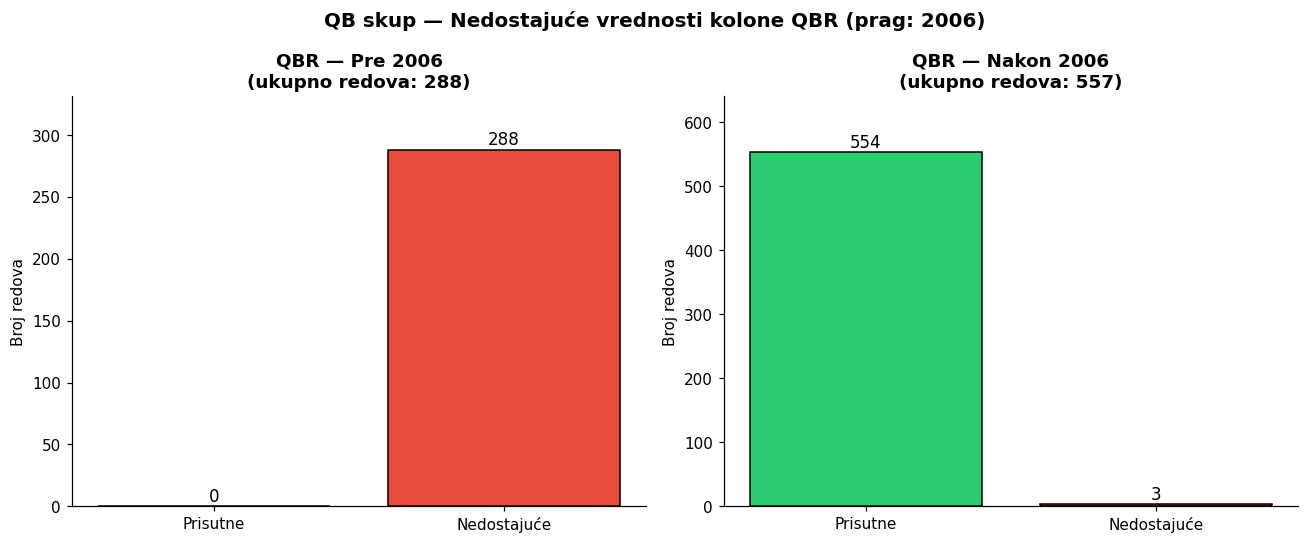

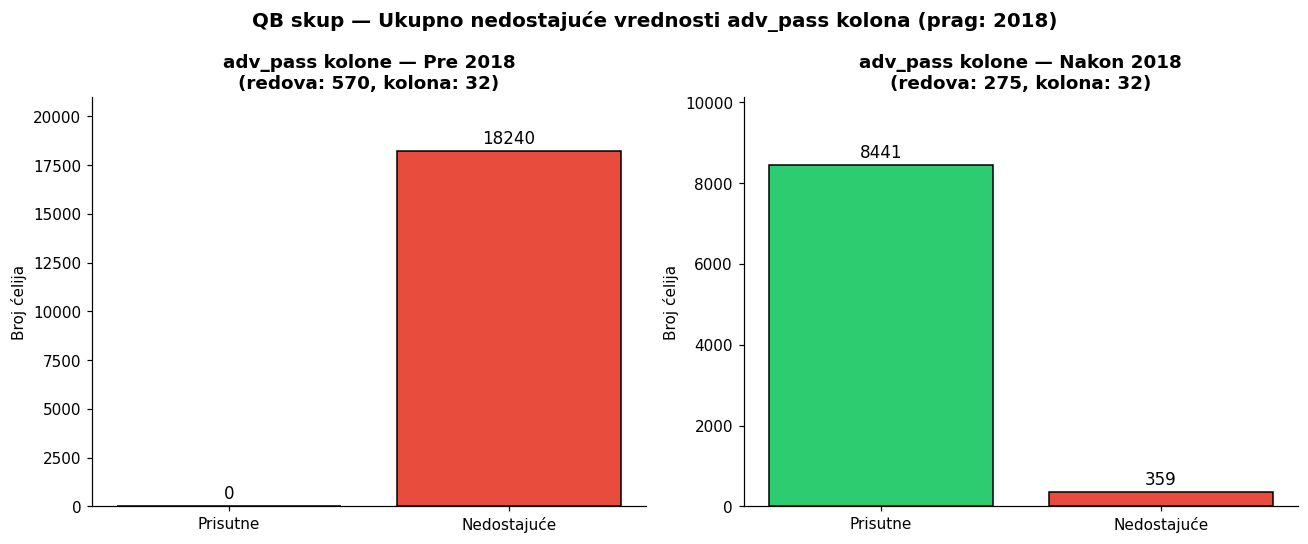

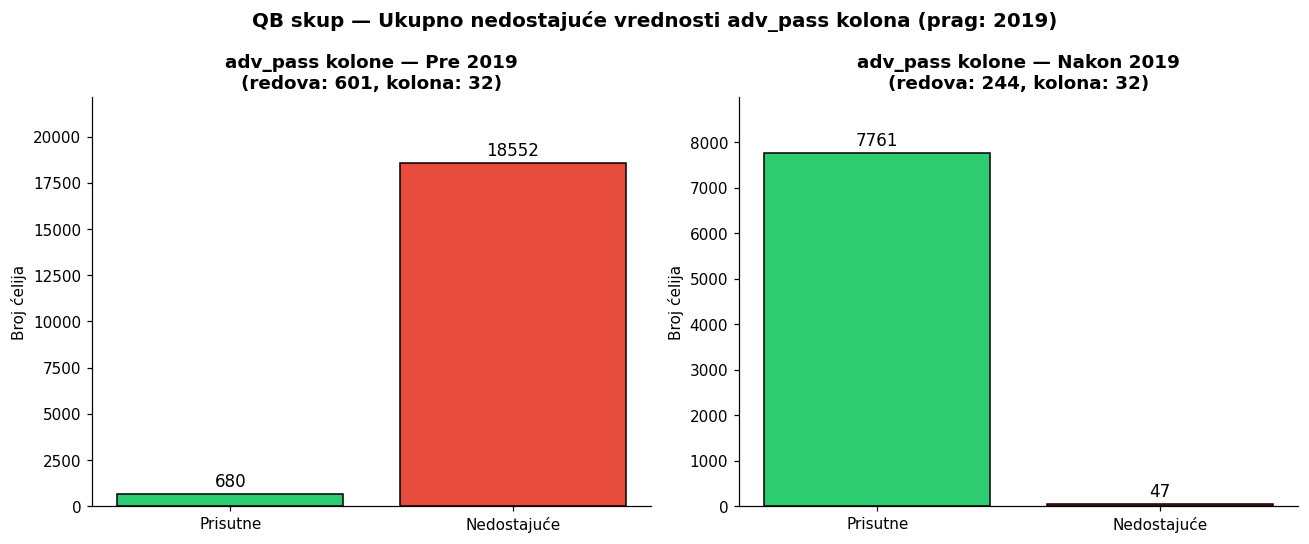

In [9]:

adv_pass_cols = [c for c in qb.columns if c.startswith("adv_pass")]

# QBR: broj nedostajućih vrednosti pre i nakon 2006 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, mask) in zip(axes, [("Pre 2006", qb["Season"] < 2006), ("Nakon 2006", qb["Season"] >= 2006)]):
    subset = qb[mask]
    missing = subset["QBR"].isnull().sum()
    present = subset["QBR"].notnull().sum()
    ax.bar(["Prisutne", "Nedostajuće"], [present, missing], color=["#2ecc71", "#e74c3c"], edgecolor="black")
    ax.set_title(f"QBR — {label}\n(ukupno redova: {len(subset)})", fontweight="bold")
    ax.set_ylabel("Broj redova")
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
    ax.set_ylim(0, len(subset) * 1.15)

fig.suptitle("QB skup — Nedostajuće vrednosti kolone QBR (prag: 2006)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# adv_pass kolone: ukupan broj nedostajućih vrednosti za različite pragove
def plot_adv_pass_missing(year):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (label, mask) in zip(axes, [(f"Pre {year}", qb["Season"] < year), (f"Nakon {year}", qb["Season"] >= year)]):
        subset = qb[mask]
        total_cells = len(subset) * len(adv_pass_cols)
        total_missing = subset[adv_pass_cols].isnull().sum().sum()
        total_present = total_cells - total_missing
        ax.bar(["Prisutne", "Nedostajuće"], [total_present, total_missing], color=["#2ecc71", "#e74c3c"], edgecolor="black")
        ax.set_title(f"adv_pass kolone — {label}\n(redova: {len(subset)}, kolona: {len(adv_pass_cols)})", fontweight="bold")
        ax.set_ylabel("Broj ćelija")
        for bar in ax.patches:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total_cells * 0.01,
                    str(int(bar.get_height())), ha="center", va="bottom", fontsize=11)
        ax.set_ylim(0, total_cells * 1.15)
    fig.suptitle(f"QB skup — Ukupno nedostajuće vrednosti adv_pass kolona (prag: {year})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

for year in [2018, 2019]:
    plot_adv_pass_missing(year)




QBR (prag: 2006)

ESPN Total QBR metrika uvedena je 2006. godine, što objašnjava zašto svih 288 QB sezona pre 2006. nema QBR vrednost (100% null). Nakon 2006. samo 3 od 557 redova nemaju QBR. Ovo je strukturalni nedostatak podataka uslovljen datumom uvođenja metrike, a ne greškom u prikupljanju.

---
adv_pass kolone (prag: 2018)

Pro Football Reference je 2018. godine uveo prvi set naprednih passing statistika (`adv_pass` kolone). Pre te godine nijedna od ovih kolona nije postojala, pa je prisutnost podataka za sezone pre 2018. ravna 0% - svi redovi su null. Nakon 2018. većina `adv_pass` kolona je popunjena, što potvrđuje da se radi o strukturalnom nedostatku vezanom za datum uvođenja metrika, a ne o greškama u prikupljanju.

---
adv_pass kolone (prag: 2019)

Iako su napredne passing statistike uvedene 2018., skup kolona je proširen 2019. godine dodatnim metrikama. Kolone poput play action yards, play action attempts, run-pass option (RPO) attempts i yards, on-target throws, on-target throw % i druge nisu postojale u sezoni 2018. i počele su se bežiti tek od 2019. To objašnjava zašto grafik s pragom 2019. pokazuje još manji broj nedostajućih vrednosti  - jer su sve `adv_pass` kolone (uključujući i one dodane 2019.) tada potpuno dostupne, dok u sezoni 2018. te novije kolone još uvek imaju null vrednosti.


# Distribucija ciljnih varjiabli

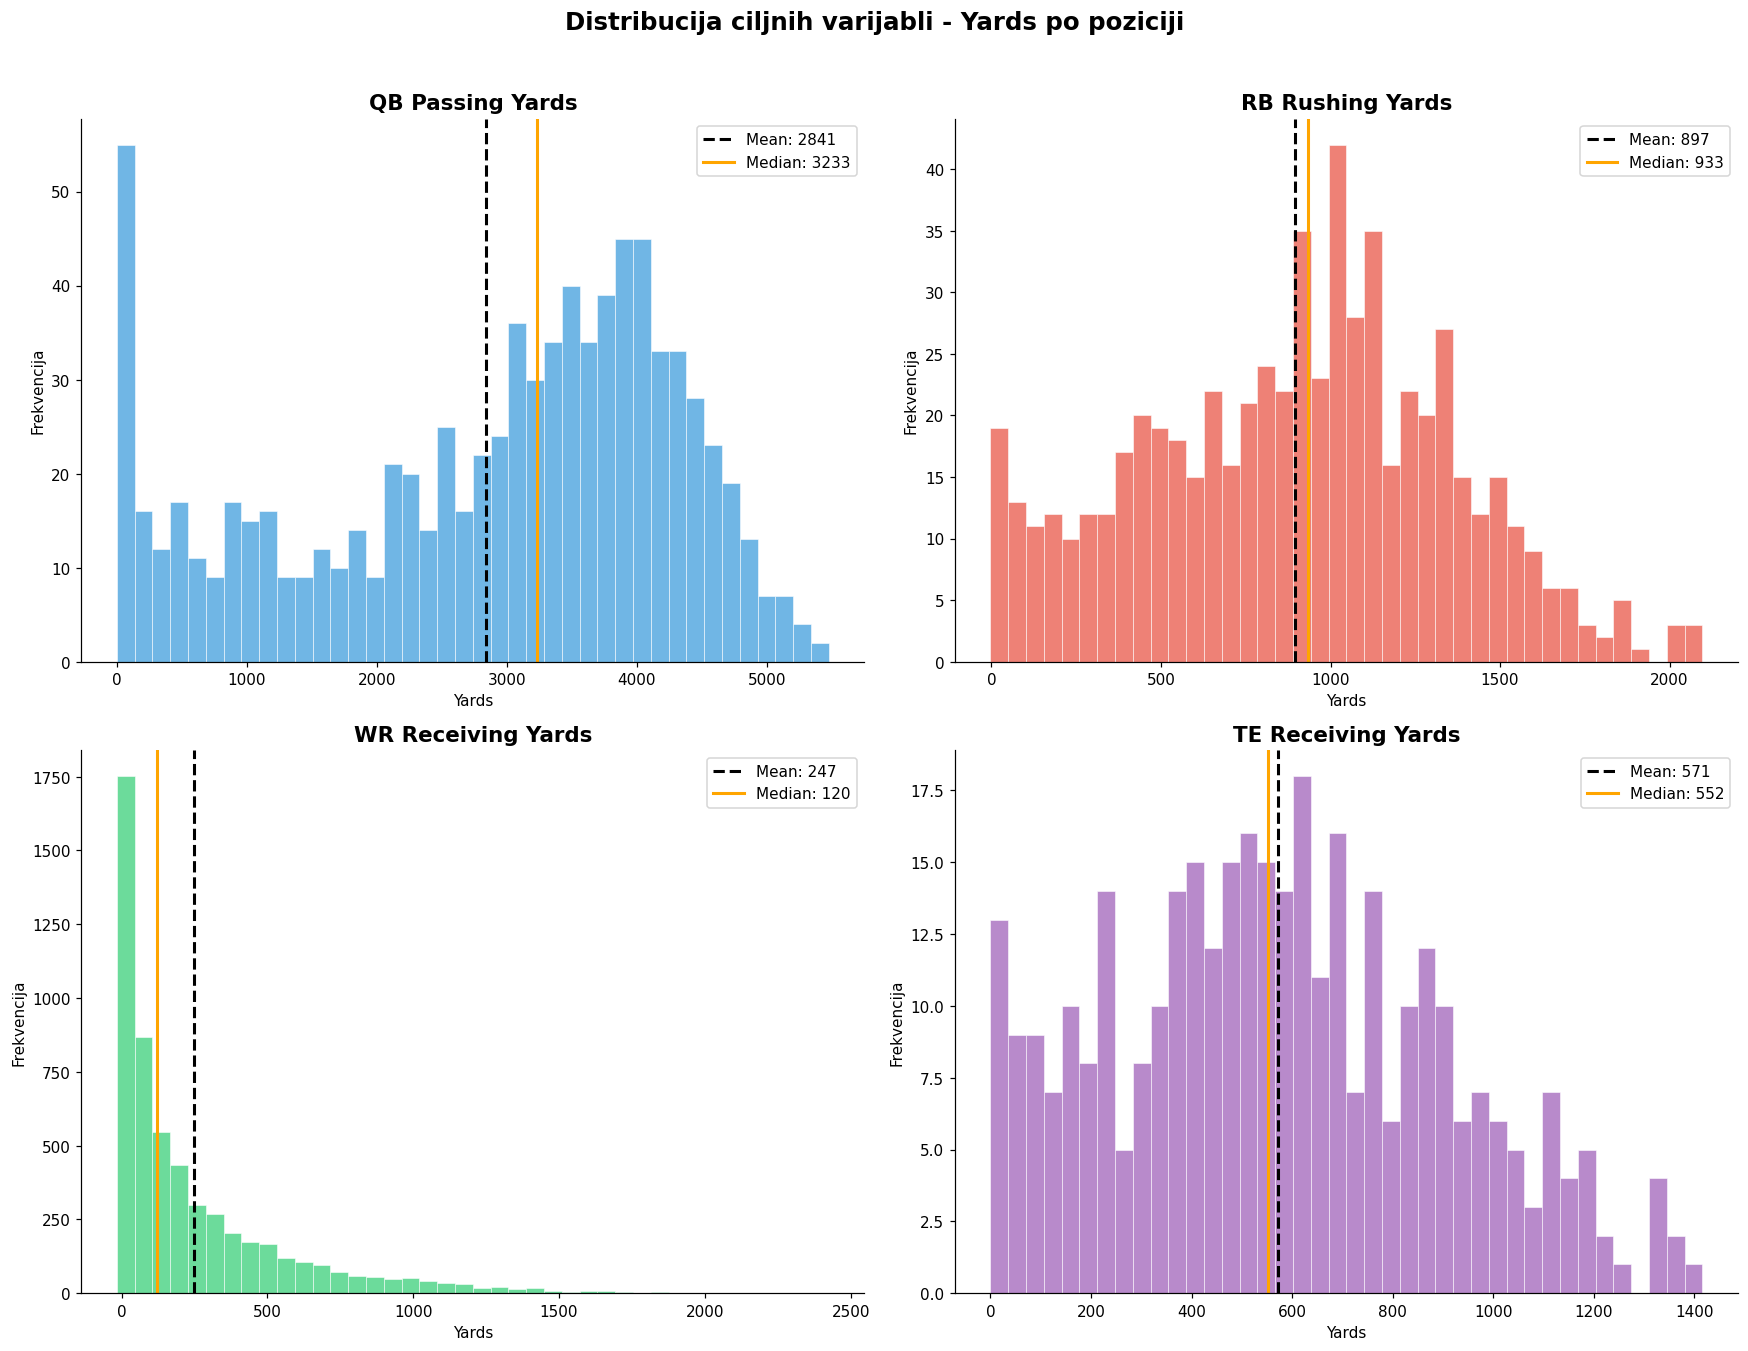

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_data = [
    (qb, 'Yds', 'QB Passing Yards', '#3498db'),
    (rb, 'Rush_Yds', 'RB Rushing Yards', '#e74c3c'),
    (wr_seasons, 'receiving_yards', 'WR Receiving Yards', '#2ecc71'),
    (te, 'Rec_Yds', 'TE Receiving Yards', '#9b59b6')
]

for ax, (df, col, title, color) in zip(axes.flat, plot_data):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {data.median():.0f}')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Yards')
    ax.set_ylabel('Frekvencija')
    ax.legend(fontsize=10)

fig.suptitle('Distribucija ciljnih varijabli - Yards po poziciji', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


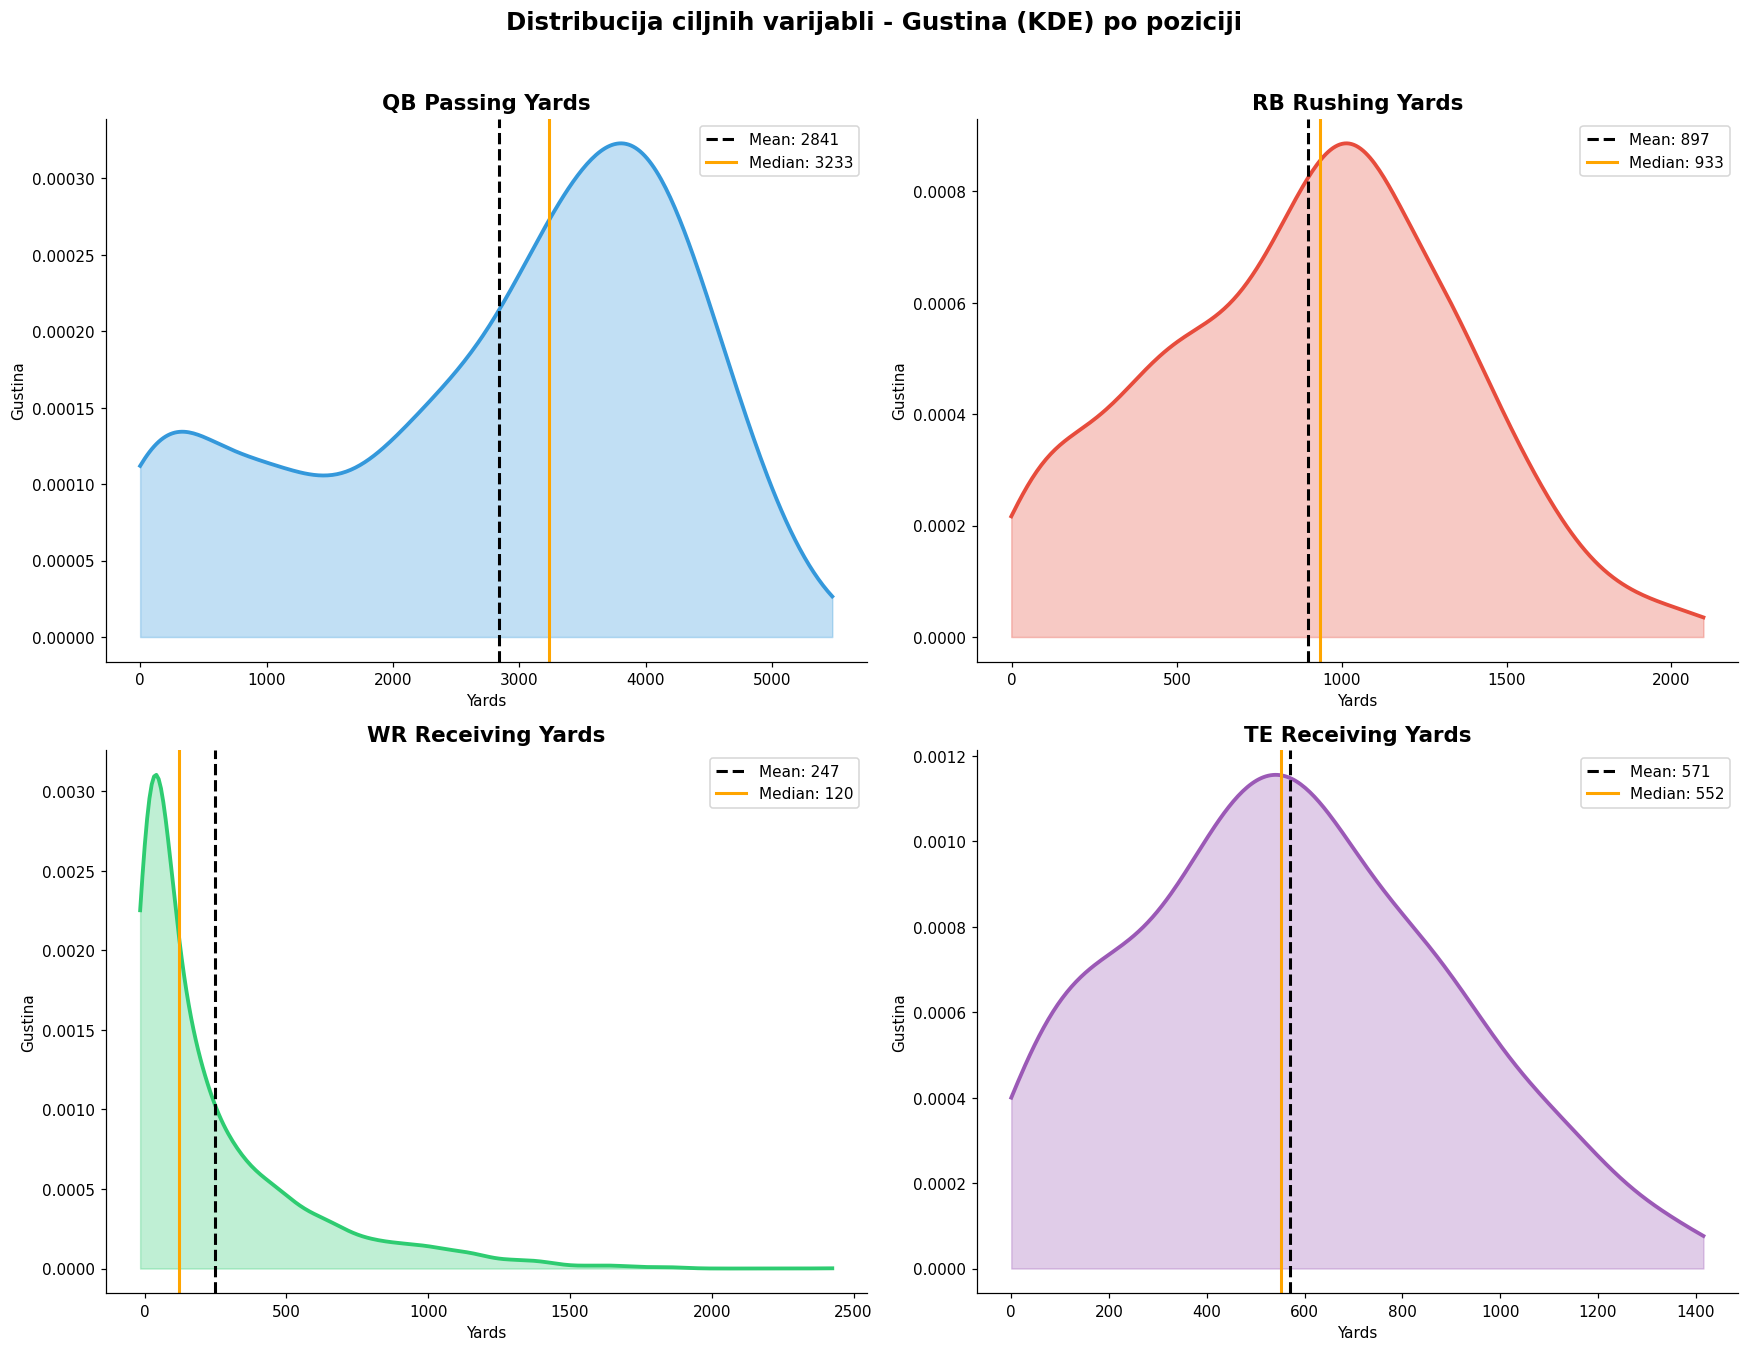

In [11]:
from scipy.stats import gaussian_kde
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_data = [
    (qb, 'Yds', 'QB Passing Yards', '#3498db'),
    (rb, 'Rush_Yds', 'RB Rushing Yards', '#e74c3c'),
    (wr_seasons, 'receiving_yards', 'WR Receiving Yards', '#2ecc71'),
    (te, 'Rec_Yds', 'TE Receiving Yards', '#9b59b6')
]

for ax, (df, col, title, color) in zip(axes.flat, plot_data):
    data = df[col].dropna()
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.3, color=color)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {data.median():.0f}')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Yards')
    ax.set_ylabel('Gustina')
    ax.legend(fontsize=10)

fig.suptitle('Distribucija ciljnih varijabli - Gustina (KDE) po poziciji', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


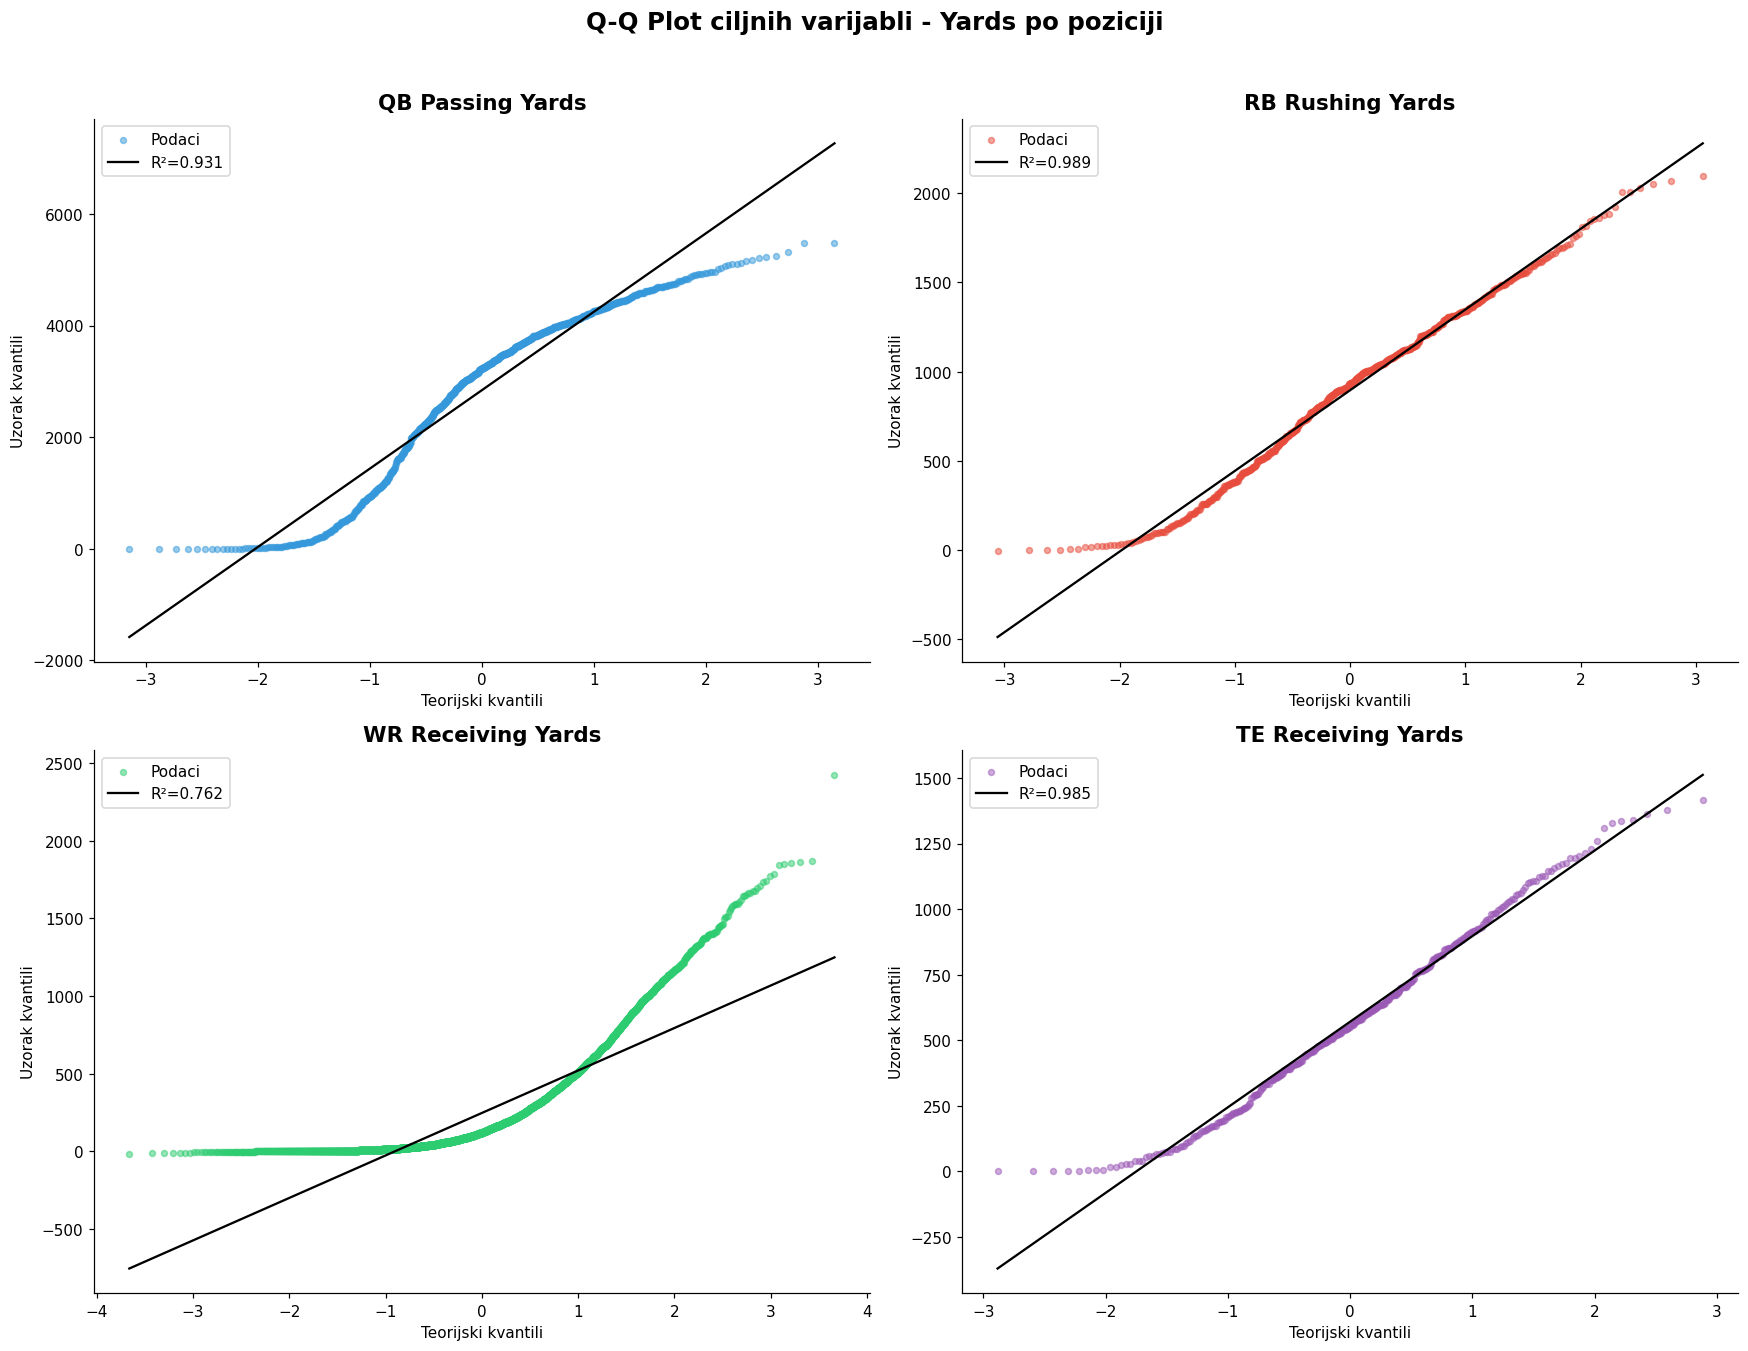

In [12]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_data = [
    (qb, 'Yds', 'QB Passing Yards', '#3498db'),
    (rb, 'Rush_Yds', 'RB Rushing Yards', '#e74c3c'),
    (wr_seasons, 'receiving_yards', 'WR Receiving Yards', '#2ecc71'),
    (te, 'Rec_Yds', 'TE Receiving Yards', '#9b59b6')
]

for ax, (df, col, title, color) in zip(axes.flat, plot_data):
    data = df[col].dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    ax.scatter(osm, osr, color=color, alpha=0.5, s=15, label='Podaci')
    ax.plot(osm, slope * np.array(osm) + intercept, color='black', linewidth=1.5, label=f'R²={r**2:.3f}')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Teorijski kvantili')
    ax.set_ylabel('Uzorak kvantili')
    ax.legend(fontsize=10)

fig.suptitle('Q-Q Plot ciljnih varijabli - Yards po poziciji', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Analiza distribucije ciljnih varijabli

---

RB (Rushing Yards) i TE (Receiving Yards) pokazuju približno normalnu distribuciju — većina igrača se grupiše oko proseka, sa simetričnim repovima. Q-Q plotovi to potvrđuju visokim R² vrednostima (RB ≈ 0.99, TE ≈ 0.98), što znači da su ove varijable pogodne za linearnu regresiju bez transformacija.


QB (Passing Yards) pokazuje bimodalnu distribuciju — pored glavnog vrha (starteri sa 2500-4500 jardi), postoji sekundarni vrh blizu 0-500 jardi. Ovaj drugi vrh nastaje zbog backup QB-ova i igrača koji su se povredili, pa imaju jako mali broj odigranih utakmica. Bez tih zapisa, distribucija bi bila približno normalna. Ovim outlierima ćemo se posvetiti u sekciji za obradu outliera.

WR (Receiving Yards) ima izrazito desno nagnutu (right-skewed) distribuciju — veliki broj igrača sa minimalnom ulogom (mali broj targeta, malo jardi) i mali broj elitnih receivera koji akumuliraju ogromne jardaže. Ovo je tipičan power-law obrazac u sportu. Mean je značajno veći od medijana, što potvrđuje pozitivni skew. Za modelovanje, primenjujemo logaritamsku transformaciju kako bismo normalizovali distribuciju.

| Pozicija | Tip distribucije | Predvidivost (Normalnost) | Ključna karakteristika |
|----------|-------------------|---------------------------|------------------------|
| QB | Bimodalna | Srednja (R²≈0.93) | Jasna podela na startere i rezerve |
| RB | Normalna | Visoka (R²≈0.99) | Najstabilnija varijabla za linearnu regresiju |
| WR | Power-law / Skewed | Niska (R²≈0.76) | Veliki jaz između elite i ostatka lige |
| TE | Normalna  | Visoka (R²≈0.98) | Konzistentan učinak većine igrača |


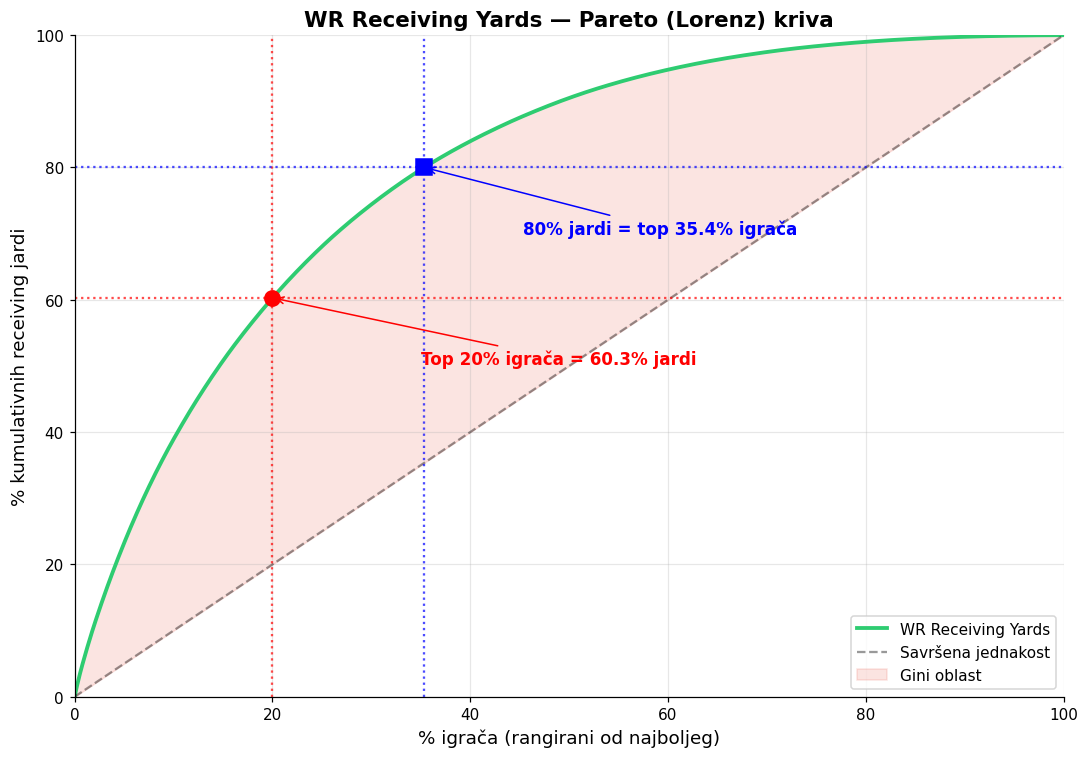

In [13]:
# Pareto analiza: koliko % jardi drži top X% igrača (po sezoni agregirano)
wr_yds_sorted = wr_seasons['receiving_yards'].dropna().sort_values(ascending=False).values
wr_yds_sorted = wr_yds_sorted[wr_yds_sorted > 0]

total_yds = wr_yds_sorted.sum()
cumulative_yds = np.cumsum(wr_yds_sorted) / total_yds
player_pct = np.arange(1, len(wr_yds_sorted) + 1) / len(wr_yds_sorted)

# Tačne vrednosti za 80/20
idx_20 = np.searchsorted(player_pct, 0.20)  # indeks gde je 20% igrača
yds_by_top20 = cumulative_yds[idx_20] * 100

# Koliko % igrača treba za 80% jardi
idx_80 = np.searchsorted(cumulative_yds, 0.80)
pct_for_80 = player_pct[idx_80] * 100

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(player_pct * 100, cumulative_yds * 100, color='#2ecc71', linewidth=2.5, label='WR Receiving Yards')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Savršena jednakost')

# 20% linija
ax.axvline(20, color='red', linestyle=':', alpha=0.7)
ax.axhline(yds_by_top20, color='red', linestyle=':', alpha=0.7)
ax.plot(20, yds_by_top20, 'ro', markersize=10)
ax.annotate(f'Top 20% igrača = {yds_by_top20:.1f}% jardi',
            xy=(20, yds_by_top20), xytext=(35, yds_by_top20 - 10),
            fontsize=11, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

# 80% linija
ax.axhline(80, color='blue', linestyle=':', alpha=0.7)
ax.axvline(pct_for_80, color='blue', linestyle=':', alpha=0.7)
ax.plot(pct_for_80, 80, 'bs', markersize=10)
ax.annotate(f'80% jardi = top {pct_for_80:.1f}% igrača',
            xy=(pct_for_80, 80), xytext=(pct_for_80 + 10, 70),
            fontsize=11, color='blue', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='blue'))

ax.fill_between(player_pct * 100, cumulative_yds * 100, player_pct * 100, alpha=0.15, color='#e74c3c', label='Gini oblast')

ax.set_xlabel('% igrača (rangirani od najboljeg)', fontsize=12)
ax.set_ylabel('% kumulativnih receiving jardi', fontsize=12)
ax.set_title('WR Receiving Yards — Pareto (Lorenz) kriva', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Lorenzova kriva potvrđuje izrazitu nejednakost u WR produkciji: top 20% receivera akumulira oko 60% svih receiving jardi, dok je za 80% ukupne jardaže dovoljno samo oko 35% najboljih igrača. Velika površina između krive i linije savršene jednakosti (Gini oblast) ukazuje na visok Gini koeficijent, što znači da mali broj elitnih receivera dominira metrikom, dok većina igrača (donjih 60-70%) ima zanemariv doprinos. 

Ovo nije tačan Pareto odnos 80/20, ali je veoma blizu i tipično je za visokokonkurentne sisteme poput profesionalnog sporta. Za modelovanje, to znači da će predviđanja biti precizna za igrače u gornjem delu distribucije, ali nepouzdana za igrače van top 35% - što opravdava primenu log transformacije.


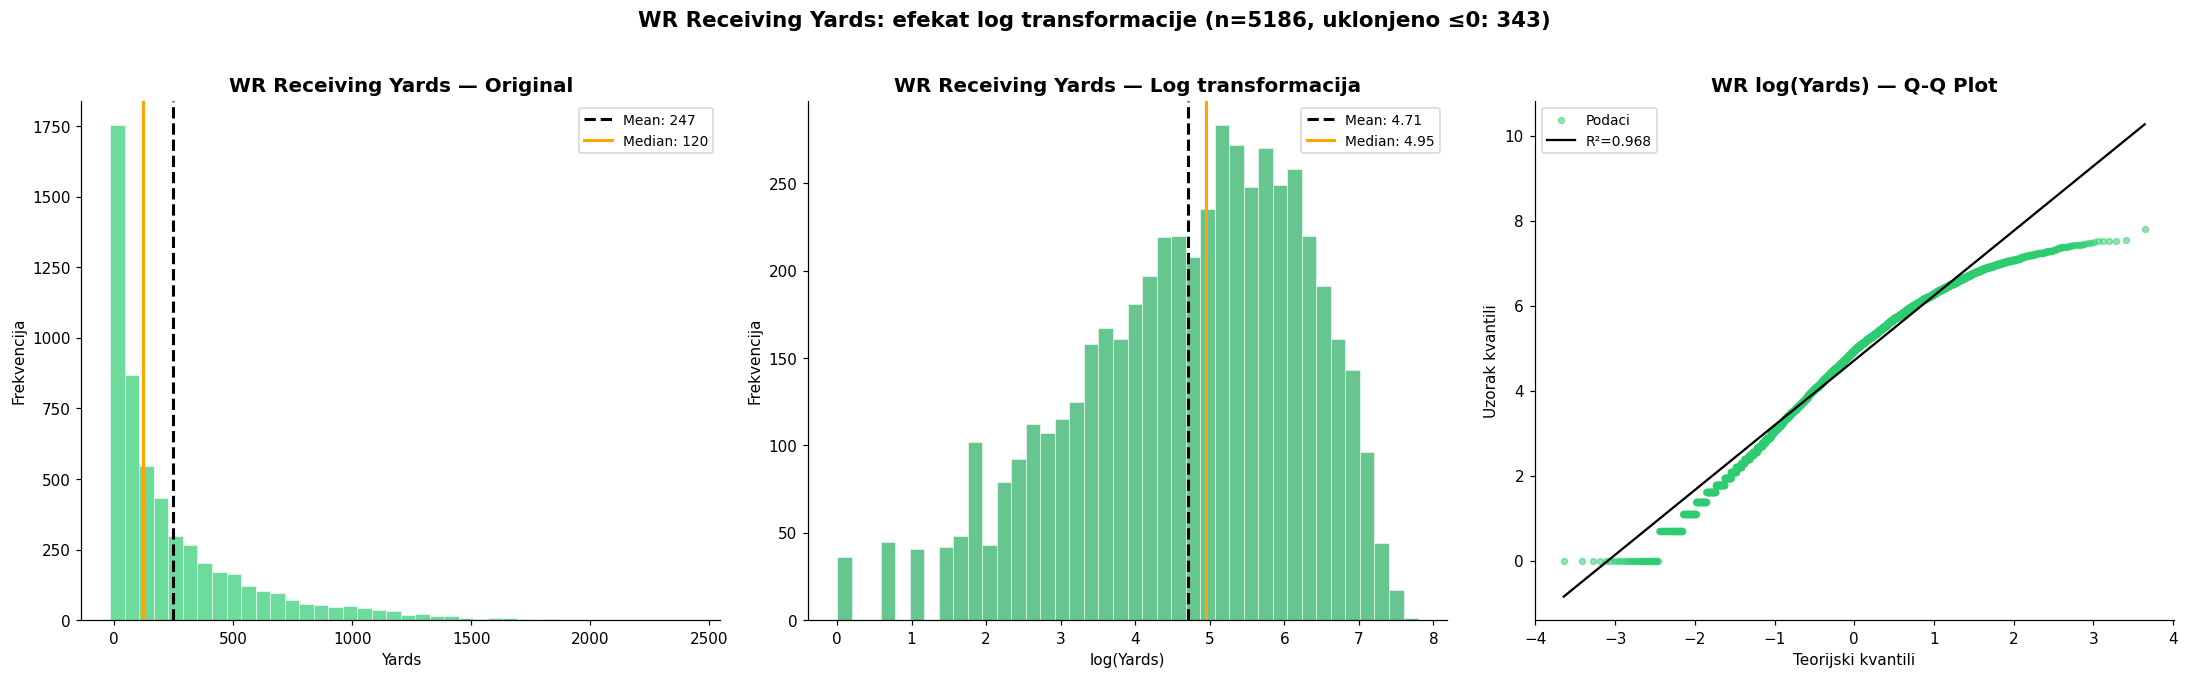

R² pre:  0.762
R² nakon:  0.968


In [14]:
# Log transformacija WR receiving yards
wr_yds = wr_seasons['receiving_yards'].dropna()
wr_yds_positive = wr_yds[wr_yds > 0]
wr_yds_log = np.log(wr_yds_positive)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Original histogram
axes[0].hist(wr_yds, bins=40, color='#2ecc71', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[0].axvline(wr_yds.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {wr_yds.mean():.0f}')
axes[0].axvline(wr_yds.median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {wr_yds.median():.0f}')
axes[0].set_title('WR Receiving Yards — Original', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Yards')
axes[0].set_ylabel('Frekvencija')
axes[0].legend(fontsize=9)

# 2) Log-transformed histogram
axes[1].hist(wr_yds_log, bins=40, color='#27ae60', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[1].axvline(wr_yds_log.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {wr_yds_log.mean():.2f}')
axes[1].axvline(wr_yds_log.median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {wr_yds_log.median():.2f}')
axes[1].set_title('WR Receiving Yards — Log transformacija', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Yards)')
axes[1].set_ylabel('Frekvencija')
axes[1].legend(fontsize=9)

# 3) Q-Q plot log-transformed
(osm, osr), (slope, intercept, r) = stats.probplot(wr_yds_log, dist="norm")
axes[2].scatter(osm, osr, color='#2ecc71', alpha=0.5, s=15, label='Podaci')
axes[2].plot(osm, slope * np.array(osm) + intercept, color='black', linewidth=1.5, label=f'R²={r**2:.3f}')
axes[2].set_title('WR log(Yards) — Q-Q Plot', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Teorijski kvantili')
axes[2].set_ylabel('Uzorak kvantili')
axes[2].legend(fontsize=9)

fig.suptitle(f'WR Receiving Yards: efekat log transformacije (n={len(wr_yds_positive)}, uklonjeno ≤0: {len(wr_yds) - len(wr_yds_positive)})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"R² pre:  {stats.probplot(wr_yds, dist='norm')[1][2]**2:.3f}")
print(f"R² nakon:  {r**2:.3f}")


---
## Analiza i Tretman Outliera

U ovom poglavlju:
1. Detekcija outliera pomoću Z-score (|z| > 3) i IQR metode (1.5×IQR) na ukupnim jardima po poziciji.
2. Vizualizacija — boxplotovi i scatter plotovi s označenim outlierima.
3. Tretman QB bimodalne distribucije — uklanjanje rezervnih QB-ova (GS = 0) i prelazak na *jarde po utakmici* umesto ukupnih sezonskih jardi, kako se ne bi kažnjavali igrači koji su se povredili ili propustili deo sezone.
4. WR log transformacija — outlier detekcija na log(receiving_yards) umesto sirovih vrednosti.
5. Primena per-game normalizacije na sve pozicije radi fer usporedbe.

### 1. Detekcija outliera — Z-score vs IQR (sirove ukupne yarde)

Primjenjujemo dve klasične metode na ukupne sezonske jarde svake pozicije:
- Z-score: outlier ako |z| > 3 (više od 3 standardne devijacije od proseka).
- IQR: outlier ako je vrednost ispod Q1 − 1.5·IQR ili iznad Q3 + 1.5·IQR.

In [15]:
from scipy.stats import zscore

# Konfiguracija: pozicija → (DataFrame, kolona s jardima)
outlier_targets = {
    "QB": (qb,         "Yds"),
    "RB": (rb,         "Rush_Yds"),
    "TE": (te,         "Rec_Yds"),
    "WR": (wr_seasons, "receiving_yards"),
}

z_threshold = 3

z_rows = []
iqr_rows = []

for pos, (df, col) in outlier_targets.items():
    s = df[col].dropna()

    # --- Z-score ---
    z = (s - s.mean()) / s.std()
    n_z = (z.abs() > z_threshold).sum()
    z_rows.append({"Pozicija": pos, "Kolona": col, "N": len(s),
                   "Outliera (|z|>3)": n_z, "% outliera": round(n_z / len(s) * 100, 2)})

    # --- IQR ---
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr_val = q3 - q1
    lower, upper = q1 - 1.5 * iqr_val, q3 + 1.5 * iqr_val
    n_iqr = ((s < lower) | (s > upper)).sum()
    iqr_rows.append({"Pozicija": pos, "Kolona": col, "N": len(s),
                     "Q1": round(q1, 1), "Q3": round(q3, 1), "IQR": round(iqr_val, 1),
                     "Donja granica": round(lower, 1), "Gornja granica": round(upper, 1),
                     "Outliera": n_iqr, "% outliera": round(n_iqr / len(s) * 100, 2)})

z_summary = pd.DataFrame(z_rows)
iqr_summary = pd.DataFrame(iqr_rows)

print("Z-score detekcija (|z| > 3):")
display(z_summary)
print("\nIQR detekcija (1.5 × IQR):")
display(iqr_summary)

Z-score detekcija (|z| > 3):


,Pozicija,Kolona,N,Outliera (|z|>3),% outliera
0,QB,Yds,845,0,0.00
1,RB,Rush_Yds,622,0,0.00
2,TE,Rec_Yds,351,0,0.00
3,WR,receiving_yards,5529,114,2.06



IQR detekcija (1.5 × IQR):


,Pozicija,Kolona,N,Q1,Q3,IQR,Donja granica,Gornja granica,Outliera,% outliera
0,QB,Yds,845,1799.00,3983.00,2184.00,-1477.00,7259.00,0,0.00
1,RB,Rush_Yds,622,554.50,1213.20,658.80,-433.60,2201.40,0,0.00
2,TE,Rec_Yds,351,335.00,805.00,470.00,-370.00,1510.00,0,0.00
3,WR,receiving_yards,5529,30.00,345.00,315.00,-442.50,817.50,391,7.07


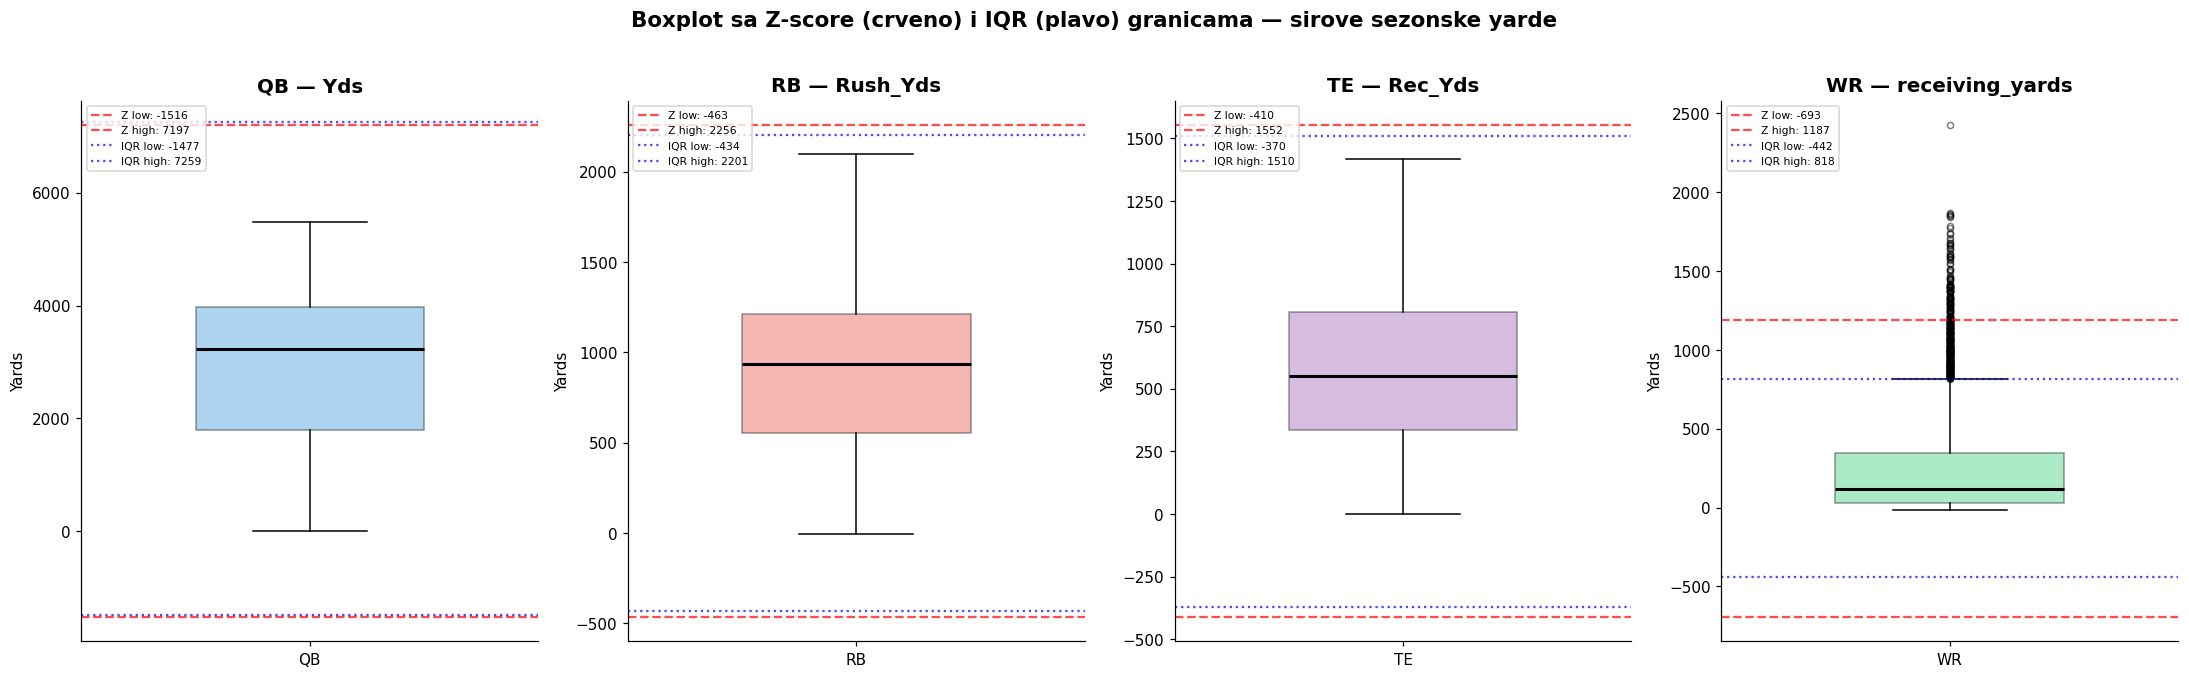

In [16]:
# Boxplot + strip plot za svaku poziciju (sirove yarde)
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

colors = {'QB': '#3498db', 'RB': '#e74c3c', 'TE': '#9b59b6', 'WR': '#2ecc71'}

for ax, (pos, (df, col)) in zip(axes, outlier_targets.items()):
    s = df[col].dropna()

    # IQR granice
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr_val = q3 - q1
    lower, upper = q1 - 1.5 * iqr_val, q3 + 1.5 * iqr_val

    # Z-score granice
    z_low = s.mean() - z_threshold * s.std()
    z_high = s.mean() + z_threshold * s.std()

    bp = ax.boxplot(s, vert=True, widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor=colors[pos], alpha=0.4),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))

    # Z-score linije
    ax.axhline(z_low, color='red', linestyle='--', alpha=0.7, label=f'Z low: {z_low:.0f}')
    ax.axhline(z_high, color='red', linestyle='--', alpha=0.7, label=f'Z high: {z_high:.0f}')

    # IQR linije
    ax.axhline(lower, color='blue', linestyle=':', alpha=0.7, label=f'IQR low: {lower:.0f}')
    ax.axhline(upper, color='blue', linestyle=':', alpha=0.7, label=f'IQR high: {upper:.0f}')

    ax.set_title(f'{pos} — {col}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Yards')
    ax.set_xticklabels([pos])
    ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Boxplot sa Z-score (crveno) i IQR (plavo) granicama — sirove sezonske yarde',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Zapažanja iz inicijalne detekcije

Na sirovim sezonskim jardima, ni Z-score ni IQR ne detektuju outliere kod QB i RB - jer bimodalna (QB) i široka distribucija razvlače standardnu devijaciju i IQR toliko da sve tačke ostaju unutar granica.

Kod WR IQR detektuje čak 391 (7%) outliera, ali to su u stvari legitimni igrači s visokom produkcijom - problem je u desno nagnutojem (skewed) distribuciji. 

Problem: sirove sezonske yarde mešaju dva različita efekta:
1. Kvalitet igrača - koliko je dobar po utakmici
2. Kvantitet nastupa - koliko utakmica je odigrao (povrede, rezerve)

Zato u sljedećem koraku:
- QB: uklanjamo sezone gdje igrač nije nijednom startovao (GS = 0 → čisti backup-i), a zatim koristimo Yds / G (jardi po utakmici) da normalizujemo za povrede
- RB, TE: koristimo per-game normalizaciju (Rush_Yds / G, Rec_Yds / G**)
- WR: primenjujemo log transformaciju na receiving_yards, a zatim detektujemo outliere na log skali

### 2. Tretman QB bimodalne distribucije

QB distribucija ukupnih jardi ima dva vrha: jedan oko 0–500 (backup QB-ovi koji nikad nisu startovali) i drugi oko 3000–4500 (regularni starteri). Backup-i koji nisu nijednom startovali (GS = 0) nemaju smislenu sezonsku statistiku za predviđanje performansi i trebaju biti isključeni.

Za preostale QB-ove (koji su barem jednom startovali), koristimo Yds / G (jardi po odigranoj utakmici) umesto ukupnih sezonskih jardi. Ovo osigurava da igrači koji su se povredili ili propustili deo sezone ne budu nepravedno klasifikovani kao outlieri.

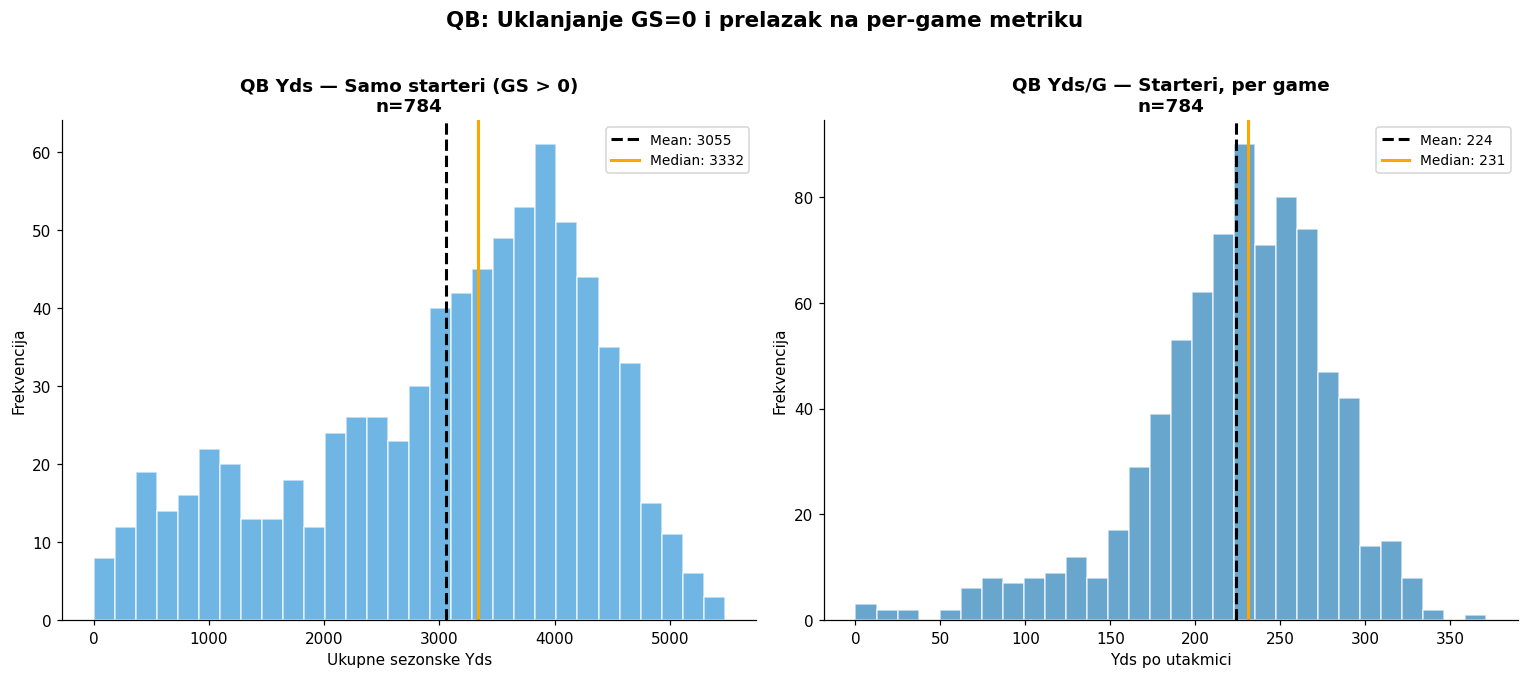

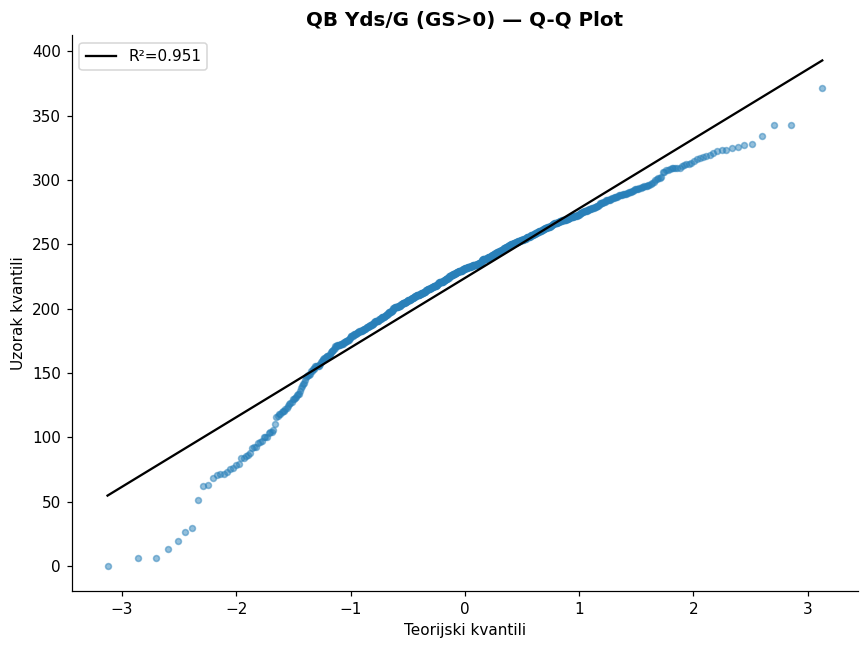

R² (Yds/G, GS>0): 0.951


In [17]:
# QB: bimodalna distribucija — filtriranje GS=0 i per-game normalizacija
qb_gs0 = qb[qb['GS'] == 0]['Yds'].dropna()
qb_gs_pos = qb[qb['GS'] > 0]['Yds'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1) Samo GS > 0 — ukupne yarde
axes[0].hist(qb_gs_pos, bins=30, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(qb_gs_pos.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {qb_gs_pos.mean():.0f}')
axes[0].axvline(qb_gs_pos.median(), color='orange', linewidth=2, label=f'Median: {qb_gs_pos.median():.0f}')
axes[0].set_title(f'QB Yds — Samo starteri (GS > 0)\nn={len(qb_gs_pos)}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ukupne sezonske Yds')
axes[0].set_ylabel('Frekvencija')
axes[0].legend(fontsize=9)

# 2) GS > 0 — Yds per game
qb_starter = qb[qb['GS'] > 0].copy()
qb_starter['Yds_per_G'] = qb_starter['Yds'] / qb_starter['G']
ypg = qb_starter['Yds_per_G'].dropna()

axes[1].hist(ypg, bins=30, color='#2980b9', alpha=0.7, edgecolor='white')
axes[1].axvline(ypg.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {ypg.mean():.0f}')
axes[1].axvline(ypg.median(), color='orange', linewidth=2, label=f'Median: {ypg.median():.0f}')
axes[1].set_title(f'QB Yds/G — Starteri, per game\nn={len(ypg)}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Yds po utakmici')
axes[1].set_ylabel('Frekvencija')
axes[1].legend(fontsize=9)

fig.suptitle('QB: Uklanjanje GS=0 i prelazak na per-game metriku', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Q-Q plot: Yds per game
fig2, ax = plt.subplots(figsize=(8, 6))

(osm_p, osr_p), (slope, intercept, r_pg) = stats.probplot(ypg, dist="norm")
ax.scatter(osm_p, osr_p, color='#2980b9', alpha=0.5, s=15)
ax.plot(osm_p, slope * np.array(osm_p) + intercept, color='black', linewidth=1.5, label=f'R²={r_pg**2:.3f}')
ax.set_title('QB Yds/G (GS>0) — Q-Q Plot', fontweight='bold', fontsize=13)
ax.set_xlabel('Teorijski kvantili')
ax.set_ylabel('Uzorak kvantili')
ax.legend()

plt.tight_layout()
plt.show()
print(f"R² (Yds/G, GS>0): {r_pg**2:.3f}")

Uklanjanje 61 QB sezone (GS=0, 7.2%) eliminira prvi vrh bimodalne distribucije. Preostala distribucija je unimodalna sa blagim levim repom (igrači koji su startovali ali se povredili rano u sezoni). 

Prelazak na Yds/G dodatno normalizuje tu razliku: sad svaka sezona predstavlja prosječne performanse po utakmici, bez obzira koliko utakmica je igrač propustio. R² raste sa 0.948 na 0.951, potvrđujući bolji fit na normalnu distribuciju.





### 3. WR: Outlier detekcija na log(receiving_yards)

Kako je prethodno ustanovljeno, WR distribucija je izrazito right-skewed. Log transformacija normalizuje distribuciju, pa outlier detekcija na log skali daje smislenije rezultate - izdvaja samo zaista ekstremne sezone, ne čitavu gornju polovinu lige.

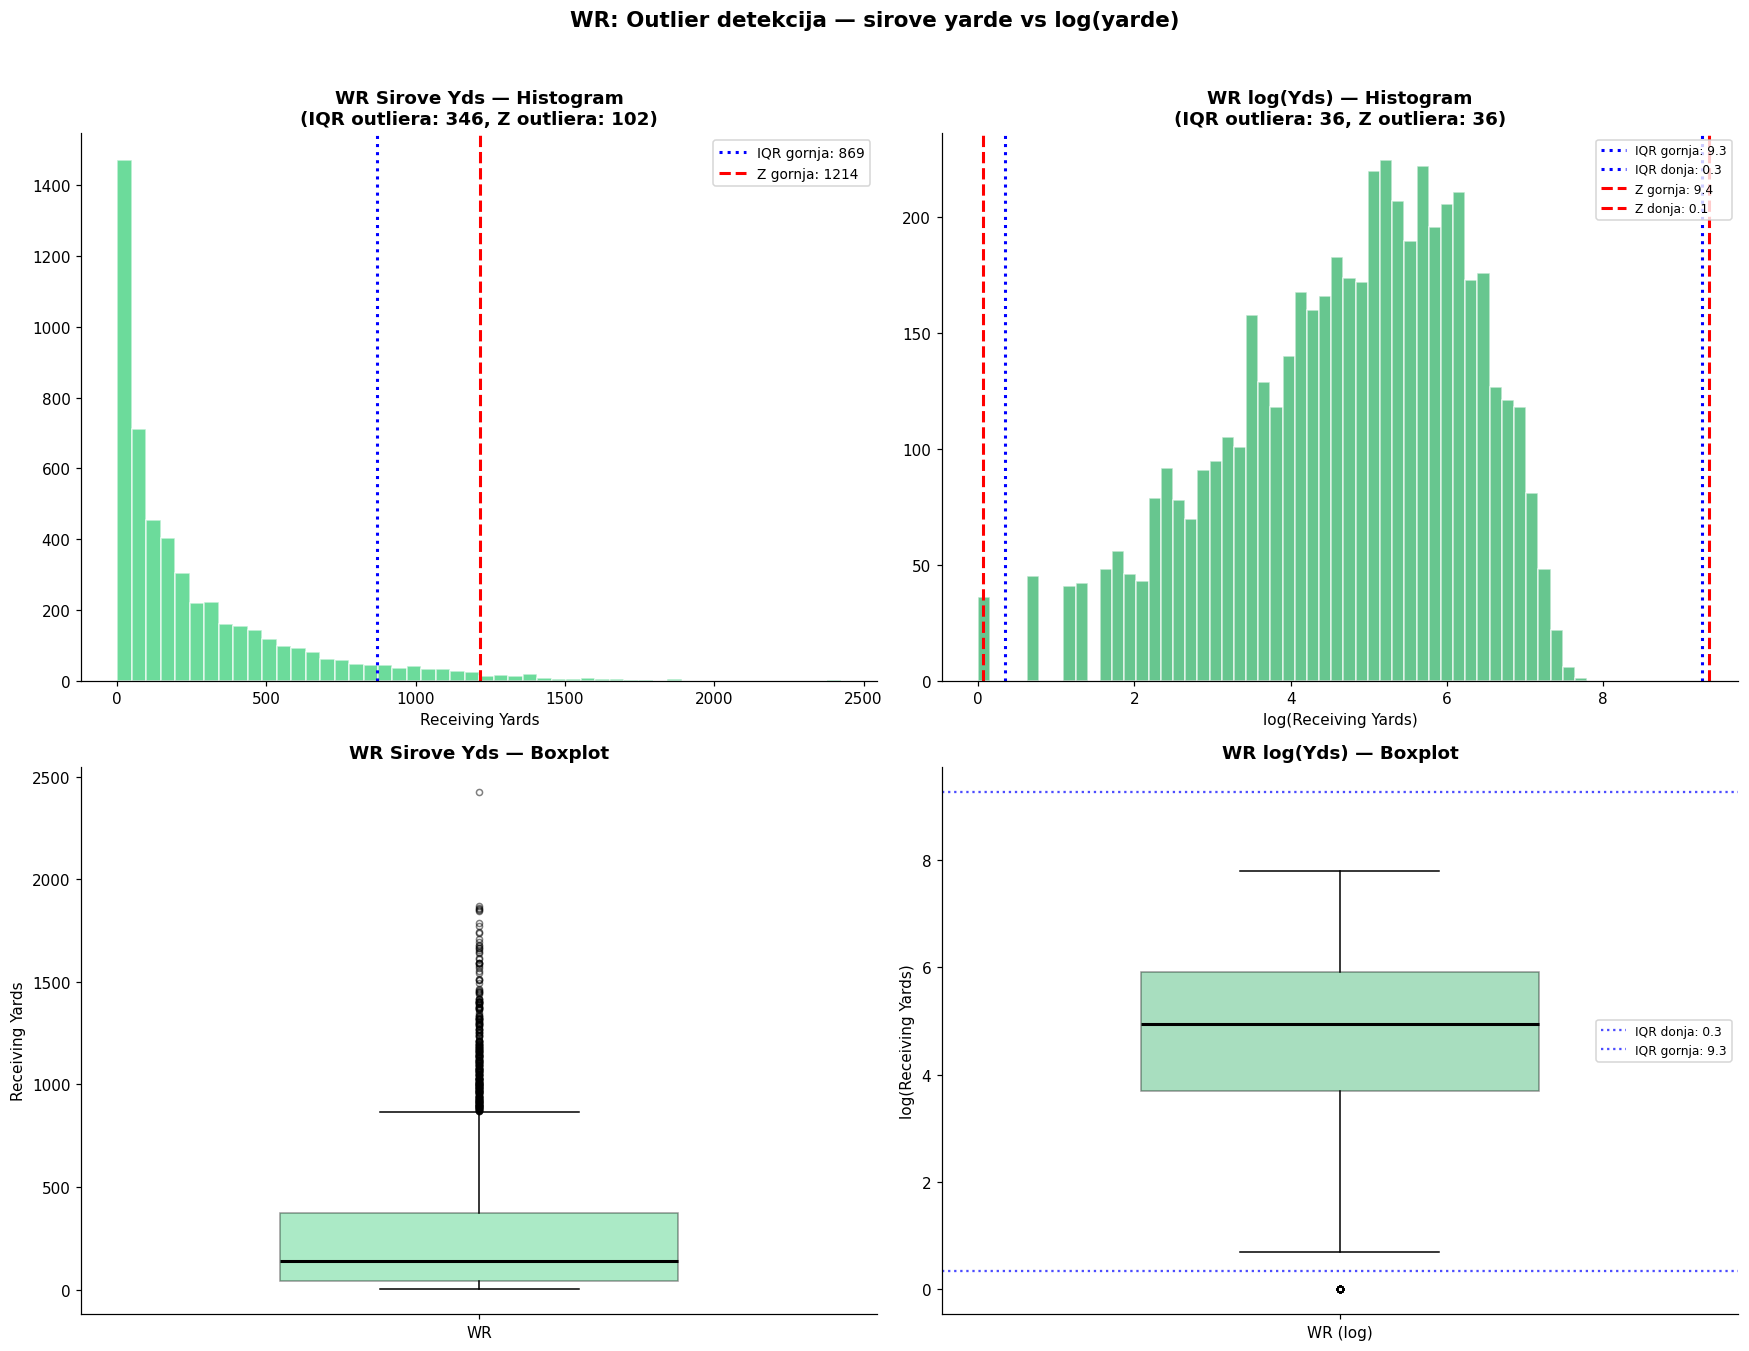

,Skala,N,Z outliera,IQR outliera,Z %,IQR %
0,Sirove Yds,5186,102,346,1.97,6.67
1,log(Yds),5186,36,36,0.69,0.69


In [18]:
# WR: Outlier detekcija na log(receiving_yards) vs sirove receiving_yards
wr_yds = wr_seasons['receiving_yards'].dropna()
wr_yds_positive = wr_yds[wr_yds > 0]
wr_log = np.log(wr_yds_positive)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ─── Sirove yarde ───
s_raw = wr_yds_positive
q1_r, q3_r = s_raw.quantile(0.25), s_raw.quantile(0.75)
iqr_r = q3_r - q1_r
lo_r, hi_r = q1_r - 1.5 * iqr_r, q3_r + 1.5 * iqr_r
z_raw = (s_raw - s_raw.mean()) / s_raw.std()

is_z_raw = z_raw.abs() > z_threshold
is_iqr_raw = (s_raw < lo_r) | (s_raw > hi_r)

axes[0, 0].hist(s_raw, bins=50, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[0, 0].axvline(hi_r, color='blue', linestyle=':', linewidth=2, label=f'IQR gornja: {hi_r:.0f}')
axes[0, 0].axvline(s_raw.mean() + z_threshold * s_raw.std(), color='red', linestyle='--', linewidth=2,
                    label=f'Z gornja: {s_raw.mean() + z_threshold * s_raw.std():.0f}')
axes[0, 0].set_title(f'WR Sirove Yds — Histogram\n(IQR outliera: {is_iqr_raw.sum()}, Z outliera: {is_z_raw.sum()})',
                      fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Receiving Yards')
axes[0, 0].legend(fontsize=9)

bp1 = axes[1, 0].boxplot(s_raw, vert=True, widths=0.5, patch_artist=True,
                          boxprops=dict(facecolor='#2ecc71', alpha=0.4),
                          medianprops=dict(color='black', linewidth=2),
                          flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[1, 0].set_title('WR Sirove Yds — Boxplot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Receiving Yards')
axes[1, 0].set_xticklabels(['WR'])

# ─── Log yarde ───
s_log = wr_log
q1_l, q3_l = s_log.quantile(0.25), s_log.quantile(0.75)
iqr_l = q3_l - q1_l
lo_l, hi_l = q1_l - 1.5 * iqr_l, q3_l + 1.5 * iqr_l
z_log = (s_log - s_log.mean()) / s_log.std()

is_z_log = z_log.abs() > z_threshold
is_iqr_log = (s_log < lo_l) | (s_log > hi_l)

axes[0, 1].hist(s_log, bins=50, color='#27ae60', alpha=0.7, edgecolor='white')
axes[0, 1].axvline(hi_l, color='blue', linestyle=':', linewidth=2, label=f'IQR gornja: {hi_l:.1f}')
axes[0, 1].axvline(lo_l, color='blue', linestyle=':', linewidth=2, label=f'IQR donja: {lo_l:.1f}')
axes[0, 1].axvline(s_log.mean() + z_threshold * s_log.std(), color='red', linestyle='--', linewidth=2,
                    label=f'Z gornja: {s_log.mean() + z_threshold * s_log.std():.1f}')
axes[0, 1].axvline(s_log.mean() - z_threshold * s_log.std(), color='red', linestyle='--', linewidth=2,
                    label=f'Z donja: {s_log.mean() - z_threshold * s_log.std():.1f}')
axes[0, 1].set_title(f'WR log(Yds) — Histogram\n(IQR outliera: {is_iqr_log.sum()}, Z outliera: {is_z_log.sum()})',
                      fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('log(Receiving Yards)')
axes[0, 1].legend(fontsize=8)

bp2 = axes[1, 1].boxplot(s_log, vert=True, widths=0.5, patch_artist=True,
                          boxprops=dict(facecolor='#27ae60', alpha=0.4),
                          medianprops=dict(color='black', linewidth=2),
                          flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[1, 1].axhline(lo_l, color='blue', linestyle=':', alpha=0.7, label=f'IQR donja: {lo_l:.1f}')
axes[1, 1].axhline(hi_l, color='blue', linestyle=':', alpha=0.7, label=f'IQR gornja: {hi_l:.1f}')
axes[1, 1].set_title('WR log(Yds) — Boxplot', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('log(Receiving Yards)')
axes[1, 1].set_xticklabels(['WR (log)'])
axes[1, 1].legend(fontsize=8)

fig.suptitle('WR: Outlier detekcija — sirove yarde vs log(yarde)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Uporedna tabela
compare_rows = [
    {"Skala": "Sirove Yds", "N": len(s_raw), "Z outliera": is_z_raw.sum(), "IQR outliera": is_iqr_raw.sum(),
     "Z %": round(is_z_raw.sum()/len(s_raw)*100, 2), "IQR %": round(is_iqr_raw.sum()/len(s_raw)*100, 2)},
    {"Skala": "log(Yds)", "N": len(s_log), "Z outliera": is_z_log.sum(), "IQR outliera": is_iqr_log.sum(),
     "Z %": round(is_z_log.sum()/len(s_log)*100, 2), "IQR %": round(is_iqr_log.sum()/len(s_log)*100, 2)},
]

display(pd.DataFrame(compare_rows))

---
## Ne-numeričke Kolone i Analiza Nagrada

Pregled ne-numeričkih (kategorijskih / string) kolona u svakom skupu podataka, te pie chart analiza koje se nagrade pojavljuju kod QB, RB i TE igrača.


In [19]:
for name, df in datasets.items():
    pos = name.split("(")[0].strip()
    cols = df.select_dtypes(exclude="number").columns.tolist()
    
    cols_str = ", ".join(cols) if cols else "Nema ne-numeričkih kolona"
    
    print(f"**{pos}** ({len(cols)} columns): {cols_str}")
    print("_" * 92) 

**QB** (9 columns): Player, PlayerID, Team, Pos, QBrec, Awards, snp_Def%, snp_Off%, snp_ST%
____________________________________________________________________________________________
**RB** (9 columns): Player, PlayerID, Team, Lg, Pos, awards, snp_Def%, snp_Off%, snp_ST%
____________________________________________________________________________________________
**TE** (8 columns): Player, PlayerID, Team, Pos, Awards, snp_Def%, snp_Off%, snp_ST%
____________________________________________________________________________________________
**WR** (4 columns): receiver_player_id, receiver_player_name, passer_player_id, player_team
____________________________________________________________________________________________


U narednim fazama pripreme podataka, planiramo da eliminišemo kolone koje predstavljaju isključivo metapodatke (poput ID brojeva i imena igrača) ili marginalne aspekte igre, kao što je procenat snepova u specijalnim timovima. Budući da specijalni timovi čine zanemarljiv udeo u igri nosilaca napada, njihovo uključivanje bi samo unelo nepotreban šum u model. Fokus će biti zadržan isključivo na varijablama koje direktno utiču na ofanzivnu produkciju i stabilnost podataka.

Ona koja je korisna su awards jer su nagrade ključan signal za buduće performanse - igrači koji su već dokazani kroz Pro Bowl, All-Pro ili MVP glasanja imaju tendenciju održavanja visokog nivoa igre.

### Analiza nagrada


In [20]:
from collections import Counter
from IPython.display import display, HTML
import re

# Mapa pozicija i njihovih awards kolona
award_map = {
    'QB': ('Awards', qb),
    'RB': ('awards', rb),
    'TE': ('Awards', te),
}

# Funkcija za parsiranje svih nagrada iz jednog stringa
def parse_awards(val):
    """Razdvaja awards string na pojedinacne nagrade."""
    if pd.isna(val) or str(val).strip() == '':
        return []
    # Awards su odvojene zarezima
    parts = [p.strip() for p in str(val).split(',')]
    return [p for p in parts if p]

# --- Prikupljanje svih nagrada po poziciji i ukupno ---
all_awards_total = Counter()
pos_awards = {}

for pos_name, (col_name, df) in award_map.items():
    counter = Counter()
    for val in df[col_name].dropna():
        awards = parse_awards(val)
        for a in awards:
            counter[a] += 1
            all_awards_total[a] += 1
    pos_awards[pos_name] = counter

# --- Prikaz rezultata ---
print("=" * 70)
print("PREGLED SVIH VRSTA NAGRADA U DATASETU (QB + RB + TE)")
print("=" * 70)

# Ukupno sve nagrade sortirane po broju pojavljivanja
print(f"\n{'Nagrada':<25} {'QB':>6} {'RB':>6} {'TE':>6} {'UKUPNO':>8}")
print("-" * 55)

all_award_names = sorted(all_awards_total.keys(), key=lambda x: all_awards_total[x], reverse=True)

for award in all_award_names:
    qb_cnt = pos_awards['QB'].get(award, 0)
    rb_cnt = pos_awards['RB'].get(award, 0)
    te_cnt = pos_awards['TE'].get(award, 0)
    total = all_awards_total[award]
    print(f"{award:<25} {qb_cnt:>6} {rb_cnt:>6} {te_cnt:>6} {total:>8}")

print("-" * 55)
print(f"{'UKUPNO NAGRADA':<25} {sum(pos_awards['QB'].values()):>6} {sum(pos_awards['RB'].values()):>6} {sum(pos_awards['TE'].values()):>6} {sum(all_awards_total.values()):>8}")
print(f"\nBroj razlicitih vrsta nagrada: {len(all_awards_total)}")



PREGLED SVIH VRSTA NAGRADA U DATASETU (QB + RB + TE)

Nagrada                       QB     RB     TE   UKUPNO
-------------------------------------------------------
PB                           262    152     92      506
AP-1                          40     52     27      119
AP-2                          37     39     20       96
AP MVP-1                      32      8      0       40
AP OPoY-2                     24      7      0       31
AP MVP-2                      26      5      0       31
AP OPoY-3                     20      9      0       29
AP OPoY-1                     14     15      0       29
AP OPoY-4                     20      7      1       28
AP MVP-3                      14      7      0       21
AP OPoY-5                      9      6      2       17
AP ORoY-1                      8      7      0       15
AP CPoY-3                      8      4      2       14
AP MVP-4                       8      6      0       14
AP MVP-5                      11      2      0    

Vidimo da ima dosta zapisa u koloni za nagrade, ali nisu svi ti zapisi dodeljene nagrade, nego se beleži ranking u glasanju za odredjenu nagradu, tako da ako je neko bio npr. bio 11. u glasanju za Offensive player of the Year to nama nije znacajno. 

Takodje ima nagrada poput Comeback Player of the yaer koja nam isto nije znacajna ona je subjektivna i ne odražava nužno čistu veštinu. Ona nagrađuje napredak u odnosu na lošu prethodnu sezonu ili povredu, što diskriminiše konstantno elitne igrače koji nemaju od čega da se "vraćaju"

### Odabir nagrada
Koristićemo 5 posebnih metrika za nagrade koji su prikazani ispod:

In [21]:
import pandas as pd
import numpy as np

# Mapa pozicija -> (kolona nagrada, dataframe)
award_map = {
    'QB': ('Awards', qb),
    'RB': ('awards', rb),
    'TE': ('Awards', te),
}

def has_any_of(val, keywords):
    """Provjeri da li awards string sadrzi bilo koji od keywordova."""
    if pd.isna(val) or str(val).strip() == '':
        return False
    s = str(val)
    return any(kw in s for kw in keywords)

# 5 kategorija nagrada
award_categories = {
    'Pro Bowl (PB)':       ['PB'],
    'All-Pro 1st Team':    ['AP-1'],
    'All-Pro 2nd Team':    ['AP-2'],
    'TOP 5 MVP':           ['MVP-1', 'MVP-2', 'MVP-3', 'MVP-4', 'MVP-5'],
    'TOP 5 OPoY':          ['OPoY-1', 'OPoY-2', 'OPoY-3', 'OPoY-4', 'OPoY-5'],
}

# Prikupljanje podataka
rows = []
for cat_name, keywords in award_categories.items():
    row = {'Nagrada': cat_name}
    for pos_name, (col_name, df) in award_map.items():
        total = len(df)
        count = df[col_name].apply(lambda v: has_any_of(v, keywords)).sum()
        pct = count / total * 100
        row[f'{pos_name} (broj)'] = int(count)
        row[f'{pos_name} (%)'] = round(pct, 1)
    rows.append(row)

result_df = pd.DataFrame(rows)

# Prikazivanje tabele
print("_" * 80)
print("BROJ SEZONA SA NAGRADOM PO POZICIJI (od ukupno QB={}, RB={}, TE={})".format(len(qb), len(rb), len(te)))
print()

# Formatiran ispis
header = f"{'Kategorija':<22} | {'QB':>10} | {'RB':>10} | {'TE':>10}"
print(header)
print("-" * len(header))

for _, r in result_df.iterrows():
    qb_str = f"{r['QB (broj)']:>4} ({r['QB (%)']:>5.1f}%)"
    rb_str = f"{r['RB (broj)']:>4} ({r['RB (%)']:>5.1f}%)"
    te_str = f"{r['TE (broj)']:>4} ({r['TE (%)']:>5.1f}%)"
    print(f"{r['Nagrada']:<22} | {qb_str:>10} | {rb_str:>10} | {te_str:>10}")

print("-" * len(header))


________________________________________________________________________________
BROJ SEZONA SA NAGRADOM PO POZICIJI (od ukupno QB=845, RB=622, TE=351)

Kategorija             |         QB |         RB |         TE
-------------------------------------------------------------
Pro Bowl (PB)          |  262 ( 31.0%) |  152 ( 24.4%) |   93 ( 26.5%)
All-Pro 1st Team       |   40 (  4.7%) |   52 (  8.4%) |   28 (  8.0%)
All-Pro 2nd Team       |   37 (  4.4%) |   39 (  6.3%) |   20 (  5.7%)
TOP 5 MVP              |   92 ( 10.9%) |   28 (  4.5%) |    0 (  0.0%)
TOP 5 OPoY             |   89 ( 10.5%) |   46 (  7.4%) |    4 (  1.1%)
-------------------------------------------------------------


### Pie chart analiza nagrada

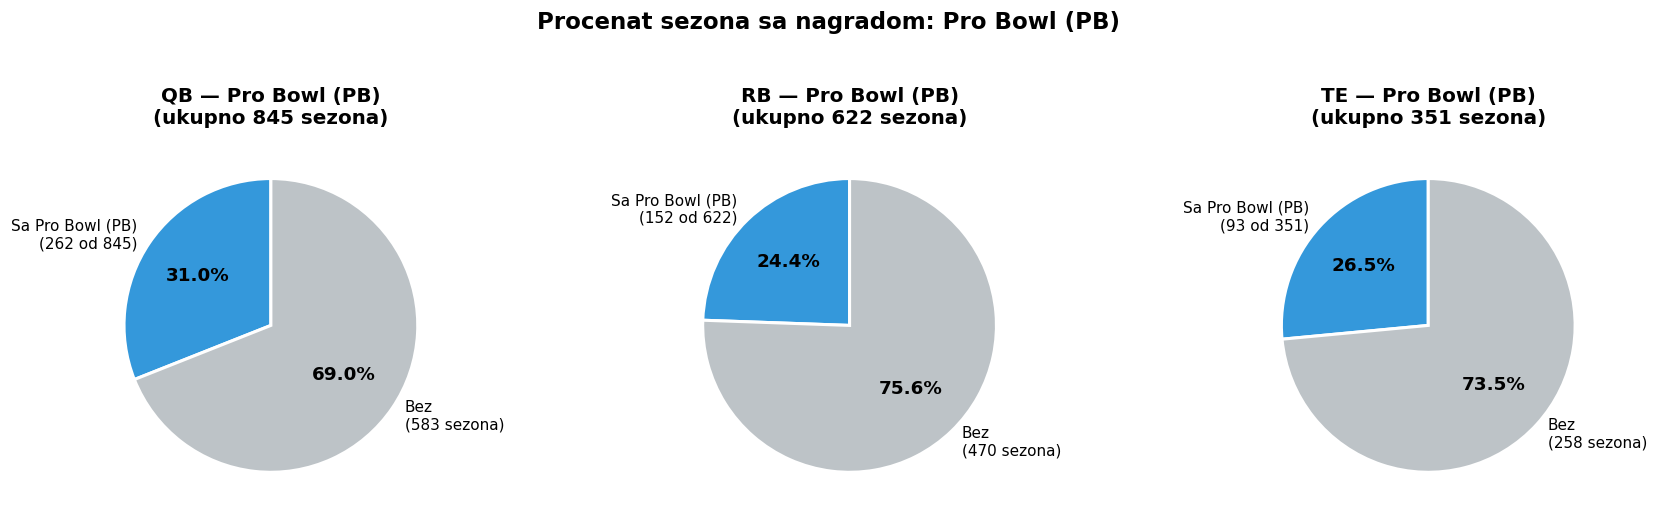

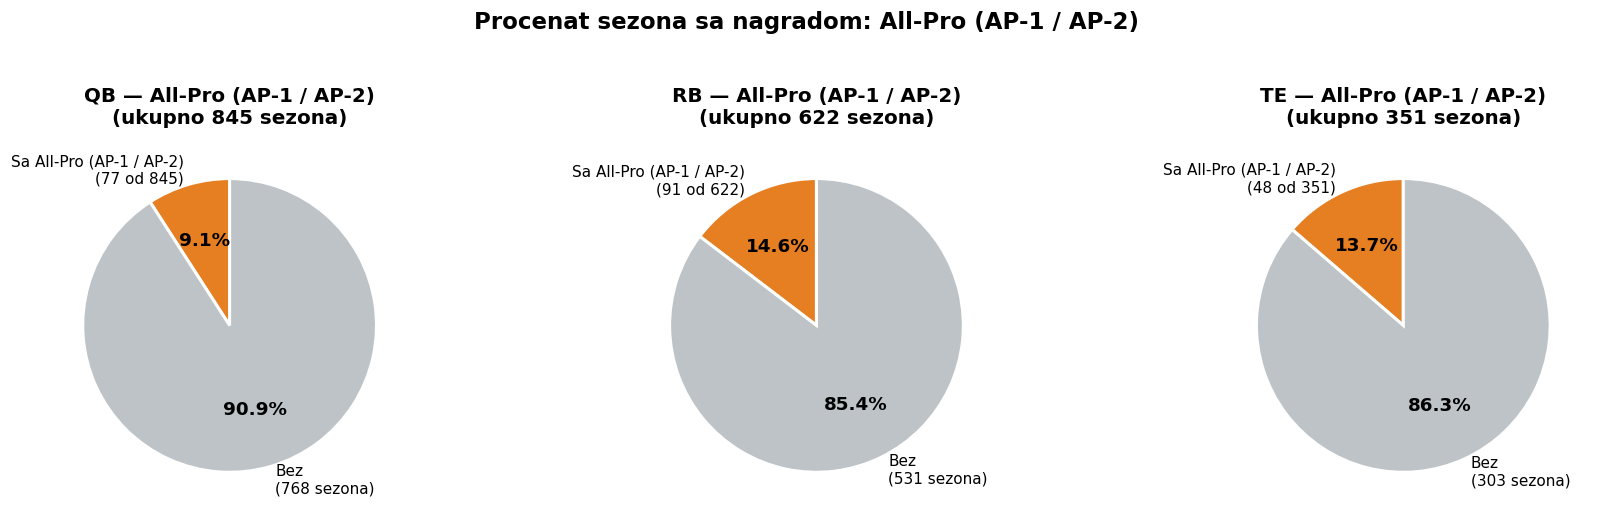

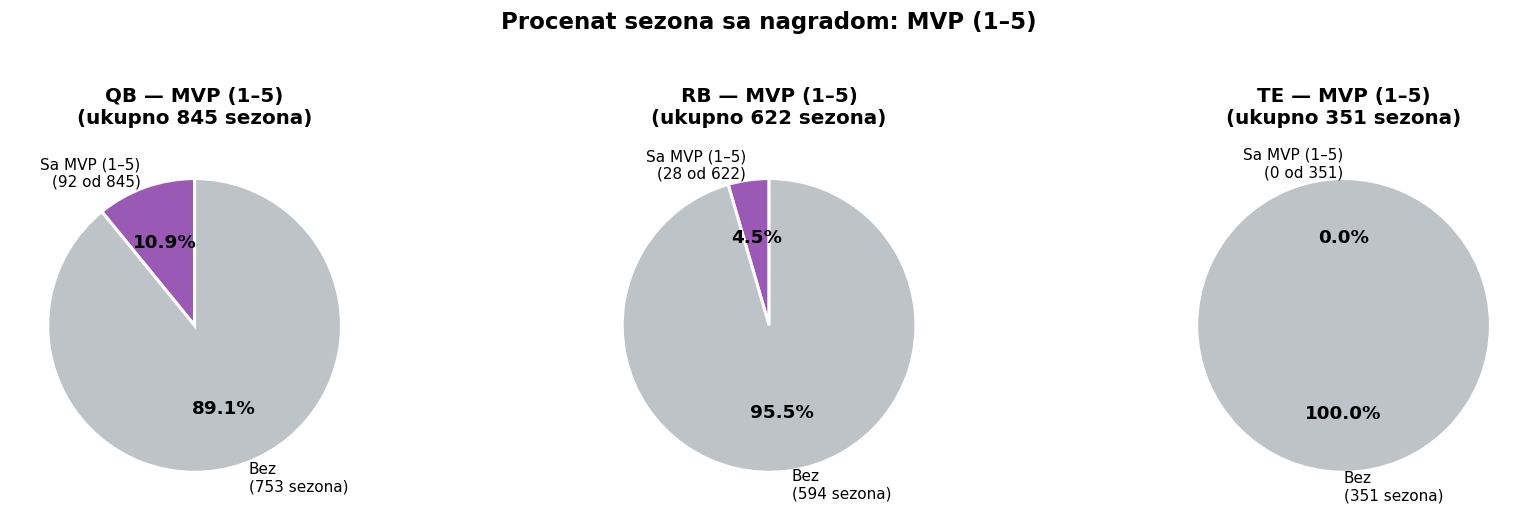

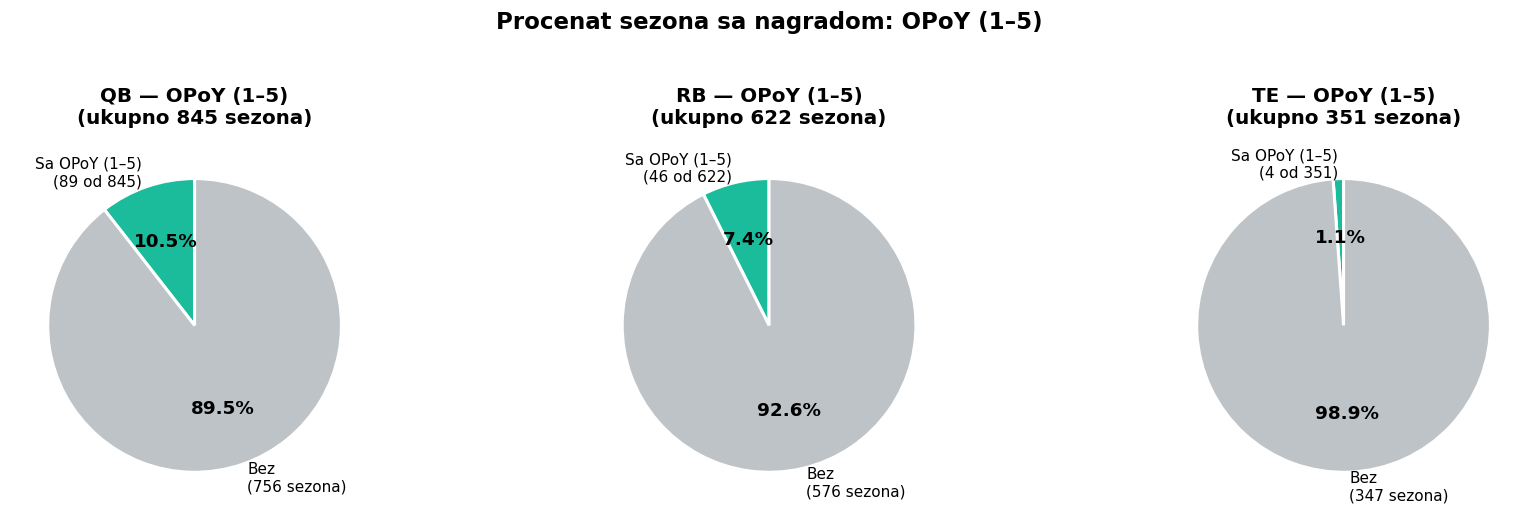

In [22]:
# ── Pie Chart: Procenat SEZONA sa nagradama kod QB, RB i TE ──

import matplotlib.pyplot as plt
import numpy as np

# Mapiranje Awards kolone za svaku poziciju
award_map = {
    "QB": ("Awards", qb),
    "RB": ("awards", rb),
    "TE": ("Awards", te),
}

# Helper: provera nagrada u stringu
def has_any_of(val, keywords):
    """Da li string sadrži bilo koji od navedenih ključeva."""
    if pd.isna(val) or str(val).strip() == "":
        return False
    s = str(val)
    return any(kw in s for kw in keywords)

# ── Grupisane nagrade (svaka grupa = 1 set pie chartova) ──
award_checks = {
    "Pro Bowl (PB)":     ["PB"],
    "All-Pro (AP-1 / AP-2)": ["AP-1", "AP-2"],
    "MVP (1–5)":         ["MVP-1", "MVP-2", "MVP-3", "MVP-4", "MVP-5"],
    "OPoY (1–5)":        ["OPoY-1", "OPoY-2", "OPoY-3", "OPoY-4", "OPoY-5"],
}

award_colors = {
    "Pro Bowl (PB)":           ["#3498db", "#bdc3c7"],
    "All-Pro (AP-1 / AP-2)":   ["#e67e22", "#bdc3c7"],
    "MVP (1–5)":               ["#9b59b6", "#bdc3c7"],
    "OPoY (1–5)":              ["#1abc9c", "#bdc3c7"],
}

# ── Generisanje pie chartova: 1 red po grupi nagrada × 3 kolone (QB, RB, TE) ──
for award_name, keywords in award_checks.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    colors = award_colors[award_name]
    
    for idx, (pos, (col, df)) in enumerate(award_map.items()):
        total_seasons = len(df)
        seasons_with = int(df[col].apply(lambda v: has_any_of(v, keywords)).sum())
        seasons_without = total_seasons - seasons_with
        
        sizes = [seasons_with, seasons_without]
        labels = [
            f"Sa {award_name}\n({seasons_with} od {total_seasons})",
            f"Bez\n({seasons_without} sezona)"
        ]
        
        wedges, texts, autotexts = axes[idx].pie(
            sizes, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 10},
            wedgeprops={"edgecolor": "white", "linewidth": 2}
        )
        for at in autotexts:
            at.set_fontweight("bold")
            at.set_fontsize(12)
        axes[idx].set_title(
            f"{pos} — {award_name}\n(ukupno {total_seasons} sezona)",
            fontsize=13, fontweight="bold", pad=12
        )
    
    fig.suptitle(
        f"Procenat sezona sa nagradom: {award_name}",
        fontsize=15, fontweight="bold", y=1.04
    )
    plt.tight_layout()
    plt.show()

### Zaključak — Nagrade kao Feature za Predikciju

Pie chartovi prikazuju procenat sezona (redova) u kojima se pojavljuje svaka nagrada od ukupnog broja sezona za datu poziciju:

- Pro Bowl (PB) je najčešća nagrada — pojavljuje se u značajnom procentu sezona, posebno kod QB-ova.
- All-Pro (AP-1, AP-2) je znatno ređa — vrlo mali procenat sezona nosi ovu oznaku, što je čini ekskluzivnijim signalom kvaliteta.
- MVP i OPoY nagrade su ekstremno retke na nivou sezona, ali su izuzetno jak indikator vrhunske igre.

Ove nagrade se koriste kao feature u modelovanju jer sezona sa nagradom signalizira vrhunsku igru i pomaže modelu da prepozna obrasce koji vode ka budućim performansama.

Nakon smanjivanja broja razlićitih klasa unutar award kolone, zbog malog broja različitih kolona smo se odlčili za one hot encoding.

## Korelacije


### QB — Korelaciona Matrica

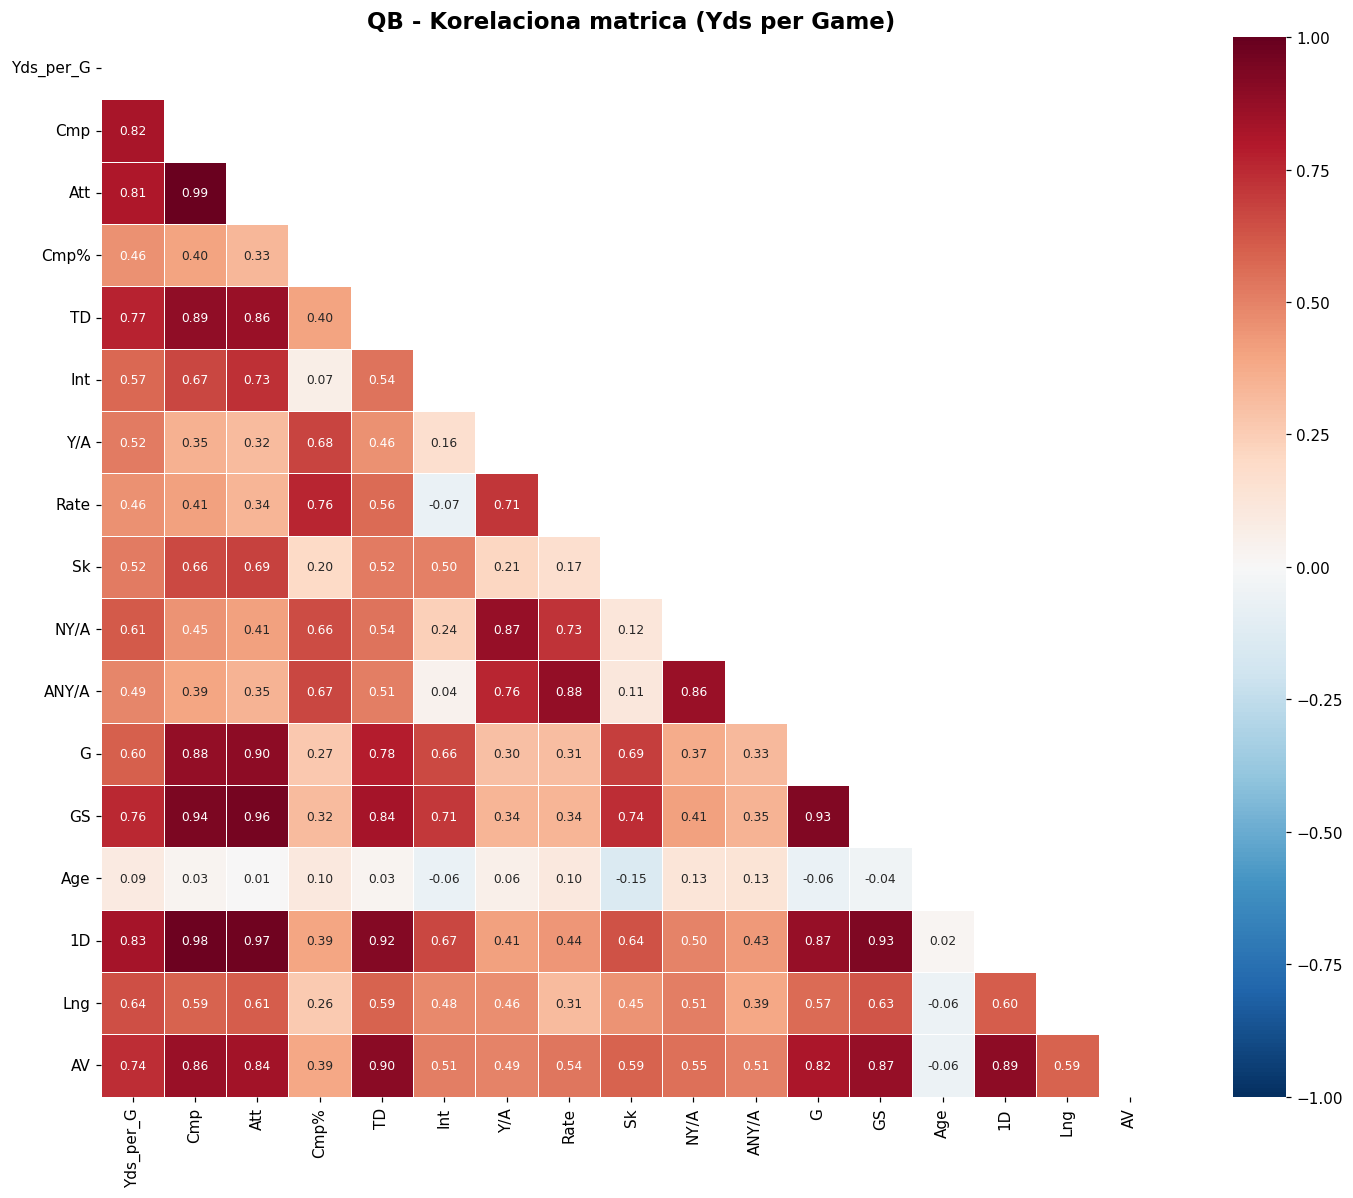

In [23]:
import seaborn as sns
import numpy as np

# Kreiranje per-game metrika ako ne postoje (safety check)
if 'Yds_per_G' not in qb.columns:
    qb['Yds_per_G'] = qb['Yds'] / qb['G']
    qb['TD_per_G'] = qb['TD'] / qb['G']

# QB - Heatmap korelacione matrice
fig, ax = plt.subplots(figsize=(14, 11))
qb_heatmap_cols = ['Yds_per_G', 'Cmp', 'Att', 'Cmp%', 'TD', 'Int', 'Y/A', 'Rate', 
                   'Sk', 'NY/A', 'ANY/A', 'G', 'GS', 'Age', '1D', 'Lng', 'AV']

# Filtriramo samo postojeće kolone
qb_heatmap_cols = [c for c in qb_heatmap_cols if c in qb.columns]

# Računanje korelacione matrice
corr_matrix = qb[qb_heatmap_cols].corr()

# Kreiranje mask-a za gornji trougao
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('QB - Korelaciona matrica (Yds per Game)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



**Zaključak:**
- Najjače korelacije: `Att` (pokušaji), `Cmp` (kompletirana dodavanja), `GS` (games started), `1D` (prvi downi). Ovo je logično – više pokušaja = više yardi.
- Passer Rating (`Rate`) ima umeren pozitivan odnos, što znači da efikasnost sama po sebi ne garantuje visoke yarde – volumen je ključan.
- Interceptions (`Int`) nema veliku korelaciju sa drugim statistikama, čak i sa statistikama efikasnosti, poput passer rating-a, što je možda neočekivano.
- `Age` pokazuje minimalnu korelaciju sa performansama, što ukazuje da starost nema toliki uticaj na QB produktivnost kao kod ostalih pozicija.

### RB — Korelaciona Matrica

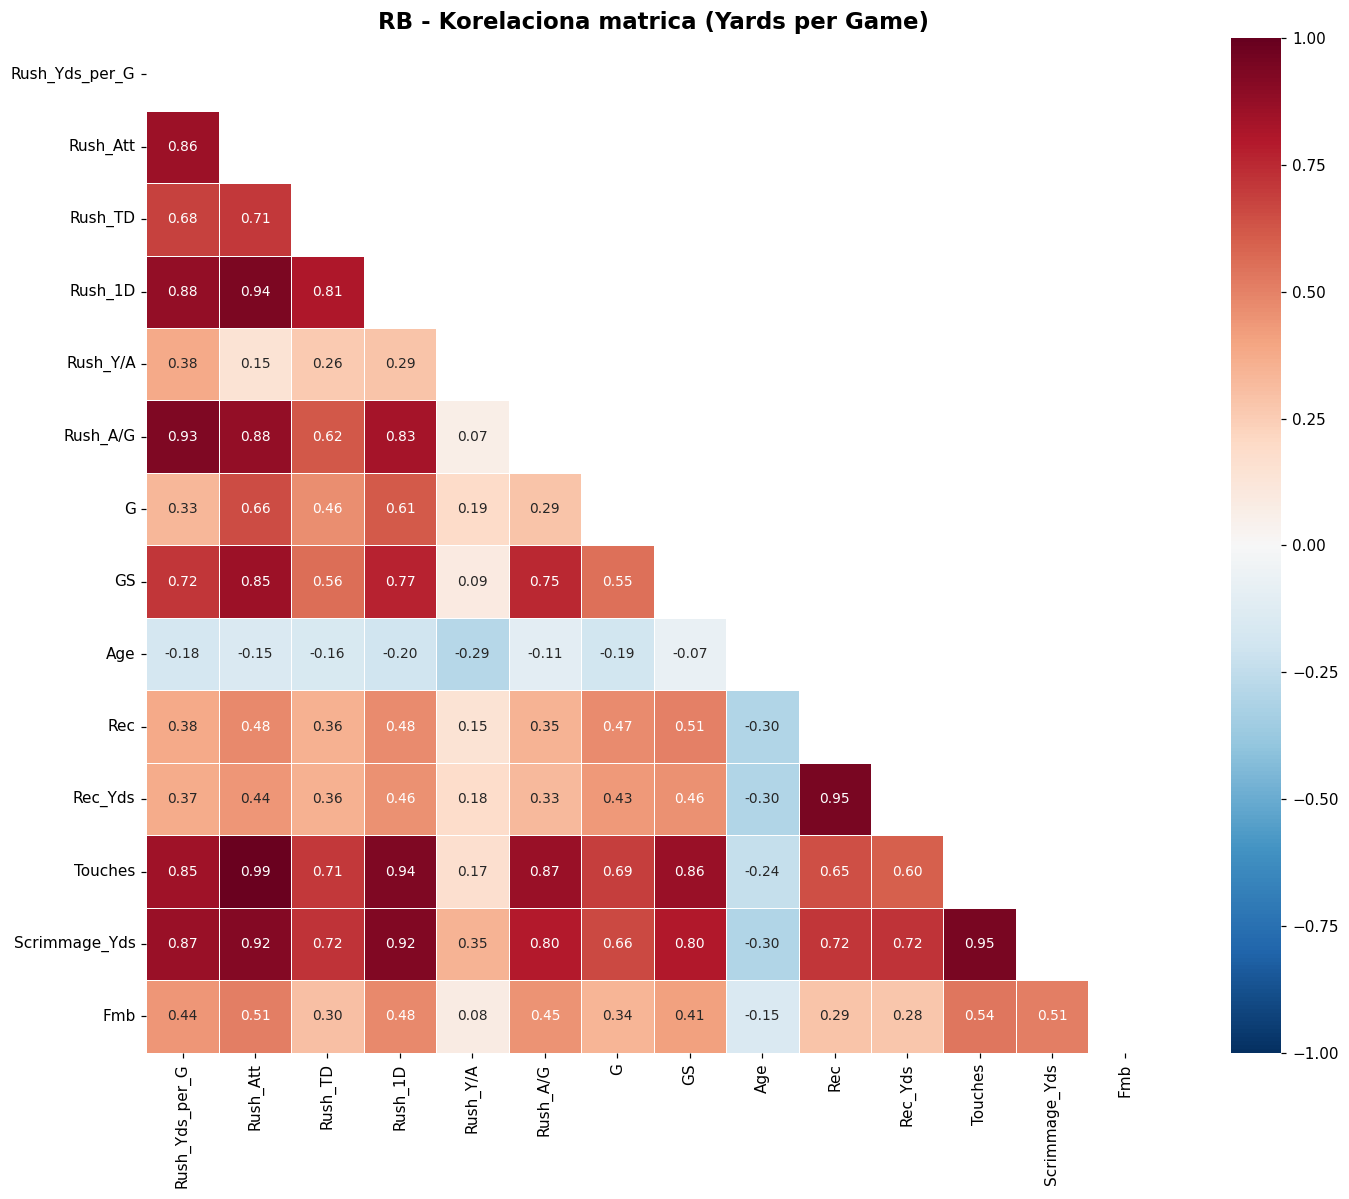

In [24]:
# Kreiranje per-game metrika ako ne postoje (safety check)
if 'Rush_Yds_per_G' not in rb.columns:
    rb['Rush_Yds_per_G'] = rb['Rush_Yds'] / rb['G']
    rb['Rush_TD_per_G'] = rb['Rush_TD'] / rb['G']

# RB - Heatmap korelacione matrice
fig, ax = plt.subplots(figsize=(14, 11))
rb_heatmap_cols = ['Rush_Yds_per_G', 'Rush_Att', 'Rush_TD', 'Rush_1D', 'Rush_Y/A',
                   'Rush_A/G', 'G', 'GS', 'Age', 'Rec', 'Rec_Yds', 'Touches', 'Scrimmage_Yds', 'Fmb']

# Filtriramo samo postojeće kolone
rb_heatmap_cols = [c for c in rb_heatmap_cols if c in rb.columns]

# Računanje korelacione matrice
corr_matrix_rb = rb[rb_heatmap_cols].corr()

# Kreiranje mask-a za gornji trougao
mask = np.triu(np.ones_like(corr_matrix_rb, dtype=bool))

sns.heatmap(corr_matrix_rb, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('RB - Korelaciona matrica (Yards per Game)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



**Zaključak:**
- Rush yards po utakmici (`Rush_Yds_per_G`) direktno korelira sa volume metrikama (`Rush_Att`, `Touches`) i ukupnom produktivnošću (`Scrimmage_Yds`).
- `Rush_Y/A` (yards per attempt) ne znači puno za yards po utakmici jer volumen igra dominantniju ulogu - prosek ostaje stabilan, ali ga je teško održati na velikoj zapremini pokušaja.
- Receiving metrike (`Rec`, `Rec_Yds`) ne pokazuju značajnu korelaciju sa rushing performansama, što potvrđuje da su ove dve dimenzije igre međusobno nezavisne.
- `Age` ima obrnuto proporcionalan uticaj na yarde, i to je posebno izrazito kod RB pozicije - za razliku od QB-a, gdje starost ima minimalan efekat, RB igrači vidno gube produktivnost sa godinama.

### WR — Korelaciona Matrica

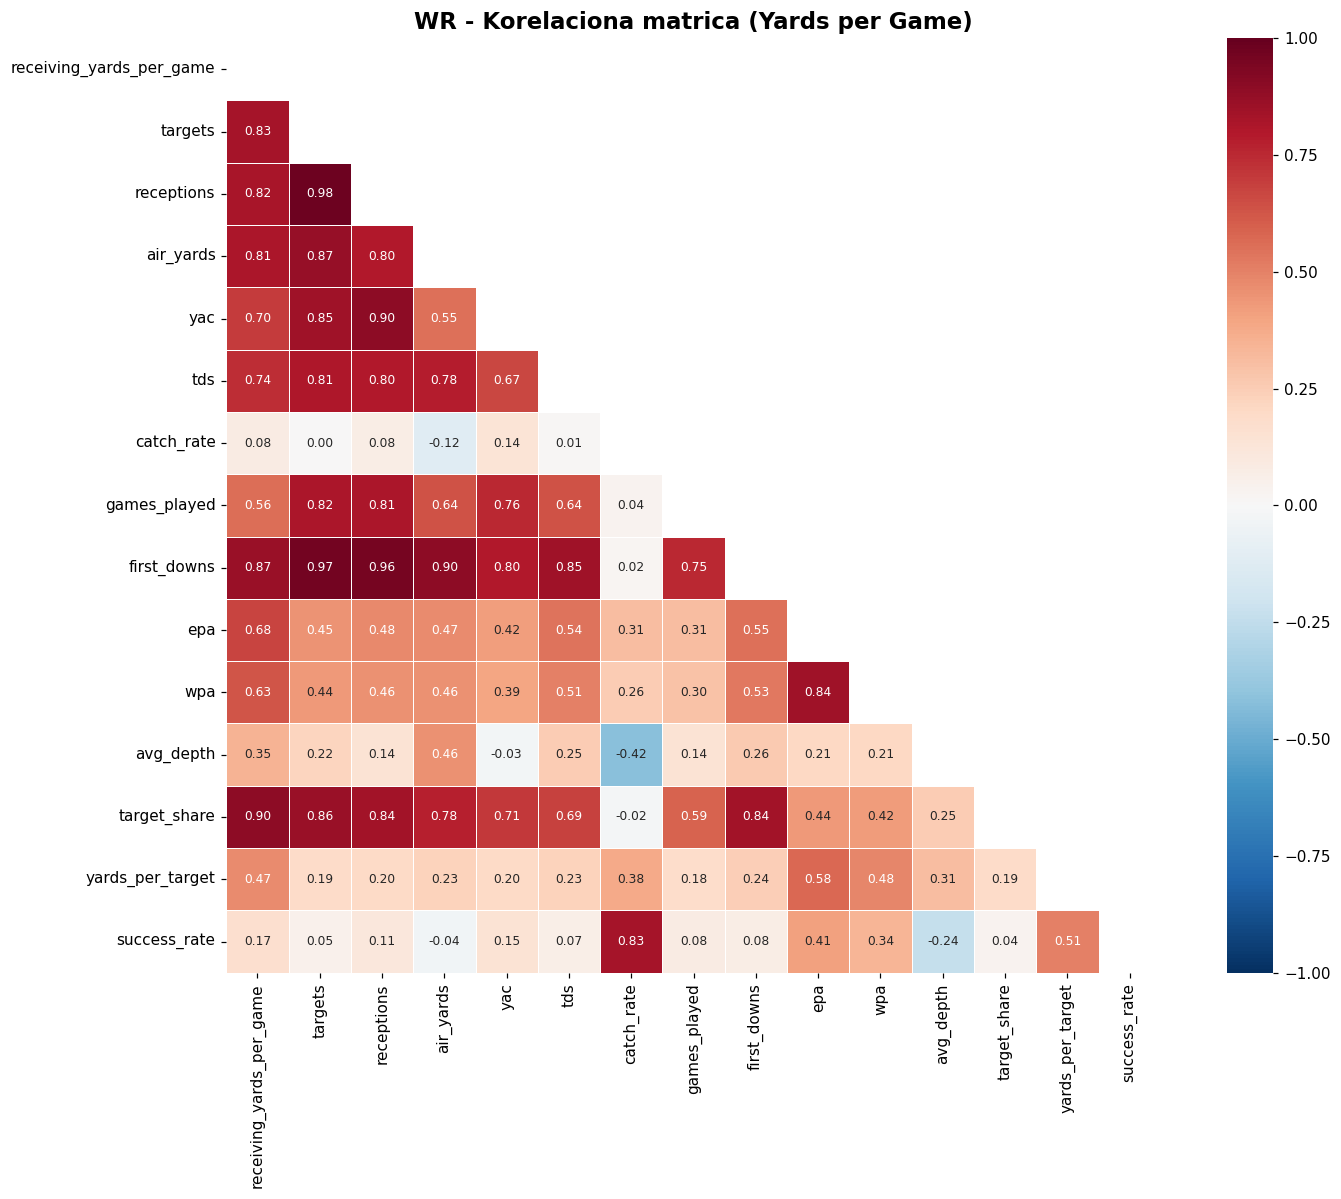

In [25]:
# Kreiranje per-game metrike za WR ako ne postoji
if 'receiving_yards_per_game' not in wr_seasons.columns:
    wr_seasons['receiving_yards_per_game'] = wr_seasons['receiving_yards'] / wr_seasons['games_played']

# WR - Heatmap korelacione matrice
fig, ax = plt.subplots(figsize=(14, 11))
wr_heatmap_cols = ['receiving_yards_per_game', 'targets', 'receptions', 'air_yards', 'yac', 'tds',
                   'catch_rate', 'games_played', 'first_downs', 'epa', 'wpa',
                   'avg_depth', 'target_share', 'yards_per_target', 'success_rate']

# Filtriramo samo postojeće kolone
wr_heatmap_cols = [c for c in wr_heatmap_cols if c in wr_seasons.columns]

# Računanje korelacione matrice
corr_matrix_wr = wr_seasons[wr_heatmap_cols].corr()

# Kreiranje mask-a za gornji trougao
mask = np.triu(np.ones_like(corr_matrix_wr, dtype=bool))

sns.heatmap(corr_matrix_wr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('WR - Korelaciona matrica (Yards per Game)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



**Zaključak:**
- Receiving yards po utakmici (`receiving_yards_per_game`) ima najjaču korelaciju sa `targets` i `receptions`, što potvrđuje važnost volume-based upotrebe.
- Postoji i jaka korelacija između `receiving_yards_per_game` i `first_downs` te `target_share` - receiver koji pomera lance i osvaja nove prve downove dobija veći udeo u timskim targetima, što direktno rezultira većom jardažom.
- Neke kvalitativne metrike imaju značajan uticaj na yarde - `air_yards` pokazuje snažnu korelaciju, dok druge kao što je `catch_rate` praktično nema korelaciju sa yards/game, što ukazuje da sam procenat hvatanja ne određuje jardažu.
- Postoji jasna i očigledna obrnuta korelacija između `catch_rate` i `avg_depth` (dublje rute = manji procenat hvatanja), kao i između `avg_depth` i `success_rate` (veća dubina targeta smanjuje stopu uspešnih play-va).


### TE — Korelaciona Matrica

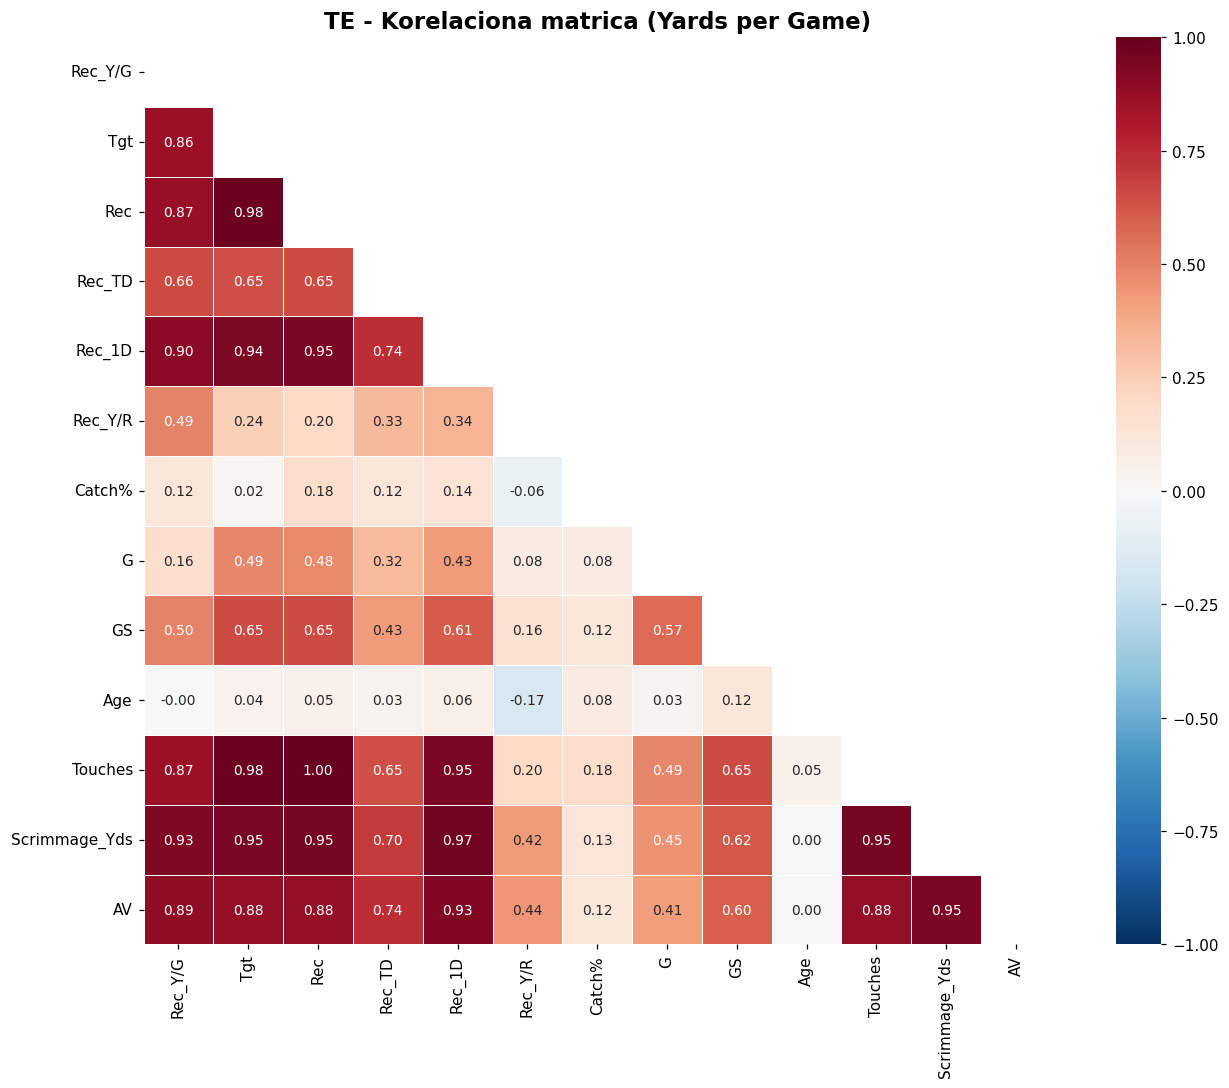

In [26]:
# TE - Heatmap korelacione matrice
fig, ax = plt.subplots(figsize=(13, 10))
te_heatmap_cols = ['Rec_Y/G', 'Tgt', 'Rec', 'Rec_TD', 'Rec_1D', 'Rec_Y/R',
                   'Catch%', 'G', 'GS', 'Age', 'Touches', 'Scrimmage_Yds', 'AV']

# Filtriramo samo postojeće kolone
te_heatmap_cols = [c for c in te_heatmap_cols if c in te.columns]

# Računanje korelacione matrice
corr_matrix_te = te[te_heatmap_cols].corr()

# Kreiranje mask-a za gornji trougao
mask = np.triu(np.ones_like(corr_matrix_te, dtype=bool))

sns.heatmap(corr_matrix_te, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('TE - Korelaciona matrica (Yards per Game)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Zaključak:**
- Receiving yards po utakmici (`Rec_Yds_per_G`) kod TE pozicije direktno korelira sa `Tgt` (targets) i `Rec` (receptions), sličnom mehanikom kao kod WR.
- `Rec_Y/R` (yards per reception) pokazuje umerenu korelaciju, što ukazuje da su eksplozivniji TE igrači efikasniji u generisanju yardi.
- `Age` kod TE pozicije ne pokazuje korelaciju za razliku od RB pozicije, mada vidi se smanenje eksplozivnosti jer opada Y/R, ali zato TE pozicija je takva da ih bolje blokiranje drži na terenu duže u karijeri i iskustvo pomaze da ostale statistike ne opadaju sa godinama.

**Ključni uvid za modeliranje:**
- Kod svih četiri skupa podataka primjećuje se visoka međusobna korelacija između feature kolona (multikolinearnost) — volume metrike  međusobno su snažno korelisane. Ovo direktno utiče na stabilnost linearnih modela jer koeficijenti postaju nestabilni i teški za interpretaciju. Zbog toga će regularizacioni modeli (Lasso, Ridge, ElasticNet) biti posebno važni.

## Pair Plot - Vizuelna dopuna matrice korelacije

Pair plot prikazuje sve parove scatter plotova za odabrane numeričke varijable, sa distribucijama na dijagonali. Ovo omogućava brzu identifikaciju i vizuelnu dopunu matrice korelacije


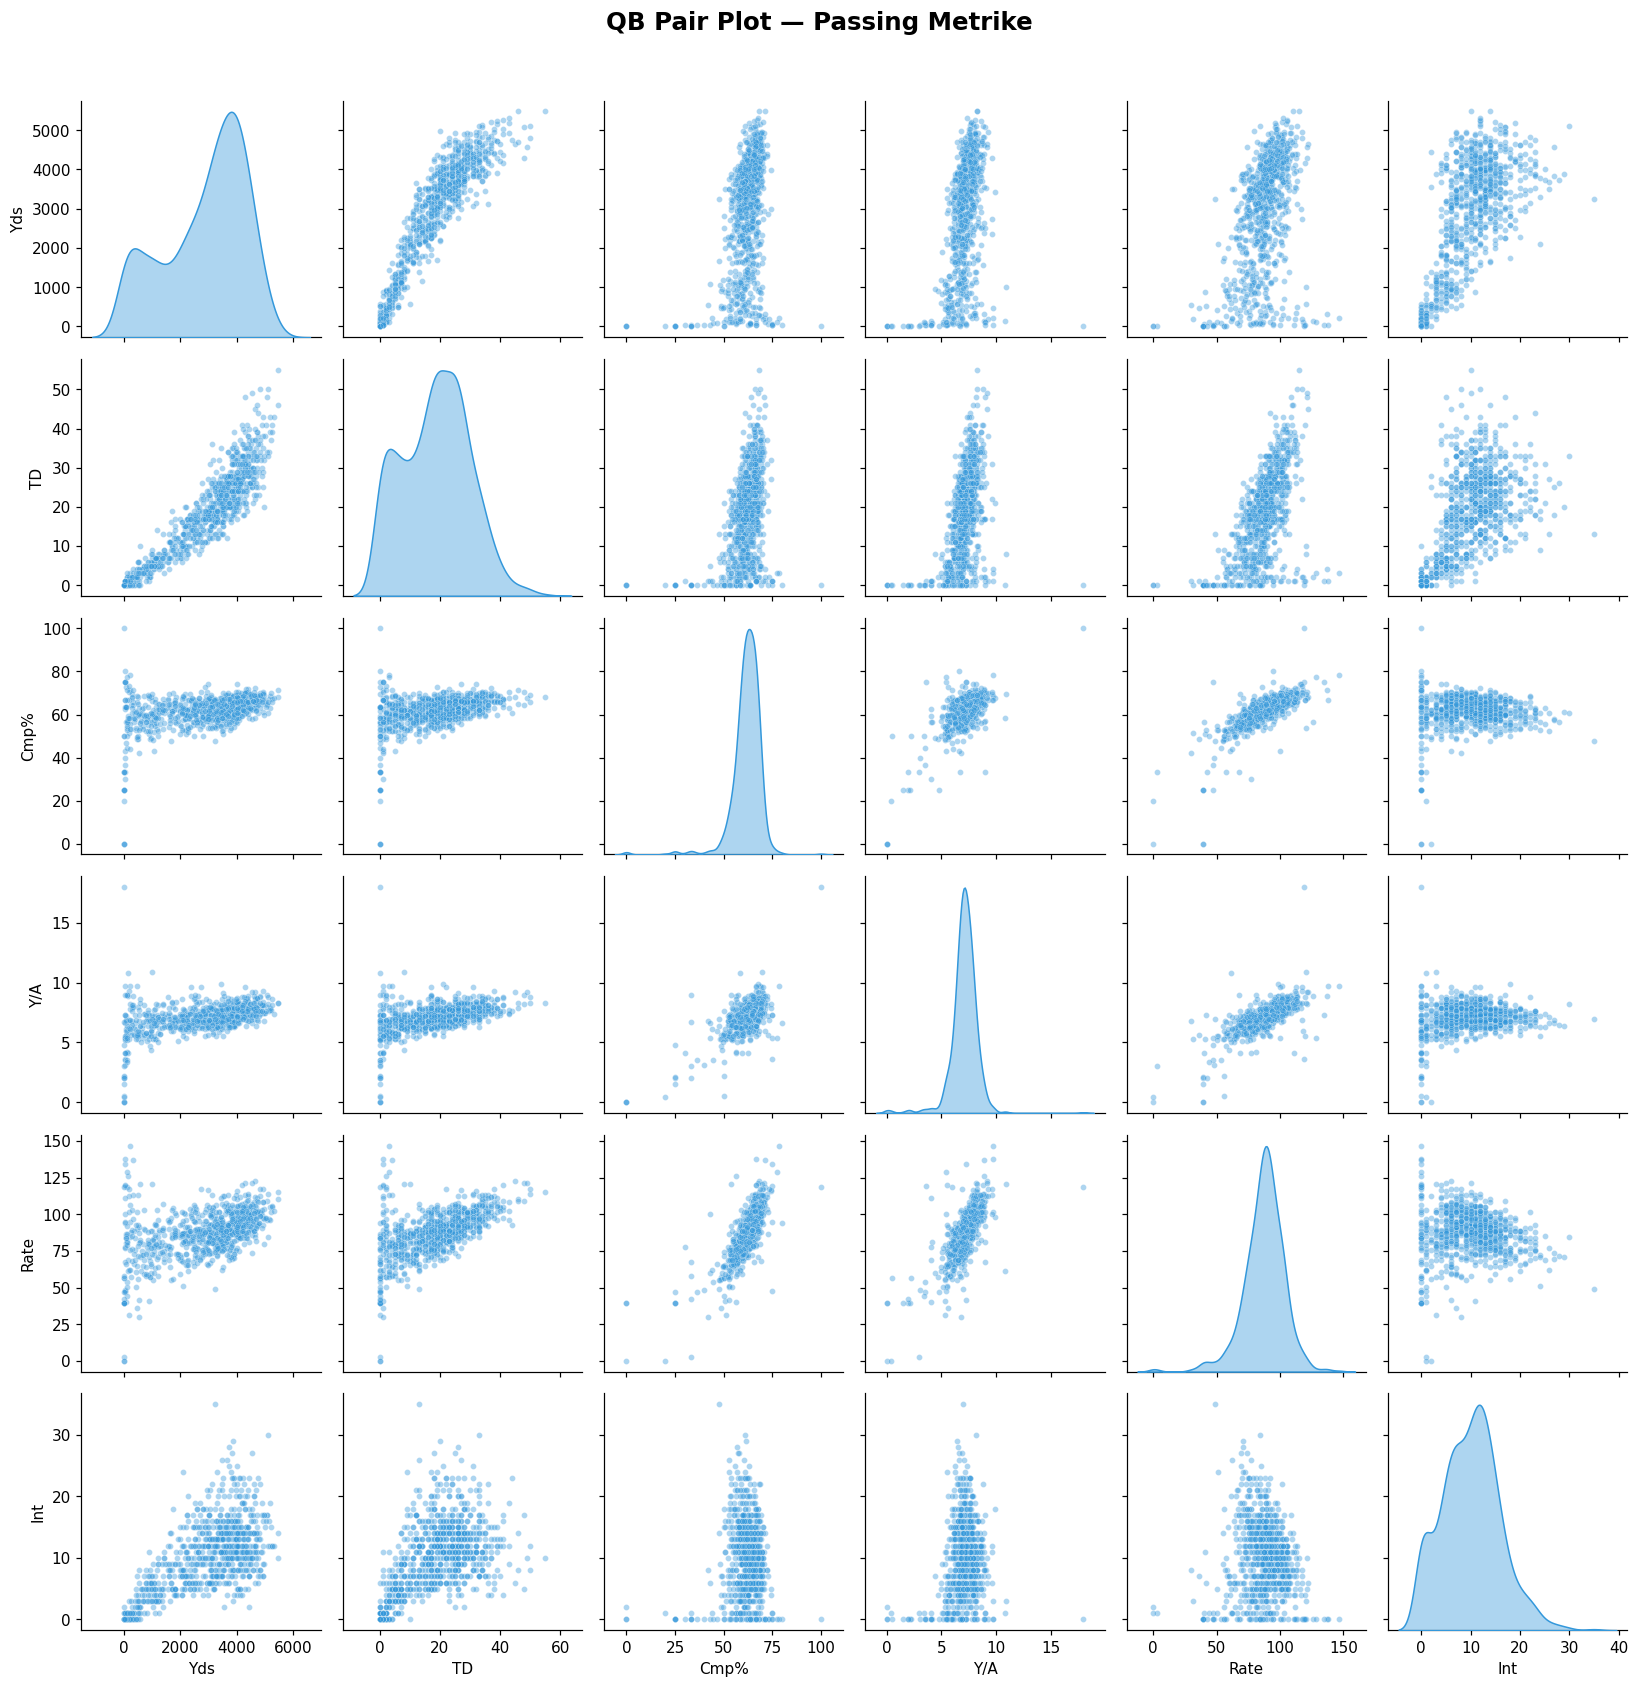

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ──────────────────────────────────────────────
# QB Pair Plot — ključne passing metrike
# ──────────────────────────────────────────────
qb_pair_cols = ['Yds', 'TD', 'Cmp%', 'Y/A', 'Rate', 'Int']
qb_pair_cols = [c for c in qb_pair_cols if c in qb.columns]

qb_pair_df = qb[qb_pair_cols].dropna()

g = sns.pairplot(qb_pair_df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15, 'color': '#3498db'},
                 diag_kws={'color': '#3498db', 'fill': True, 'alpha': 0.4})
g.figure.suptitle('QB Pair Plot — Passing Metrike', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

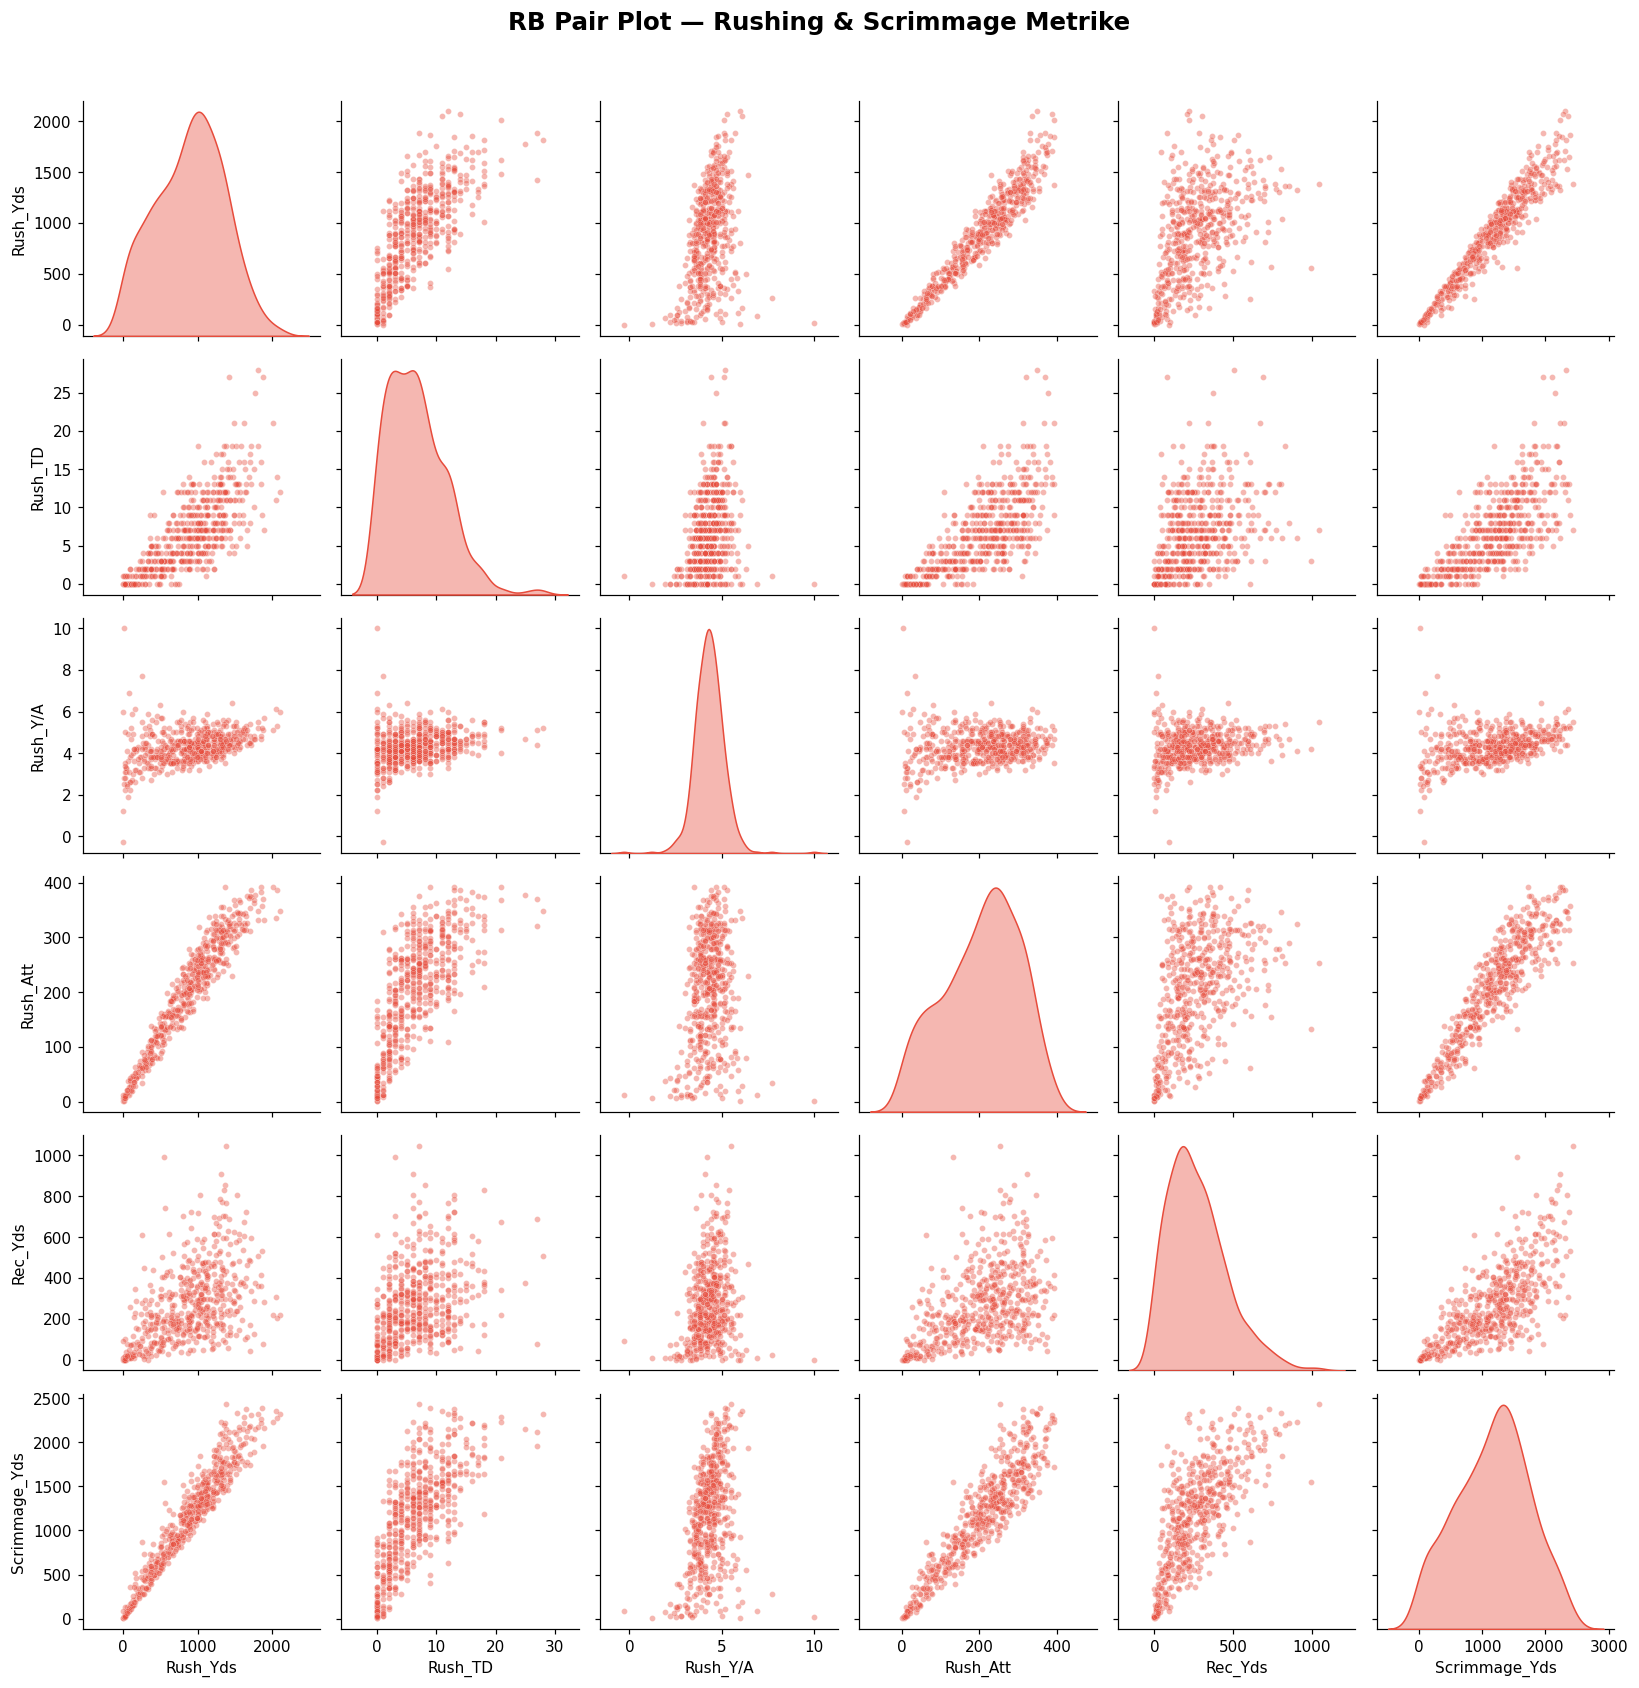

In [28]:
# ──────────────────────────────────────────────
# RB Pair Plot — rushing i scrimmage metrike
# ──────────────────────────────────────────────
rb_pair_cols = ['Rush_Yds', 'Rush_TD', 'Rush_Y/A', 'Rush_Att', 'Rec_Yds', 'Scrimmage_Yds']
rb_pair_cols = [c for c in rb_pair_cols if c in rb.columns]

rb_pair_df = rb[rb_pair_cols].dropna()

g = sns.pairplot(rb_pair_df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15, 'color': '#e74c3c'},
                 diag_kws={'color': '#e74c3c', 'fill': True, 'alpha': 0.4})
g.figure.suptitle('RB Pair Plot — Rushing & Scrimmage Metrike', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

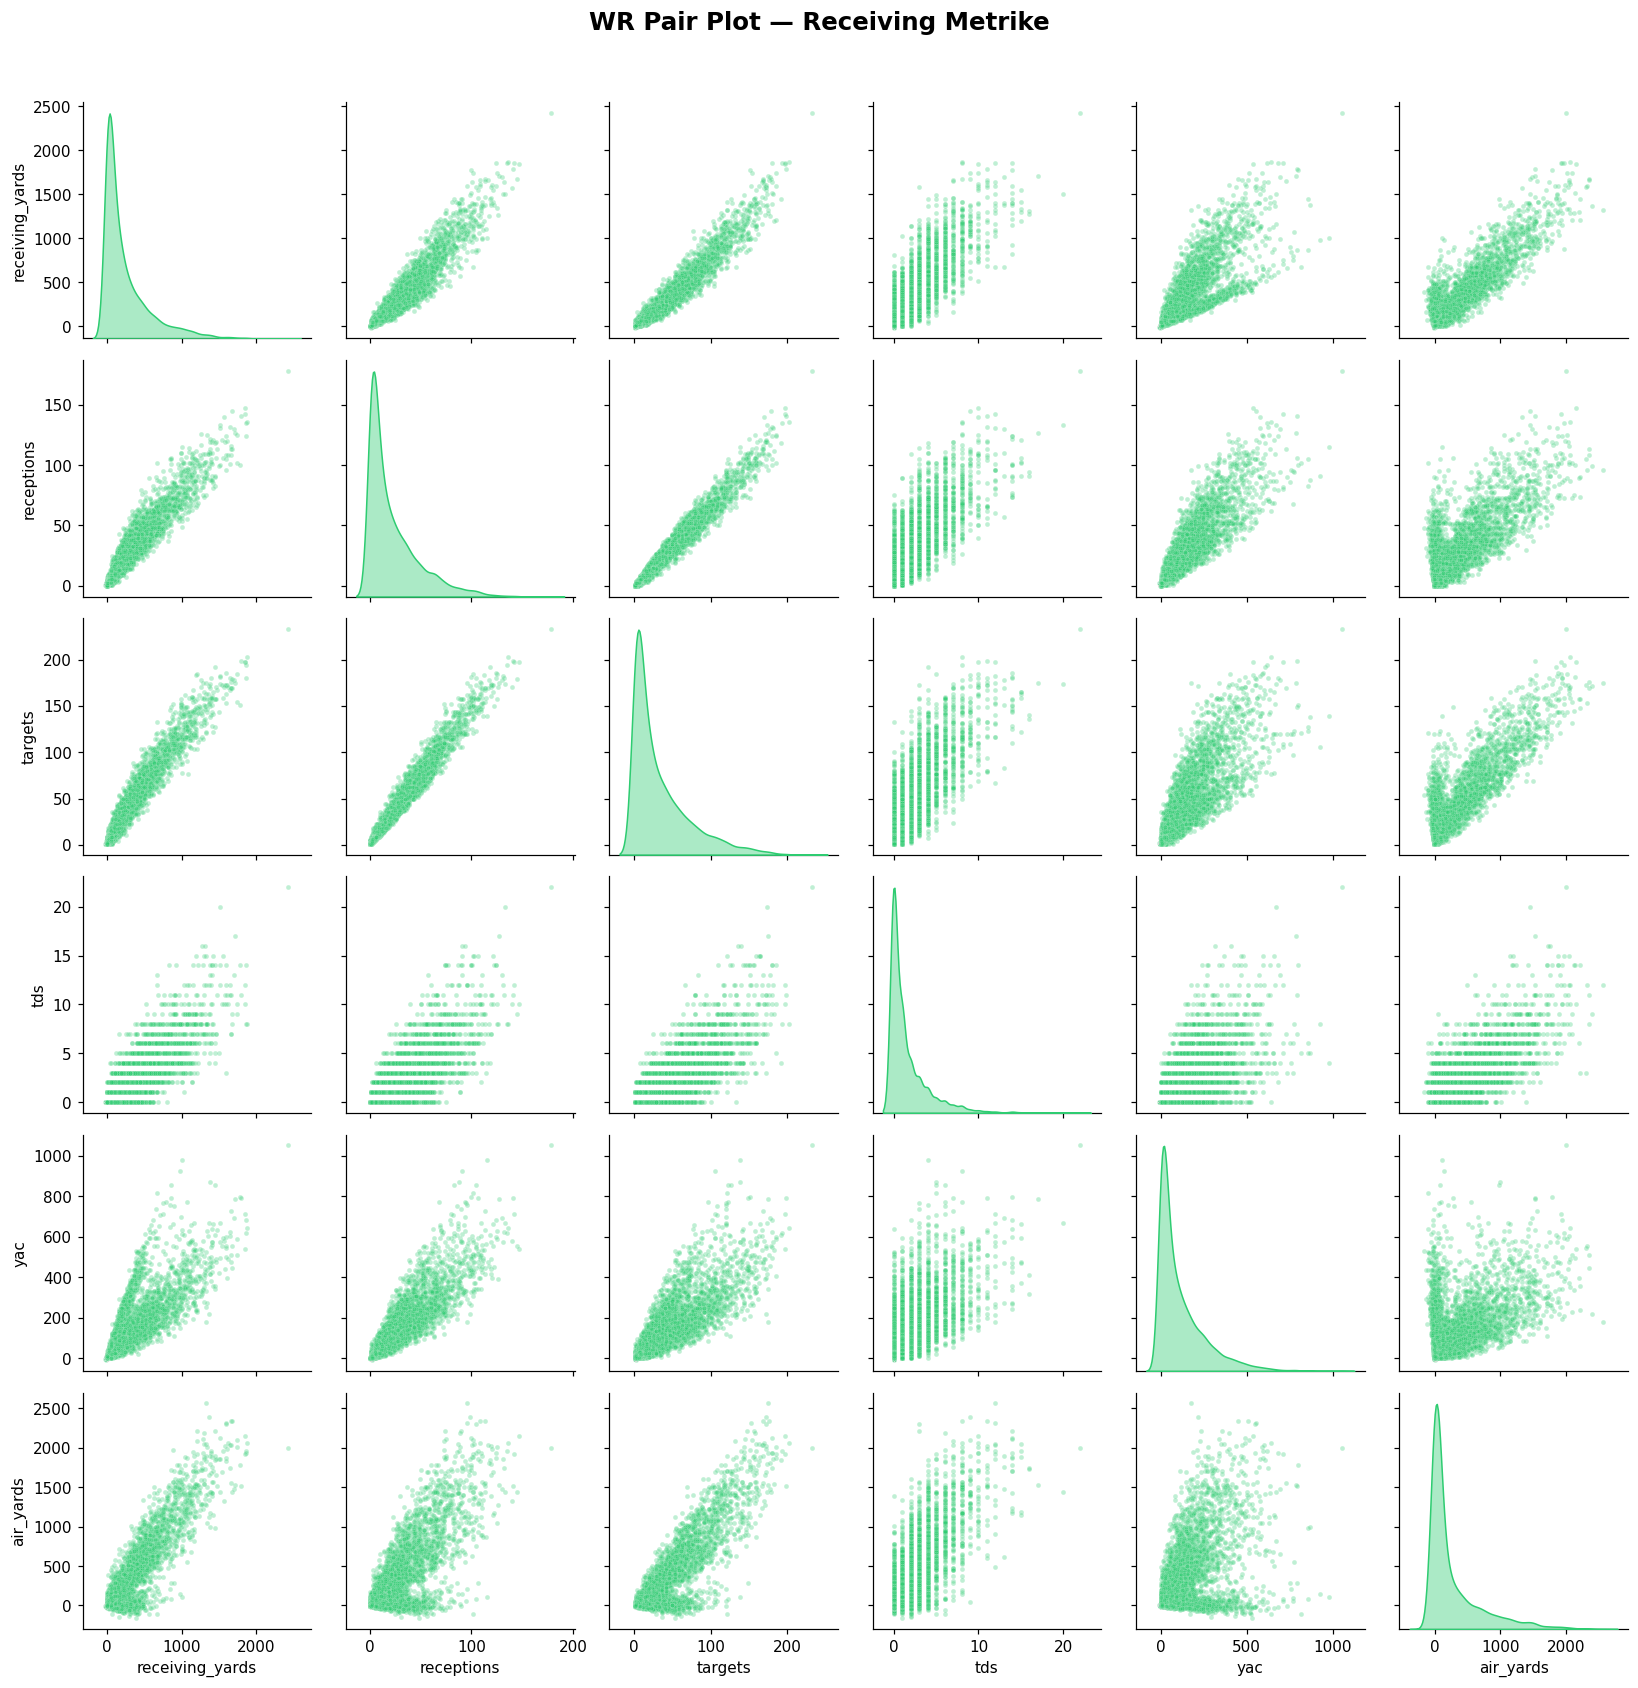

In [29]:
# ──────────────────────────────────────────────
# WR Pair Plot — receiving metrike
# ──────────────────────────────────────────────
wr = wr_seasons.copy() if 'wr_seasons' in dir() else wr

wr_pair_cols = ['receiving_yards', 'receptions', 'targets', 'tds', 'yac', 'air_yards']
wr_pair_cols = [c for c in wr_pair_cols if c in wr.columns]

wr_pair_df = wr[wr_pair_cols].dropna()

g = sns.pairplot(wr_pair_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10, 'color': '#2ecc71'},
                 diag_kws={'color': '#2ecc71', 'fill': True, 'alpha': 0.4})
g.figure.suptitle('WR Pair Plot — Receiving Metrike', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

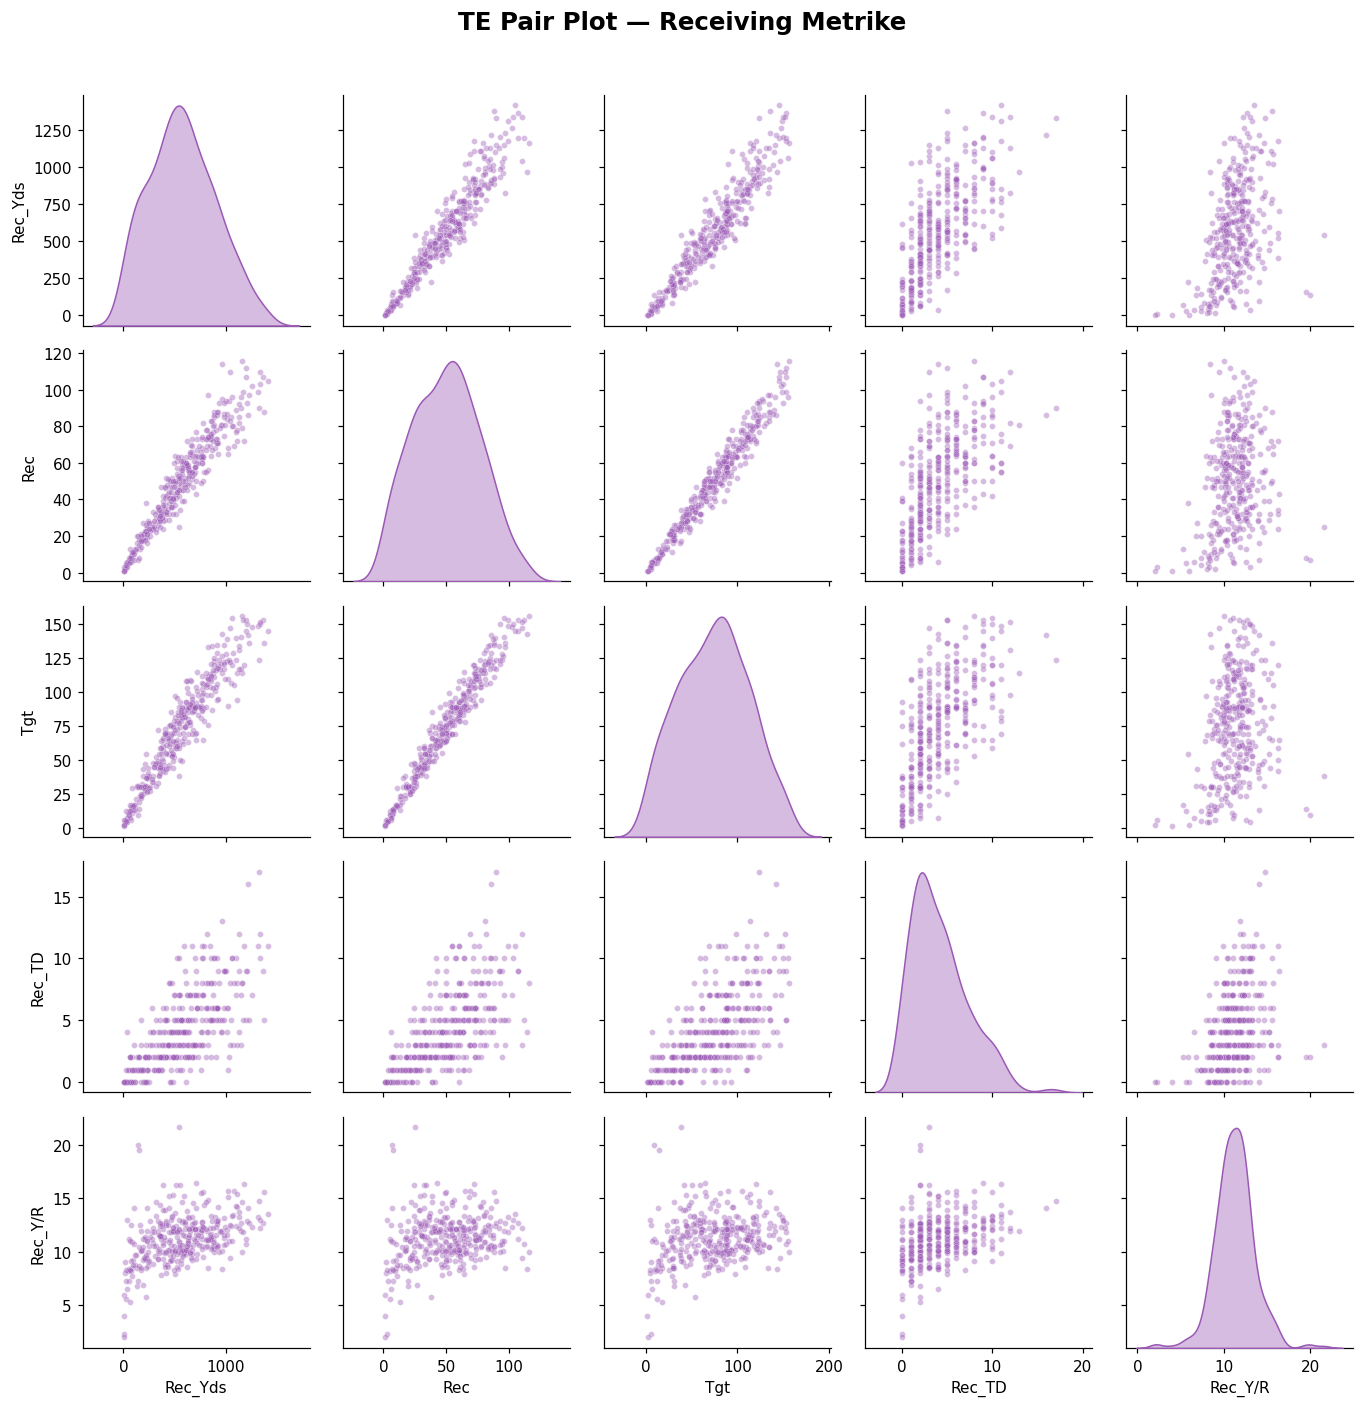

In [30]:
# ──────────────────────────────────────────────
# TE Pair Plot — receiving metrike
# ──────────────────────────────────────────────
te_pair_cols = ['Rec_Yds', 'Rec', 'Tgt', 'Rec_TD', 'Rec_Y/R', 'catch_pct']
te_pair_cols = [c for c in te_pair_cols if c in te.columns]

te_pair_df = te[te_pair_cols].dropna()

g = sns.pairplot(te_pair_df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15, 'color': '#9b59b6'},
                 diag_kws={'color': '#9b59b6', 'fill': True, 'alpha': 0.4})
g.figure.suptitle('TE Pair Plot — Receiving Metrike', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Trendovi po sezonama


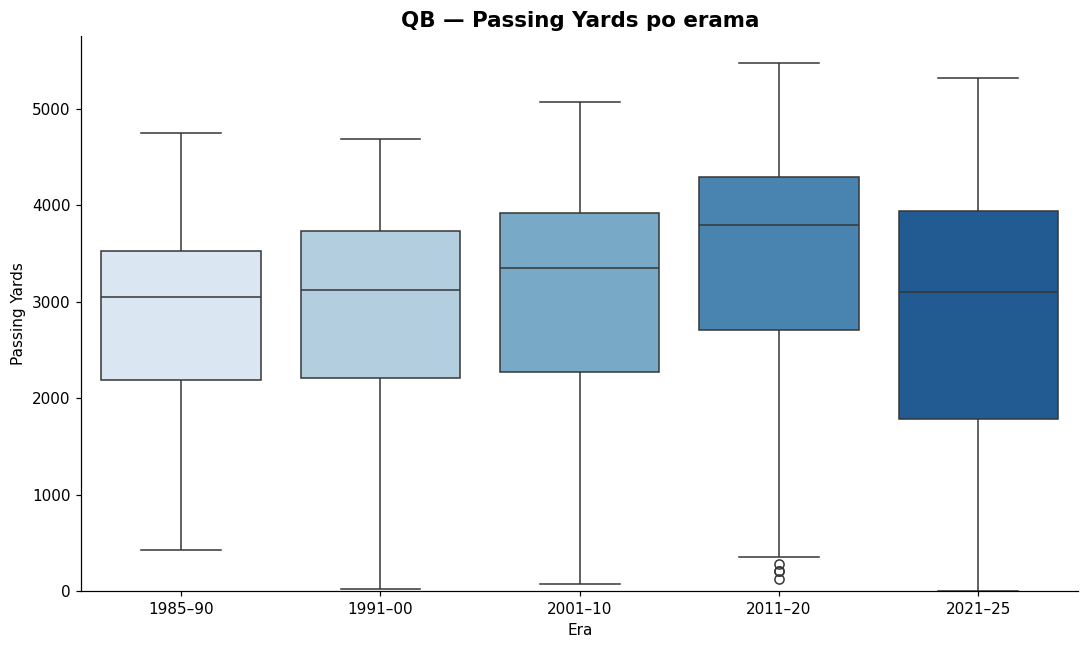

In [31]:

qb_starters = qb[(qb['GS'] > 0) & (qb['Season'] >= 1985)].copy()

# Era binovi za QB (1985–2025)
qb_starters['Era'] = pd.cut(qb_starters['Season'],
                              bins=[1984, 1990, 2000, 2010, 2020, 2026],
                              labels=['1985–90', '1991–00', '2001–10', '2011–20', '2021–25'])

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=qb_starters, x='Era', y='Yds', ax=ax, palette='Blues')
ax.set_title('QB — Passing Yards po erama', fontsize=14, fontweight='bold')
ax.set_ylabel('Passing Yards')
ax.set_xlabel('Era')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

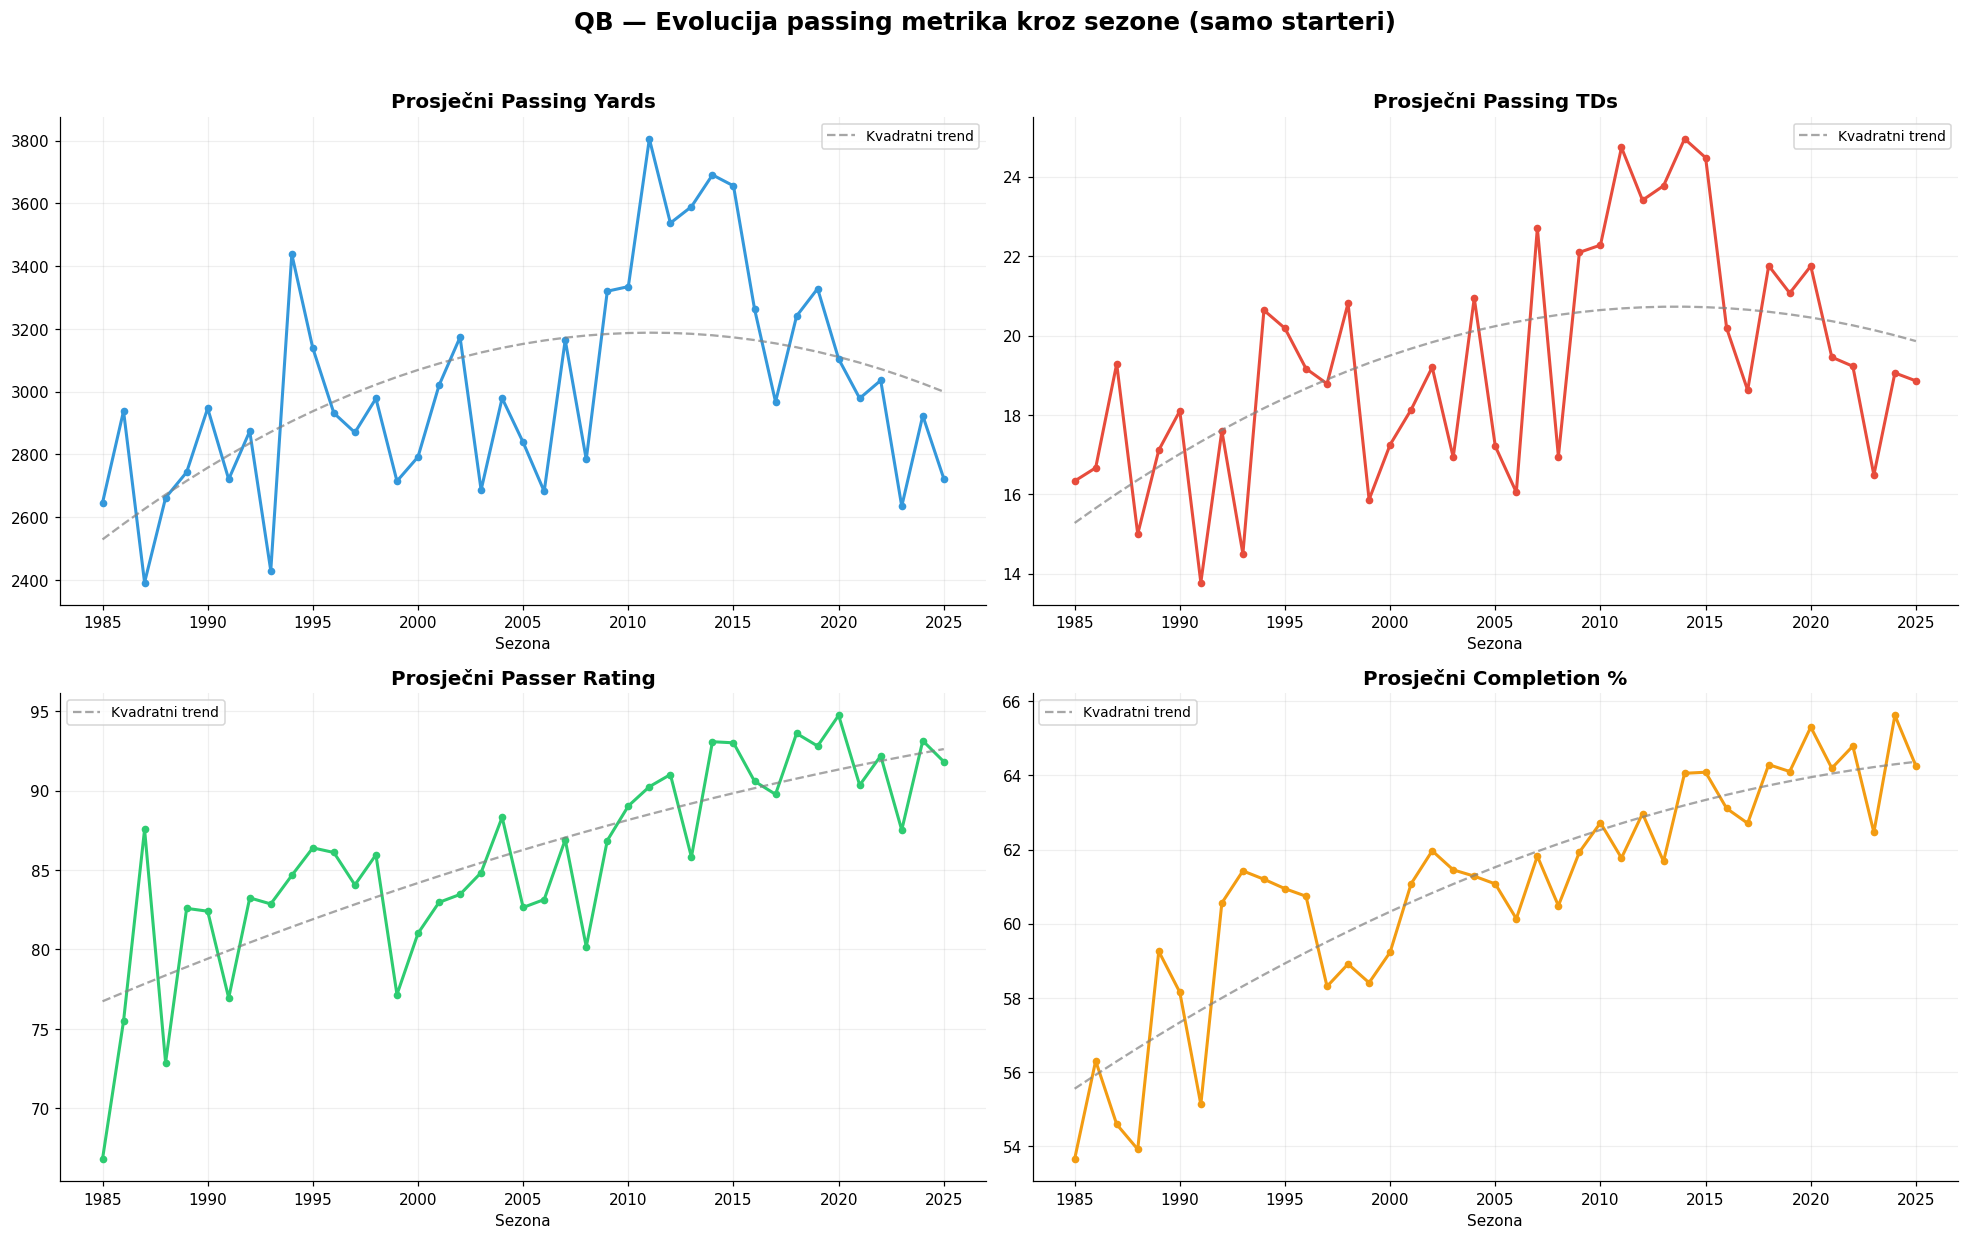

In [ ]:
# ──────────────────────────────────────────────
# QB — Evolucija ključnih passing metrika kroz vreme
# ──────────────────────────────────────────────

yearly_qb = qb_starters.groupby('Season').agg({
    'Yds': 'mean', 'TD': 'mean', 'Rate': 'mean', 'Cmp%': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

qb_metrics = [
    ('Yds',  'Prosječni Passing Yards',   '#3498db'),
    ('TD',   'Prosječni Passing TDs',     '#e74c3c'),
    ('Rate', 'Prosječni Passer Rating',   '#2ecc71'),
    ('Cmp%', 'Prosječni Completion %',    '#f39c12'),
]

for ax, (col, title, color) in zip(axes.flat, qb_metrics):
    y_vals = yearly_qb[col].dropna()
    x_vals = yearly_qb.loc[y_vals.index, 'Season']
    ax.plot(x_vals, y_vals, color=color, lw=2, marker='o', ms=4)
    # Kvadratni trend (2. stepen polinom)
    z = np.polyfit(x_vals, y_vals, 2)
    p = np.poly1d(z)
    ax.plot(x_vals, p(x_vals), '--', color='gray', lw=1.5, alpha=0.7, label='Kvadratni trend')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Sezona')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle('QB — Evolucija passing metrika kroz sezone (samo starteri)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**QB (Passing Yards)**
- Passing igra pokazuje konstantan rast kroz decenije. NFL pravila sve više favorizuju passing ofanzivu (zaštita QB-a, ograničenja na kontakt sa receiverima), što se direktno odražava na rast prosečnih passing jardi.
- Boxplot po erama jasno pokazuje pomak medijana passing jardi naviše: od ~3000 Yds u eri 1985–90 do ~3500+ Yds u eri 2011–20. Kvadratni trend na Yds, TD, Rate i Cmp% pokazuje ubrzanje rasta nakon 2010., što se poklapa sa uvođenjem strožih pravila o kontaktu sa receiverima.
- Od 2021. godine primećuje se blago smanjenje prosečnih passing jardi i TD, uz istovremeni rast Completion% i passer ratinga. Verovatno objašnjenje je adaptacija odbrana - sve češće korišćenje two-high safety šema i fokus na limitiranje dubokih pasova, čime se smanjuje eksplozivnost passing igre. Kako je passing postao znatno produktivniji od run game-a, odbrane su strateški preusmerile resurse na njegovo zaustavljanje. Istovremeno, povećanje prosečne startne pozicije napada (bolji field position) može doprineti kraćim napadačkim sekvencama i manjim ukupnim yardama.

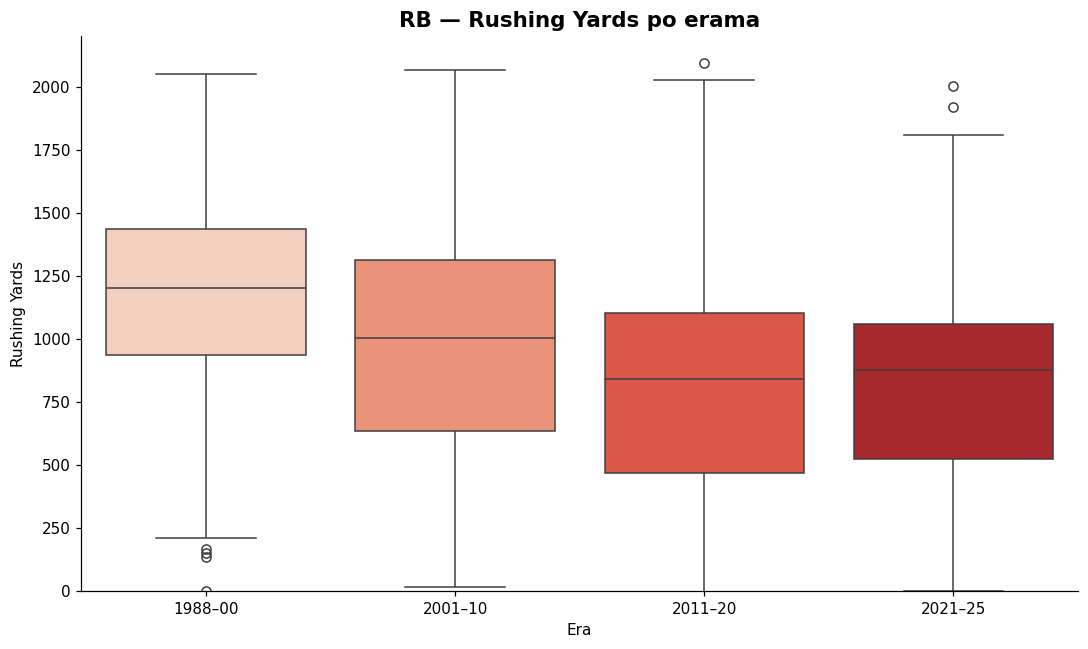

In [33]:
# ──────────────────────────────────────────────
# RB — Distribucija po erama
# ──────────────────────────────────────────────

rb_copy = rb.copy()

# Era binovi za RB (1988–2025)
rb_copy['Era'] = pd.cut(rb_copy['Season'],
                         bins=[1987, 2000, 2010, 2020, 2026],
                         labels=['1988–00', '2001–10', '2011–20', '2021–25'])

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=rb_copy, x='Era', y='Rush_Yds', ax=ax, palette='Reds')
ax.set_title('RB — Rushing Yards po erama', fontsize=14, fontweight='bold')
ax.set_ylabel('Rushing Yards')
ax.set_xlabel('Era')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

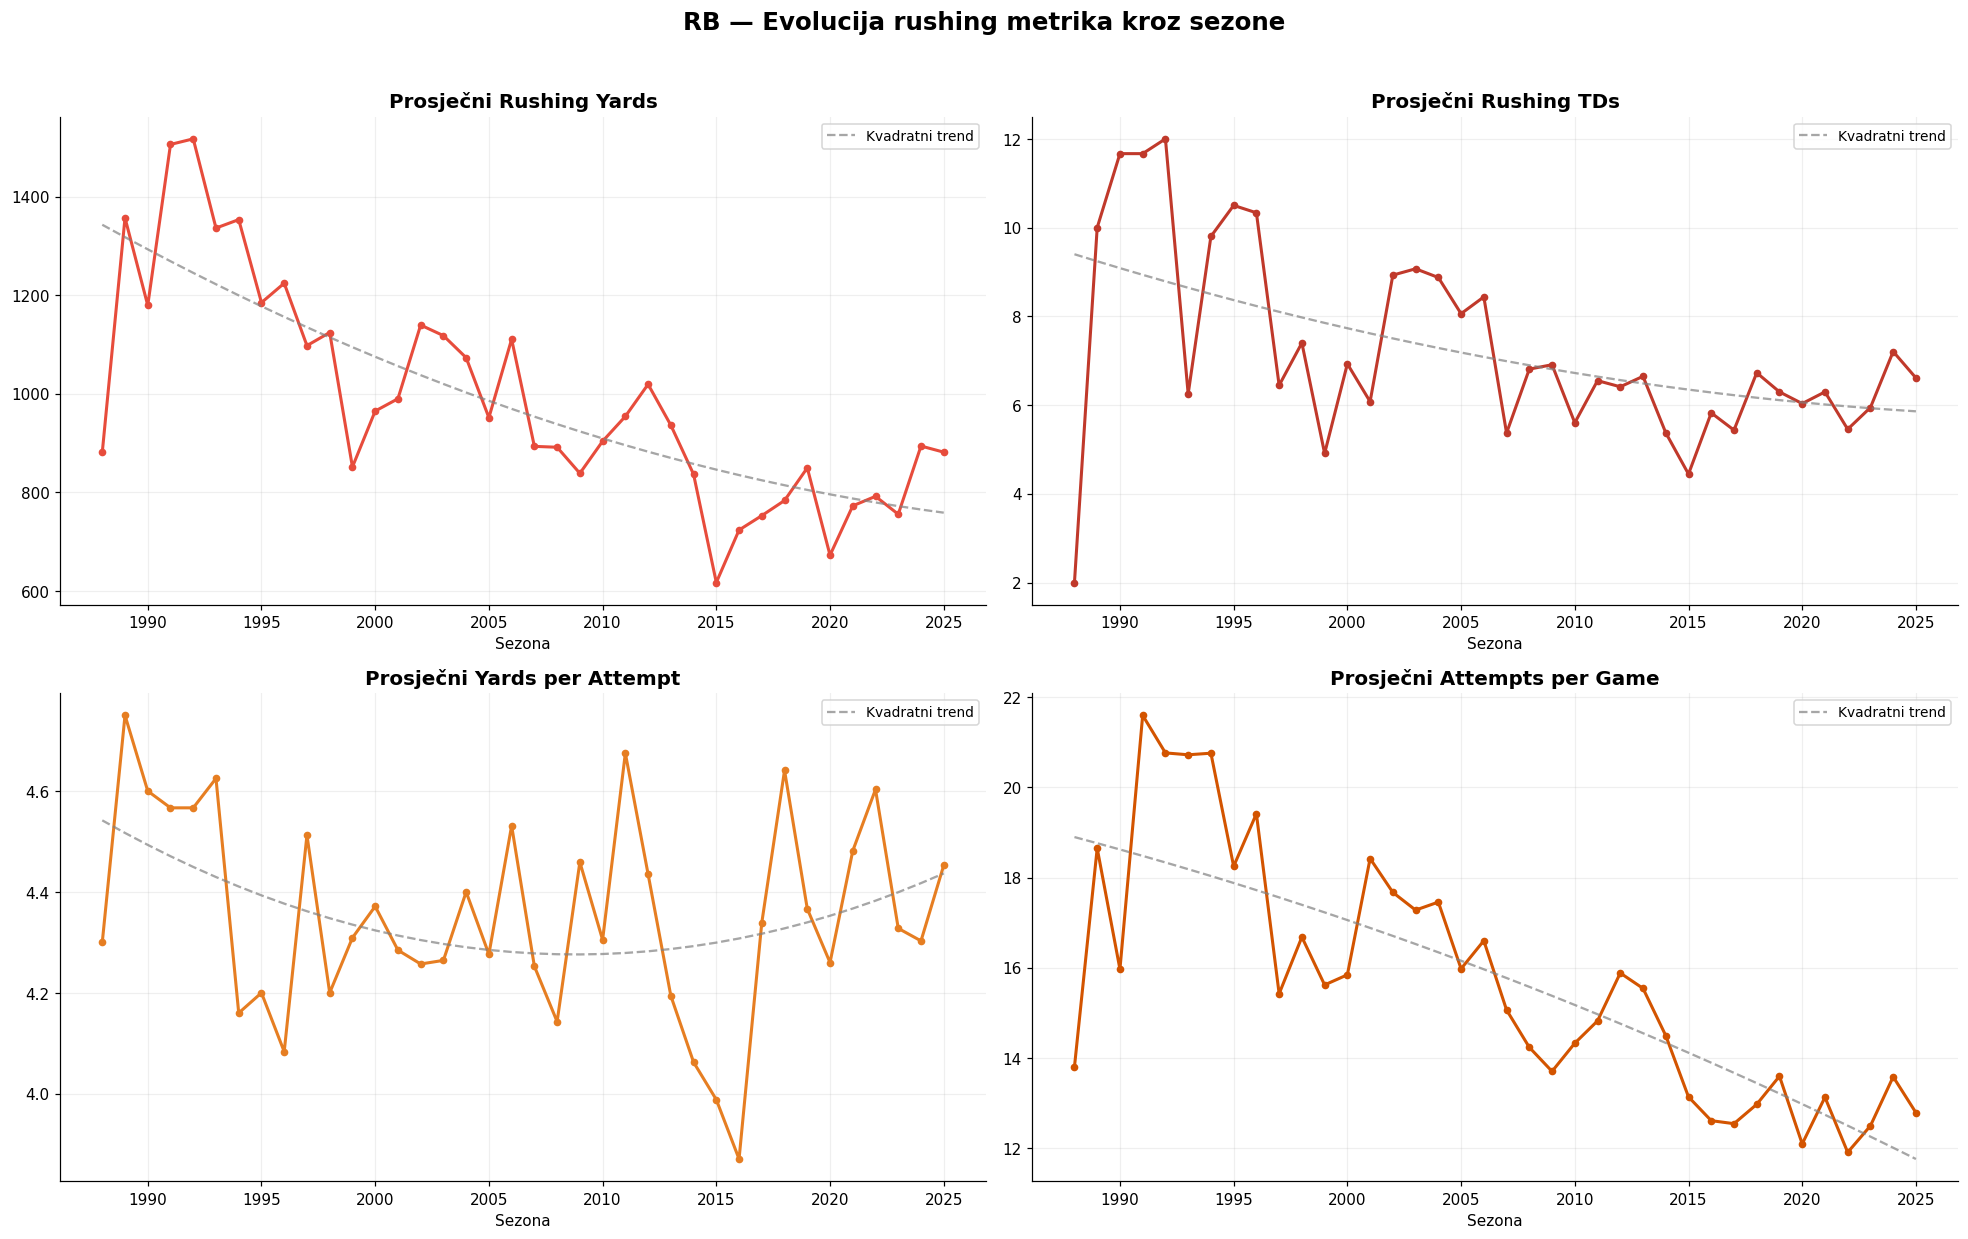

In [ ]:
# ──────────────────────────────────────────────
# RB — Evolucija ključnih rushing metrika kroz vreme
# ──────────────────────────────────────────────

yearly_rb = rb.groupby('Season').agg({
    'Rush_Yds': 'mean', 'Rush_TD': 'mean', 'Rush_Y/A': 'mean', 'Rush_A/G': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

rb_metrics = [
    ('Rush_Yds', 'Prosječni Rushing Yards',     '#e74c3c'),
    ('Rush_TD',  'Prosječni Rushing TDs',        '#c0392b'),
    ('Rush_Y/A', 'Prosječni Yards per Attempt',  '#e67e22'),
    ('Rush_A/G', 'Prosječni Attempts per Game',  '#d35400'),
]

for ax, (col, title, color) in zip(axes.flat, rb_metrics):
    y_vals = yearly_rb[col].dropna()
    x_vals = yearly_rb.loc[y_vals.index, 'Season']
    ax.plot(x_vals, y_vals, color=color, lw=2, marker='o', ms=4)
    z = np.polyfit(x_vals, y_vals, 2)
    p = np.poly1d(z)
    ax.plot(x_vals, p(x_vals), '--', color='gray', lw=1.5, alpha=0.7, label='Kvadratni trend')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Sezona')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle('RB — Evolucija rushing metrika kroz sezone',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**RB (Running Yards)**
- Kod RB pozicije primetan je gotovo konstantan pad rushing jardi kroz ere, što je posledica istorijskog prelaska sa run-orijentisane na pass-orijentisanu ofanzivu. Kako je passing igra postajala dominantna, uloga klasičnog RB-a u generisanju velikih yardi se smanjivala.

- U poslednjih nekoliko godina primećuje se blag rast rushing jardi, što se može povezati sa fokusom odbrana na zaustavljanje passing igre. Veći broj two-high šema i pokrivanja protiv pasa otvara više prostora za run game, što dovodi do blagog oporavka rushing produkcije.

## Najbolje pojedinačne sezone po yardima

Horizontalni bar chart za Top 10 sezona svake pozicije - samo regular season statistika (bez playoffa).

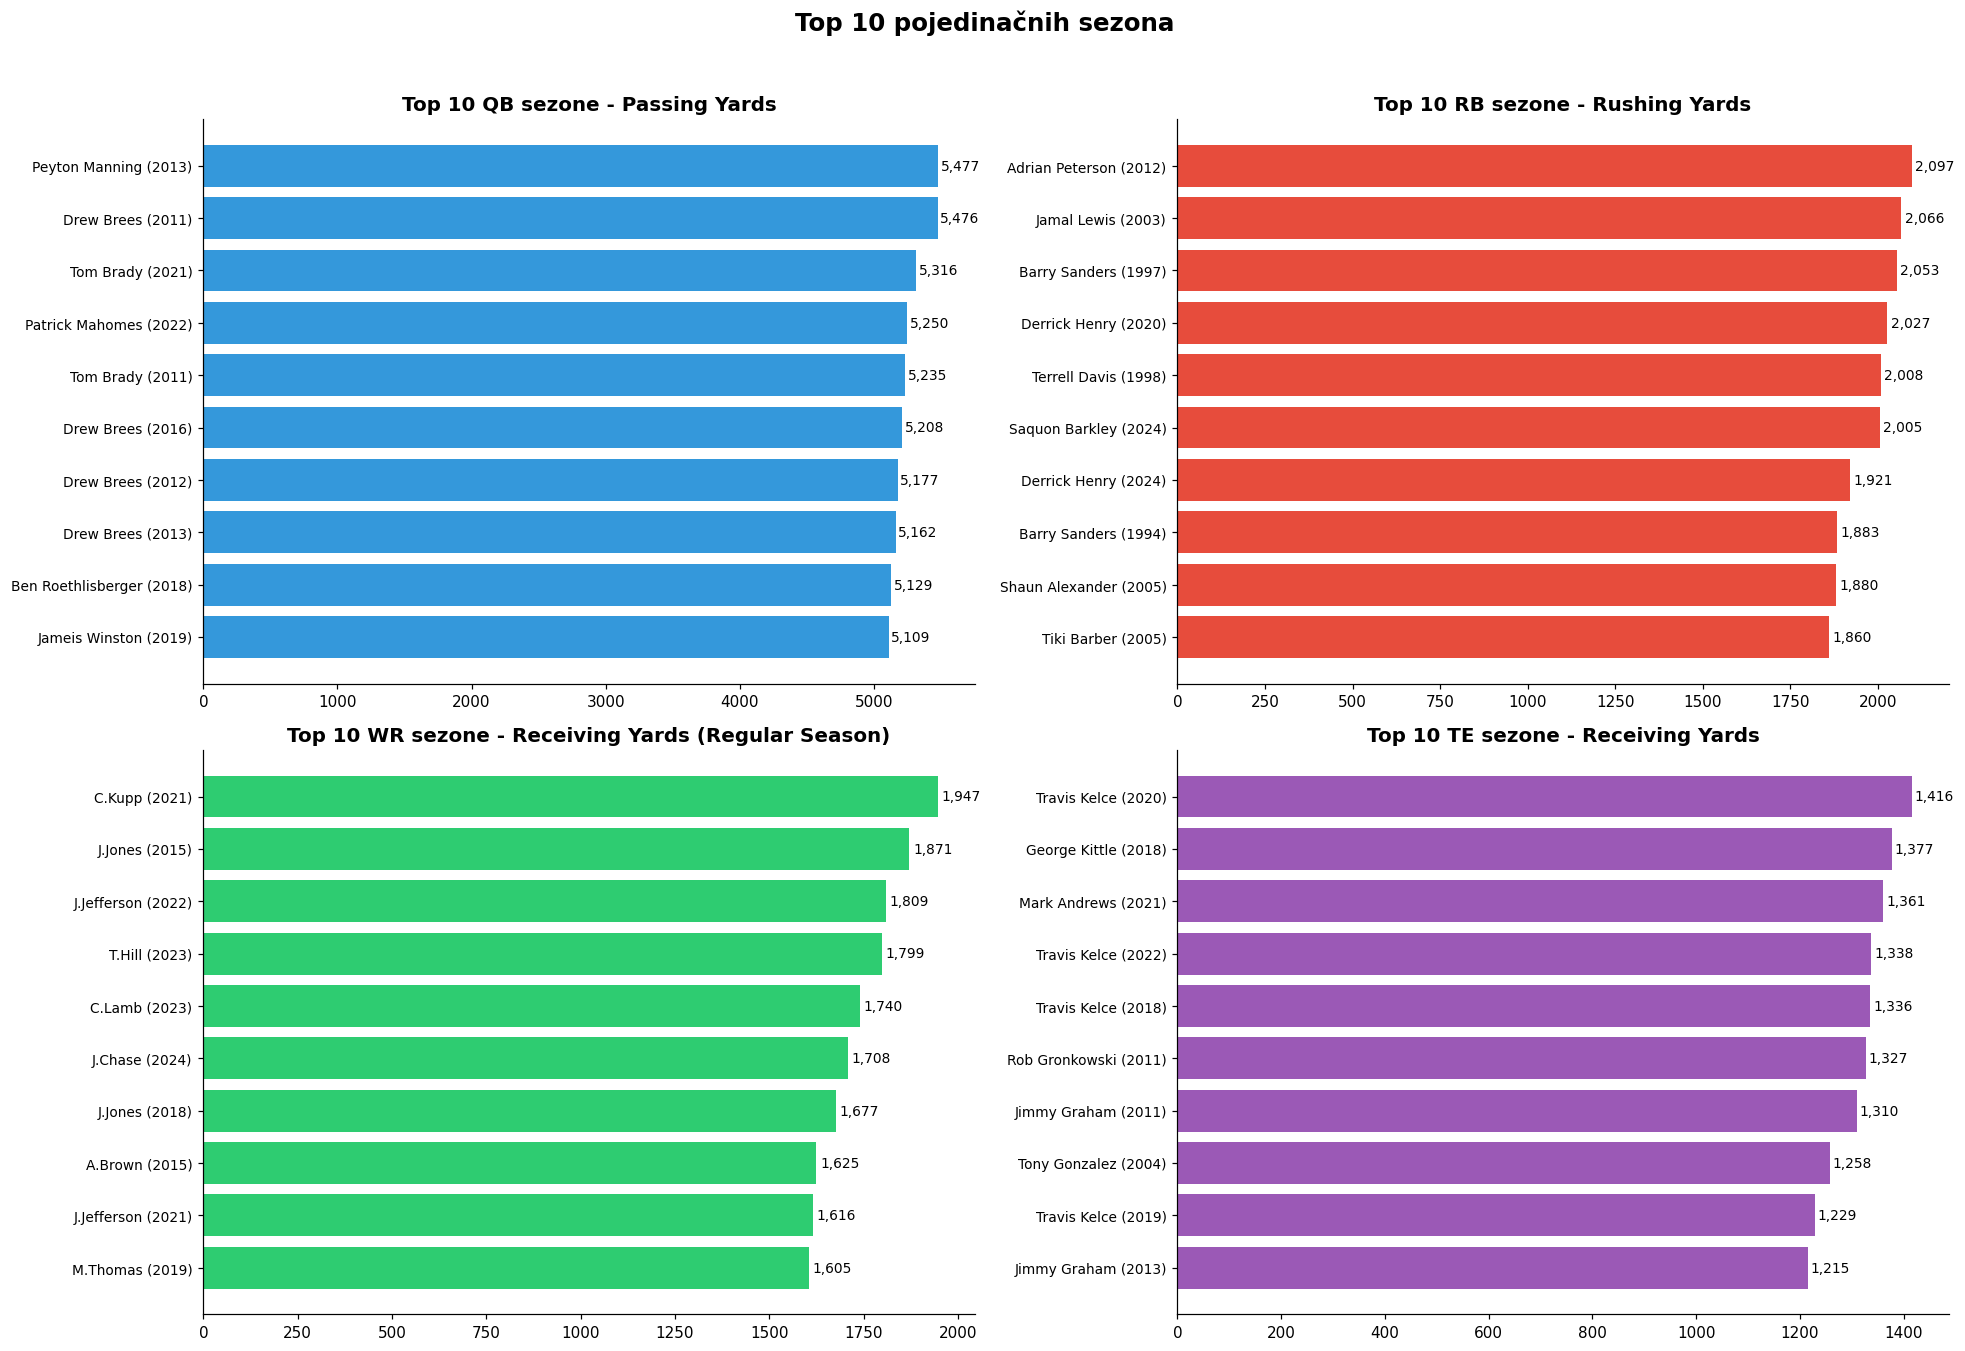

In [35]:
# Top 10 pojedinačnih sezona po yardima - za svaku poziciju (samo regular season)
# Ensure the required dataframes are present in the kernel; if not, load from disk.
import os
import pandas as pd
import matplotlib.pyplot as plt

data_dir = DATA_DIR if 'DATA_DIR' in globals() else os.path.join('data', 'fully combined')

if 'wr' not in globals() or 'qb' not in globals() or 'rb' not in globals() or 'te' not in globals():
    qb = pd.read_csv(os.path.join(data_dir, 'qb_master.csv'))
    rb = pd.read_csv(os.path.join(data_dir, 'rb_master.csv'))
    te = pd.read_csv(os.path.join(data_dir, 'te_master.csv'))

wr = pd.read_csv(os.path.join(data_dir, 'wr_all_seasons_without_playoffs.csv'))
# Some WR rows include playoff games (games_played > regular-season length).
# We filter WR to regular season only using `games_played` and season length rules.
# For seasons before 2021 regular season length was 16, from 2021 onward it's 17.
wr['games_played'] = wr['games_played'].fillna(0)
wr_reg = wr[
    ((wr['season'] < 2021) & (wr['games_played'] <= 21)) |
    ((wr['season'] >= 2021) & (wr['games_played'] <= 21))
]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# QB - Najbolje pojedinacne sezone
ax = axes[0, 0]
qb_top_seasons = qb.nlargest(10, 'Yds')[['Player', 'Season', 'Yds']].reset_index(drop=True)
qb_top_seasons['label'] = qb_top_seasons['Player'] + ' (' + qb_top_seasons['Season'].astype(str) + ')'
bars = ax.barh(range(len(qb_top_seasons)), qb_top_seasons['Yds'], color='#3498db')
ax.set_yticks(range(len(qb_top_seasons)))
ax.set_yticklabels(qb_top_seasons['label'], fontsize=9)
ax.set_title('Top 10 QB sezone - Passing Yards', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, qb_top_seasons['Yds']):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=9)

# RB
ax = axes[0, 1]
rb_top_seasons = rb.nlargest(10, 'Rush_Yds')[['Player', 'Season', 'Rush_Yds']].reset_index(drop=True)
rb_top_seasons['label'] = rb_top_seasons['Player'] + ' (' + rb_top_seasons['Season'].astype(str) + ')'
bars = ax.barh(range(len(rb_top_seasons)), rb_top_seasons['Rush_Yds'], color='#e74c3c')
ax.set_yticks(range(len(rb_top_seasons)))
ax.set_yticklabels(rb_top_seasons['label'], fontsize=9)
ax.set_title('Top 10 RB sezone - Rushing Yards', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, rb_top_seasons['Rush_Yds']):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=9)

# WR (filtrirano - samo regular season)
ax = axes[1, 0]
wr_top_seasons = wr_reg.nlargest(10, 'receiving_yards')[['receiver_player_name', 'season', 'receiving_yards']].reset_index(drop=True)
wr_top_seasons['label'] = wr_top_seasons['receiver_player_name'] + ' (' + wr_top_seasons['season'].astype(str) + ')'
bars = ax.barh(range(len(wr_top_seasons)), wr_top_seasons['receiving_yards'], color='#2ecc71')
ax.set_yticks(range(len(wr_top_seasons)))
ax.set_yticklabels(wr_top_seasons['label'], fontsize=9)
ax.set_title('Top 10 WR sezone - Receiving Yards (Regular Season)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, wr_top_seasons['receiving_yards']):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=9)

# TE
ax = axes[1, 1]
te_top_seasons = te.nlargest(10, 'Rec_Yds')[['Player', 'Season', 'Rec_Yds']].reset_index(drop=True)
te_top_seasons['label'] = te_top_seasons['Player'] + ' (' + te_top_seasons['Season'].astype(str) + ')'
bars = ax.barh(range(len(te_top_seasons)), te_top_seasons['Rec_Yds'], color='#9b59b6')
ax.set_yticks(range(len(te_top_seasons)))
ax.set_yticklabels(te_top_seasons['label'], fontsize=9)
ax.set_title('Top 10 TE sezone - Receiving Yards', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, te_top_seasons['Rec_Yds']):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=9)

fig.suptitle('Top 10 pojedinačnih sezona', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
wr = pd.read_csv(os.path.join(data_dir, 'wr_all_seasons.csv'))

## 6. Analiza kroz godine za pojedinca

### 6.1 QB – Passing Yards kroz sezone

Pratimo razvoj tri quarterbacka kroz karijeru: Tom Brady, Matthew Stafford i Kirk Cousins.

Graf prikazuje ukupne passing yarde po sezoni za svakog od trojice igrača.

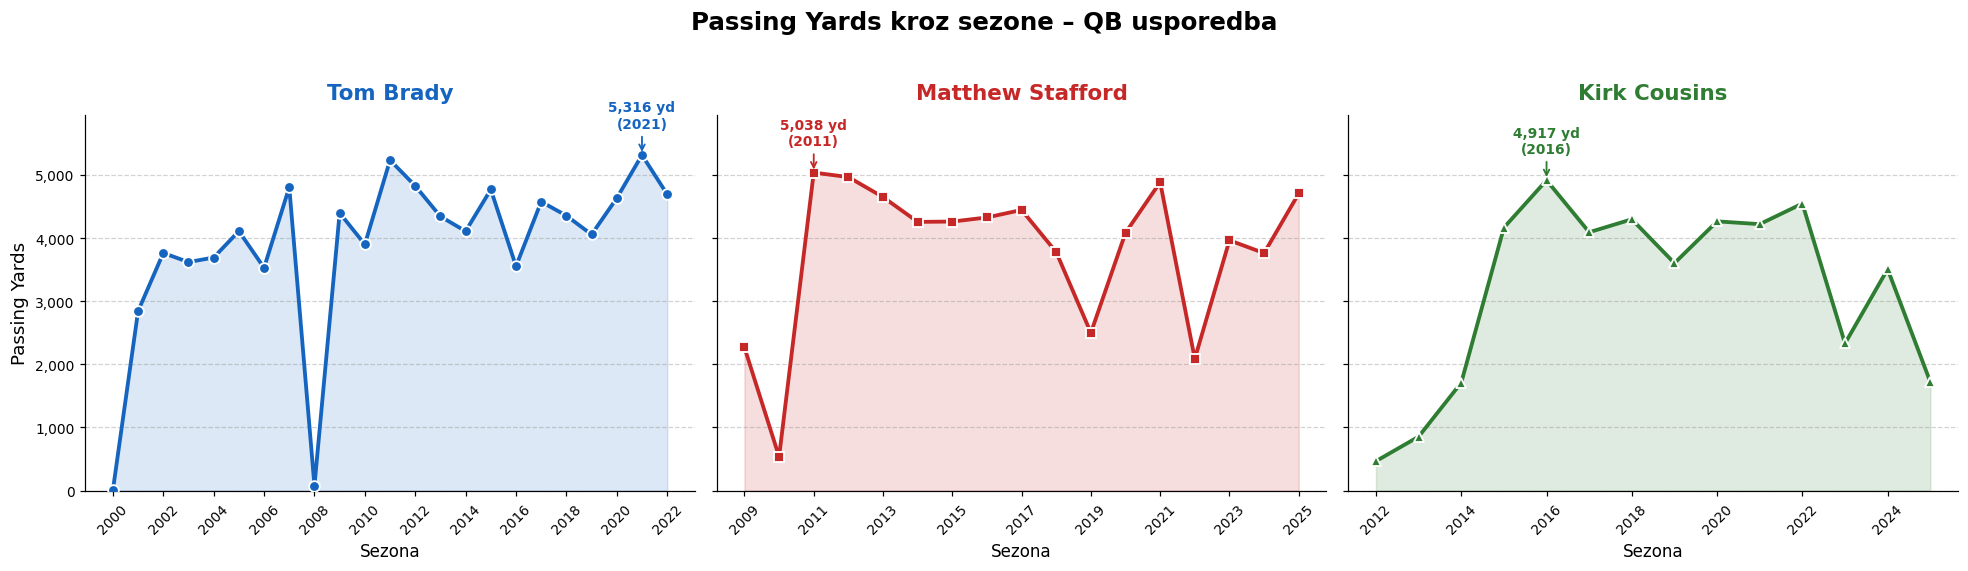

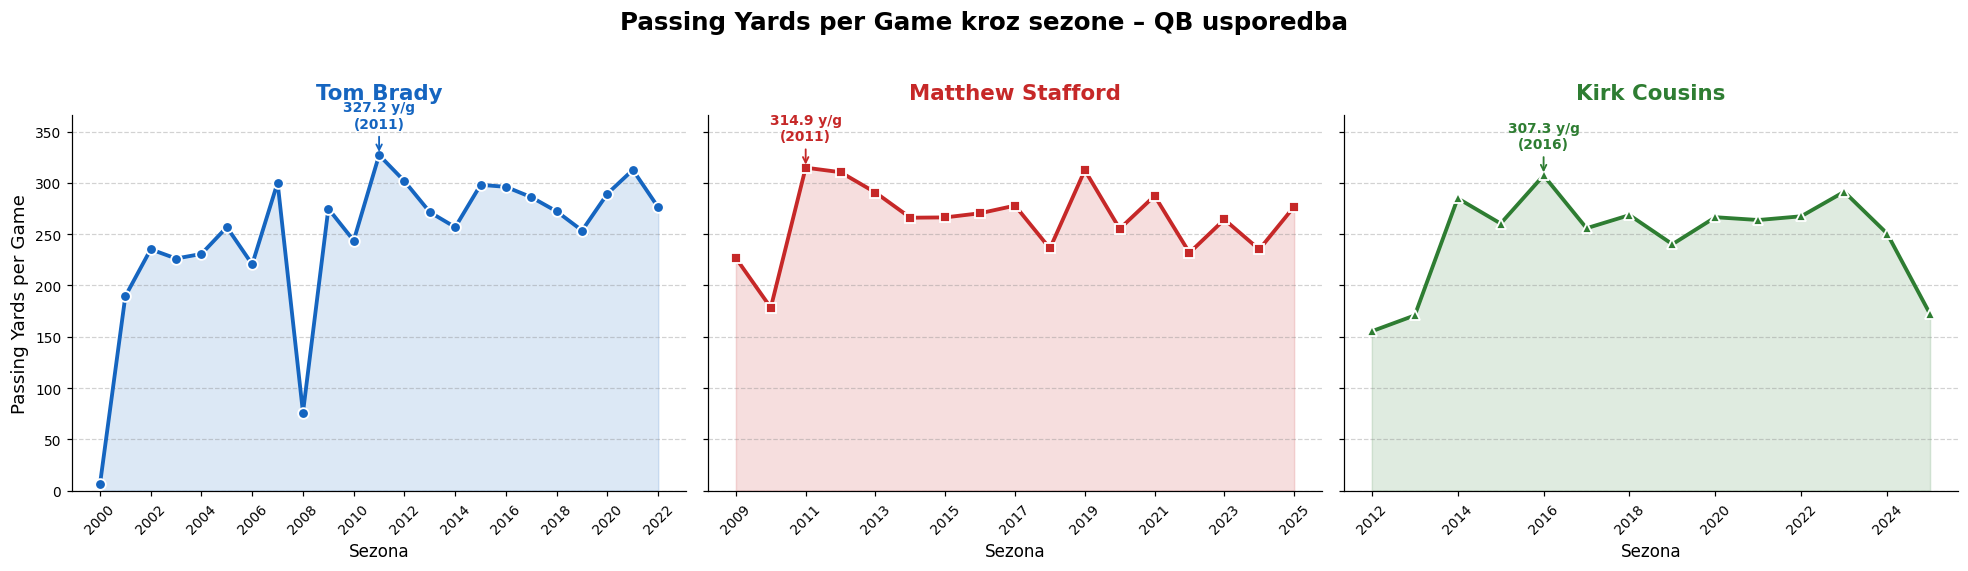

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

qb_df = pd.read_csv('../data/fully combined/qb_master.csv')

qb_players = ['Tom Brady', 'Matthew Stafford', 'Kirk Cousins']
qb_sel = qb_df[qb_df['Player'].isin(qb_players)][['Player', 'Season', 'Yds']].copy()
qb_sel = qb_sel.groupby(['Player', 'Season'], as_index=False)['Yds'].sum()
qb_sel = qb_sel[qb_sel['Yds'] > 0]

colors = {'Tom Brady': '#1565C0', 'Matthew Stafford': '#C62828', 'Kirk Cousins': '#2E7D32'}
markers = {'Tom Brady': 'o', 'Matthew Stafford': 's', 'Kirk Cousins': '^'}
fills  = {'Tom Brady': '#90CAF9', 'Matthew Stafford': '#EF9A9A', 'Kirk Cousins': '#A5D6A7'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.patch.set_facecolor('white')

all_seasons = sorted(qb_sel['Season'].unique())
y_max = qb_sel['Yds'].max() * 1.12

for idx, player in enumerate(qb_players):
    ax = axes[idx]
    data = qb_sel[qb_sel['Player'] == player].sort_values('Season')

    # Filled area + line
    ax.fill_between(data['Season'], data['Yds'], alpha=0.15, color=colors[player])
    ax.plot(data['Season'], data['Yds'],
            color=colors[player], marker=markers[player],
            linewidth=2.5, markersize=7, markeredgecolor='white', markeredgewidth=1.2,
            zorder=3)

    # Annotate peak season
    peak_idx = data['Yds'].idxmax()
    peak = data.loc[peak_idx]
    ax.annotate(f"{int(peak['Yds']):,} yd\n({int(peak['Season'])})",
                xy=(peak['Season'], peak['Yds']),
                xytext=(0, 16), textcoords='offset points',
                fontsize=9, fontweight='bold', color=colors[player],
                ha='center', va='bottom',
                arrowprops=dict(arrowstyle='->', color=colors[player], lw=1.2))

    ax.set_title(player, fontsize=14, fontweight='bold', color=colors[player], pad=10)
    ax.set_xlabel('Sezona', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Passing Yards', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_ylim(0, y_max)

    # X-ticks: show every 2nd season for clarity
    player_seasons = sorted(data['Season'].unique())
    ax.set_xticks(player_seasons[::2])
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Passing Yards kroz sezone – QB usporedba', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Isti grafik kao gore, ali sa Yards per Game na Y osi umesto ukupnih jardi
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

qb_df = pd.read_csv('../data/fully combined/qb_master.csv')

qb_players = ['Tom Brady', 'Matthew Stafford', 'Kirk Cousins']
qb_sel = qb_df[qb_df['Player'].isin(qb_players)][['Player', 'Season', 'G', 'Yds']].copy()
qb_sel = qb_sel.groupby(['Player', 'Season'], as_index=False).agg({'G': 'sum', 'Yds': 'sum'})
qb_sel = qb_sel[qb_sel['Yds'] > 0]
qb_sel['Y/G'] = qb_sel['Yds'] / qb_sel['G']

colors = {'Tom Brady': '#1565C0', 'Matthew Stafford': '#C62828', 'Kirk Cousins': '#2E7D32'}
markers = {'Tom Brady': 'o', 'Matthew Stafford': 's', 'Kirk Cousins': '^'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.patch.set_facecolor('white')

y_max = qb_sel['Y/G'].max() * 1.12

for idx, player in enumerate(qb_players):
    ax = axes[idx]
    data = qb_sel[qb_sel['Player'] == player].sort_values('Season')

    ax.fill_between(data['Season'], data['Y/G'], alpha=0.15, color=colors[player])
    ax.plot(data['Season'], data['Y/G'],
            color=colors[player], marker=markers[player],
            linewidth=2.5, markersize=7, markeredgecolor='white', markeredgewidth=1.2,
            zorder=3)

    # Annotate peak season
    peak_idx = data['Y/G'].idxmax()
    peak = data.loc[peak_idx]
    ax.annotate(f"{peak['Y/G']:.1f} y/g\n({int(peak['Season'])})",
                xy=(peak['Season'], peak['Y/G']),
                xytext=(0, 16), textcoords='offset points',
                fontsize=9, fontweight='bold', color=colors[player],
                ha='center', va='bottom',
                arrowprops=dict(arrowstyle='->', color=colors[player], lw=1.2))

    ax.set_title(player, fontsize=14, fontweight='bold', color=colors[player], pad=10)
    ax.set_xlabel('Sezona', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Passing Yards per Game', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.set_ylim(0, y_max)

    player_seasons = sorted(data['Season'].unique())
    ax.set_xticks(player_seasons[::2])
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Passing Yards per Game kroz sezone – QB usporedba', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### Uticaj povreda na QB produkciju:

Ukupna statistika u sezoni često može zavarati jer ne pravi razliku između loše igre i vremena provedenog van terena. Najbolji primer je Tom Brady 2008. godine; nakon teške povrede kolena u prvom kolu, sezonu je završio sa samo 76 jardi. To nije bio odraz pada njegovog kvaliteta, već činjenice da fizički nije bio na terenu.

Slične situacije videli smo kod igrača kao što su Matthew Stafford i Kirk Cousins. Kada solidan kvoterbek propusti polovinu utakmica zbog povrede, na tabeli ukupnih jardi preteći će ga čak i prosečni igrači koji su samo ostali zdravi. Povrede su nepredvidive i drastično "skraćuju" produkciju na papiru, iako igrač možda igra na vrhunskom nivou dok je zdrav.

Ova vizuelizacija je još jedna potvrda naše odluke da yards per game bude naša ciljna varijabla.

### 6.2 RB – Rushing Yards kroz sezone
 
Pratimo tri running backa i njihove sezonske rushing yarde: Adrian Peterson, Alvin Kamara i Saquon Barkley.

Graf prikazuje ukupne rushing yarde po sezoni za svakog od trojice igrača.

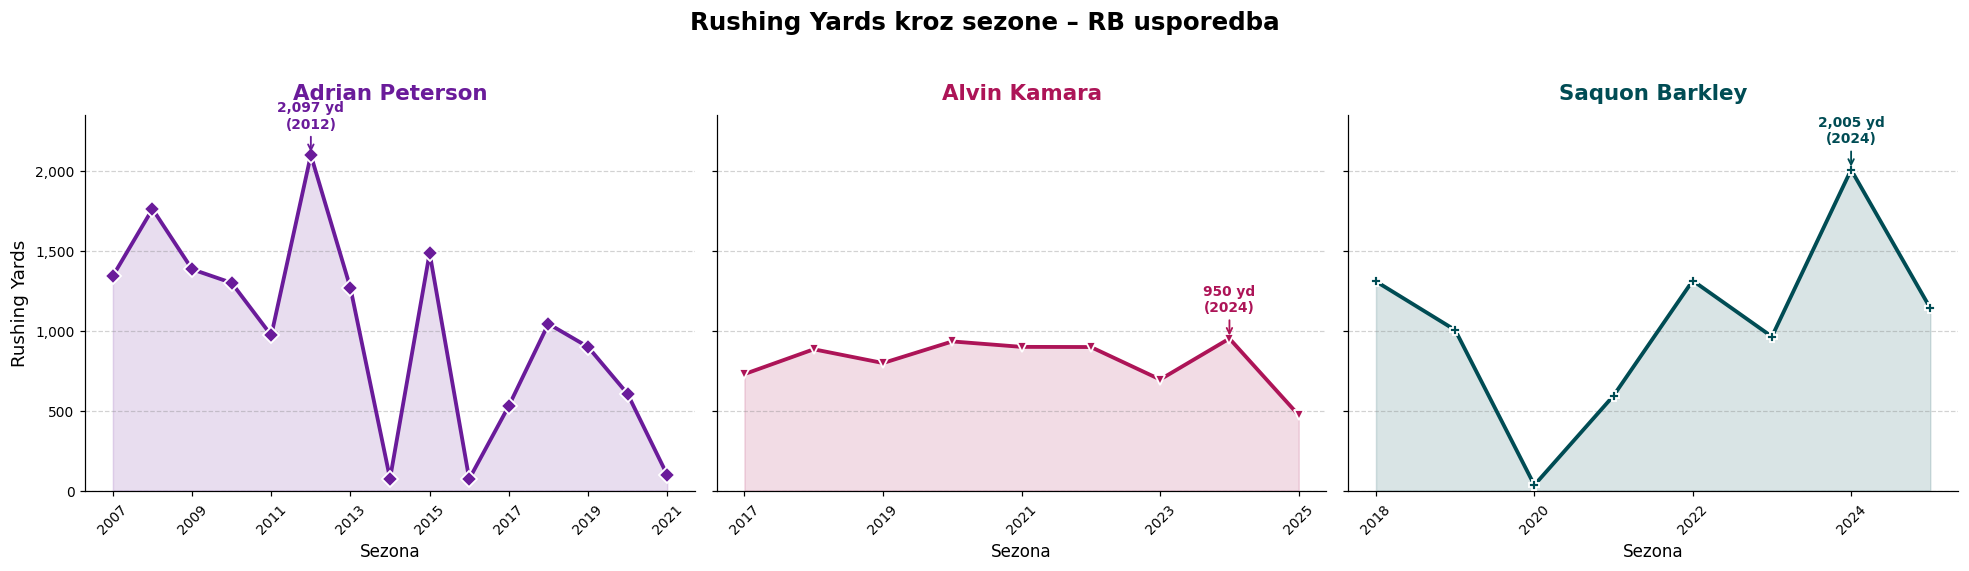

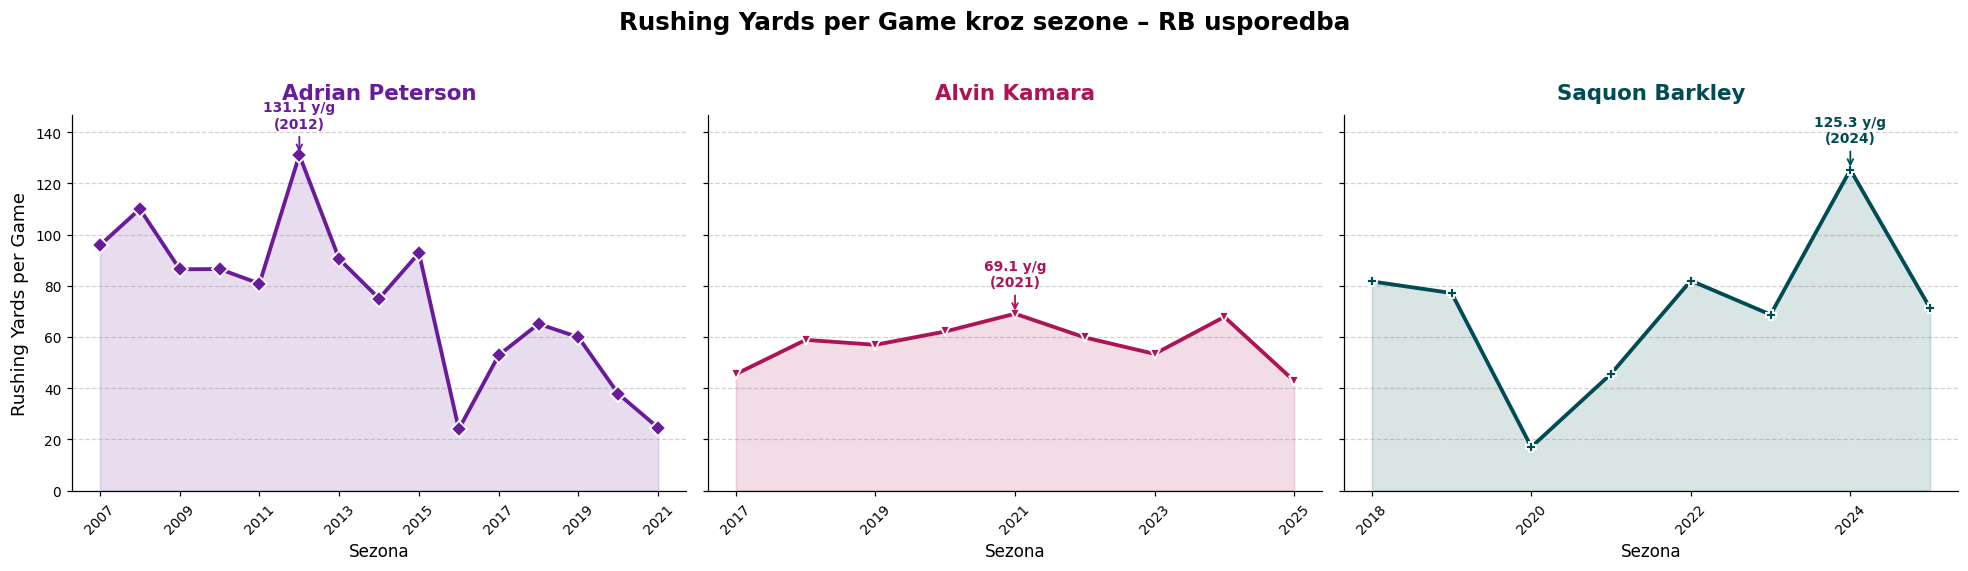

In [37]:
rb_df = pd.read_csv('../data/fully combined/rb_master.csv')

rb_players = ['Adrian Peterson', 'Alvin Kamara', 'Saquon Barkley']
rb_sel = rb_df[rb_df['Player'].isin(rb_players)][['Player', 'Season', 'Rush_Yds']].copy()
rb_sel = rb_sel.groupby(['Player', 'Season'], as_index=False)['Rush_Yds'].sum()
rb_sel = rb_sel[rb_sel['Rush_Yds'] > 0]

rb_colors  = {'Adrian Peterson': '#6A1B9A', 'Alvin Kamara': '#AD1457', 'Saquon Barkley': '#004C54'}
rb_markers = {'Adrian Peterson': 'D', 'Alvin Kamara': 'v', 'Saquon Barkley': 'P'}
rb_fills   = {'Adrian Peterson': '#CE93D8', 'Alvin Kamara': '#F48FB1', 'Saquon Barkley': '#A8D5BA'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.patch.set_facecolor('white')

y_max = rb_sel['Rush_Yds'].max() * 1.12

for idx, player in enumerate(rb_players):
    ax = axes[idx]
    data = rb_sel[rb_sel['Player'] == player].sort_values('Season')

    # Filled area + line
    ax.fill_between(data['Season'], data['Rush_Yds'], alpha=0.15, color=rb_colors[player])
    ax.plot(data['Season'], data['Rush_Yds'],
            color=rb_colors[player], marker=rb_markers[player],
            linewidth=2.5, markersize=7, markeredgecolor='white', markeredgewidth=1.2,
            zorder=3)

    # Annotate peak season
    peak_idx = data['Rush_Yds'].idxmax()
    peak = data.loc[peak_idx]
    ax.annotate(f"{int(peak['Rush_Yds']):,} yd\n({int(peak['Season'])})",
                xy=(peak['Season'], peak['Rush_Yds']),
                xytext=(0, 16), textcoords='offset points',
                fontsize=9, fontweight='bold', color=rb_colors[player],
                ha='center', va='bottom',
                arrowprops=dict(arrowstyle='->', color=rb_colors[player], lw=1.2))

    ax.set_title(player, fontsize=14, fontweight='bold', color=rb_colors[player], pad=10)
    ax.set_xlabel('Sezona', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Rushing Yards', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_ylim(0, y_max)

    # X-ticks: show every 2nd season for clarity
    player_seasons = sorted(data['Season'].unique())
    ax.set_xticks(player_seasons[::2])
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Rushing Yards kroz sezone – RB usporedba', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()
# Isti grafik kao gore, ali sa Rush Yards per Game na Y osi umesto ukupnih jardi
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

rb_df = pd.read_csv('../data/fully combined/rb_master.csv')

rb_players = ['Adrian Peterson', 'Alvin Kamara', 'Saquon Barkley']
rb_sel = rb_df[rb_df['Player'].isin(rb_players)][['Player', 'Season', 'G', 'Rush_Yds']].copy()
rb_sel = rb_sel.groupby(['Player', 'Season'], as_index=False).agg({'G': 'sum', 'Rush_Yds': 'sum'})
rb_sel = rb_sel[rb_sel['Rush_Yds'] > 0]
rb_sel['Rush_Y/G'] = rb_sel['Rush_Yds'] / rb_sel['G']

rb_colors  = {'Adrian Peterson': '#6A1B9A', 'Alvin Kamara': '#AD1457', 'Saquon Barkley': '#004C54'}
rb_markers = {'Adrian Peterson': 'D', 'Alvin Kamara': 'v', 'Saquon Barkley': 'P'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.patch.set_facecolor('white')

y_max = rb_sel['Rush_Y/G'].max() * 1.12

for idx, player in enumerate(rb_players):
    ax = axes[idx]
    data = rb_sel[rb_sel['Player'] == player].sort_values('Season')

    ax.fill_between(data['Season'], data['Rush_Y/G'], alpha=0.15, color=rb_colors[player])
    ax.plot(data['Season'], data['Rush_Y/G'],
            color=rb_colors[player], marker=rb_markers[player],
            linewidth=2.5, markersize=7, markeredgecolor='white', markeredgewidth=1.2,
            zorder=3)

    # Annotate peak season
    peak_idx = data['Rush_Y/G'].idxmax()
    peak = data.loc[peak_idx]
    ax.annotate(f"{peak['Rush_Y/G']:.1f} y/g\n({int(peak['Season'])})",
                xy=(peak['Season'], peak['Rush_Y/G']),
                xytext=(0, 16), textcoords='offset points',
                fontsize=9, fontweight='bold', color=rb_colors[player],
                ha='center', va='bottom',
                arrowprops=dict(arrowstyle='->', color=rb_colors[player], lw=1.2))

    ax.set_title(player, fontsize=14, fontweight='bold', color=rb_colors[player], pad=10)
    ax.set_xlabel('Sezona', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Rushing Yards per Game', fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.set_ylim(0, y_max)

    player_seasons = sorted(data['Season'].unique())
    ax.set_xticks(player_seasons[::2])
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    ax.grid(axis='y', linestyle='--', alpha=0.35, color='grey')
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Rushing Yards per Game kroz sezone – RB usporedba', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Uticaj povreda na RB produkciju:**

Kod running backova su povrede još kritičniji faktor nego kod QB-jeva. Drastični padovi u produkciji, poput onih kod Barkleya (2020) ili Petersona (2014), nisu posledica loše igre, već fizičkog odsustva sa terena. Takve "rupe" u podacima model teško može objasniti bez konteksta povreda.

Suprotan primer je Alvin Kamara, čija karijera bez težih povreda pokazuje konstantan i predvidiv put. Njegova statistika nema nagle padove, što je idealno za precizne predikcije.

### 6.3 Uticaj promene tima na produkciju

Još jedna stvar koja je primetna su nagle promene u performansama nakom promene tima.

#### Tom Brady – Patriots vs. Buccaneers

Tom Brady je proveo 20 sezona u New England Patriotsima pre nego što je 2020. prešao u Tampa Bay Buccaneerse. Grafik ispod prikazuje njegovu produkciju u poslednjim sezonama sa Patriotsima u poređenju sa sezonama u Tampi.

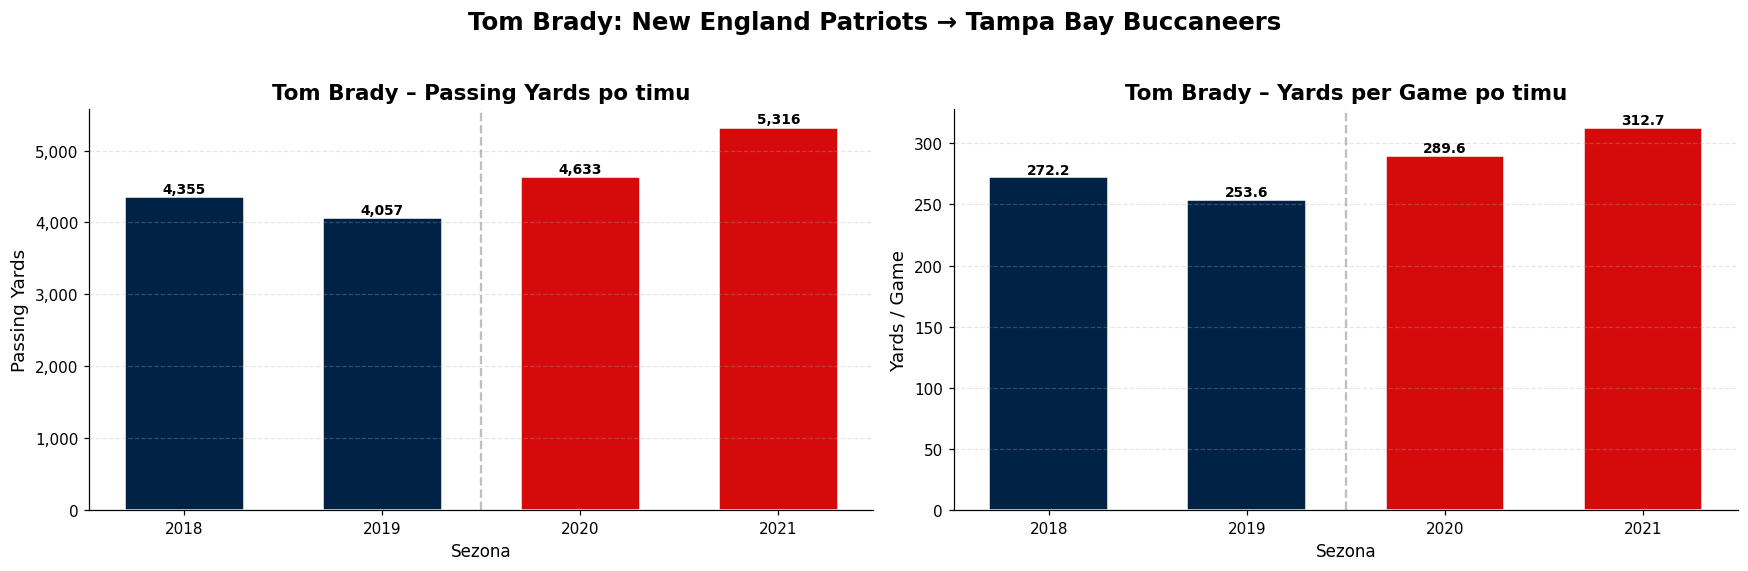

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

qb_df = pd.read_csv('../data/fully combined/qb_master.csv')

# Tom Brady data - poslednje 2 sezone NWE + 2 sezone TAM
brady = qb_df[qb_df['Player'] == 'Tom Brady'][['Season', 'Team', 'G', 'Yds', 'TD', 'Y/G', 'Rate', 'Cmp%']].copy()
brady = brady[brady['G'] > 1]  # Exclude 2008 injury season (1 game) and 2000 (1 game)

# Poslednje 2 pune sezone sa NWE i prve 2 sezone sa TAM
brady_nwe = brady[(brady['Team'] == 'NWE') & (brady['Season'] >= 2018)].sort_values('Season')
brady_tam = brady[(brady['Team'] == 'TAM') & (brady['Season'] <= 2021)].sort_values('Season')
brady_compare = pd.concat([brady_nwe, brady_tam])

# ----- GRAF -----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

colors_team = {'NWE': '#002244', 'TAM': '#D50A0A'}
for team, grp in brady_compare.groupby('Team'):
    ax1.bar(grp['Season'].astype(str), grp['Yds'], color=colors_team[team], edgecolor='white', width=0.6)
    for _, row in grp.iterrows():
        ax1.text(str(int(row['Season'])), row['Yds'] + 60, f"{int(row['Yds']):,}", ha='center', fontsize=9, fontweight='bold')

ax1.set_title('Tom Brady – Passing Yards po timu', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sezona', fontsize=11)
ax1.set_ylabel('Passing Yards', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.axvline(x=1.5, color='grey', linestyle='--', alpha=0.5)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Yards per game comparison
for team, grp in brady_compare.groupby('Team'):
    ax2.bar(grp['Season'].astype(str), grp['Y/G'], color=colors_team[team], edgecolor='white', width=0.6)
    for _, row in grp.iterrows():
        ax2.text(str(int(row['Season'])), row['Y/G'] + 3, f"{row['Y/G']:.1f}", ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Tom Brady – Yards per Game po timu', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sezona', fontsize=11)
ax2.set_ylabel('Yards / Game', fontsize=12)
ax2.axvline(x=1.5, color='grey', linestyle='--', alpha=0.5)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Tom Brady: New England Patriots → Tampa Bay Buccaneers', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()




Promena sredine često predstavlja ključni faktor za restart ili uspon karijere. Brady-jeva produkcija je doživela značajan skok prelaskom iz New England-a u Tampa Bay. Okružen boljim ofanzivnim arsenalom i modernijim sistemom, Brady je u novom timu beležio drastično veći broj jardi nego u svojim poslednjim sezonama u Patriotsima.

#### Saquon Barkley – Giants vs. Eagles



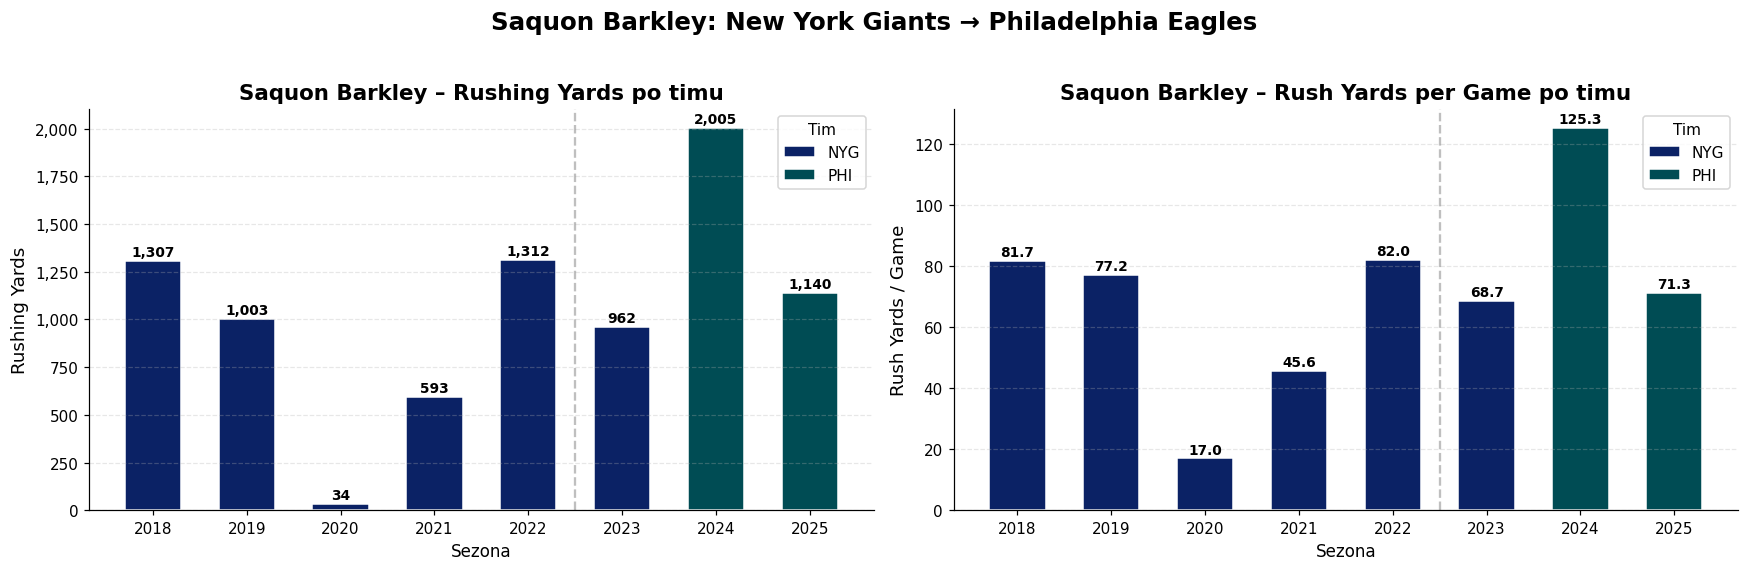

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

rb_df = pd.read_csv('../data/fully combined/rb_master.csv')

# Saquon Barkley data
barkley = rb_df[rb_df['Player'] == 'Saquon Barkley'][['Season', 'Team', 'G', 'Rush_Yds', 'Rush_TD', 'Rush_Y/G', 'Rush_Y/A', 'Rec_Yds']].copy()
barkley = barkley[barkley['G'] > 1]  # Exclude 2020 ACL injury season (2 games)

barkley_nyg = barkley[barkley['Team'] == 'NYG'].sort_values('Season')
barkley_phi = barkley[barkley['Team'] == 'PHI'].sort_values('Season')
barkley_compare = pd.concat([barkley_nyg, barkley_phi])

# ----- GRAF -----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

colors_team = {'NYG': '#0B2265', 'PHI': '#004C54'}
for team, grp in barkley_compare.groupby('Team'):
    ax1.bar(grp['Season'].astype(str), grp['Rush_Yds'], color=colors_team[team], label=team, edgecolor='white', width=0.6)
    for _, row in grp.iterrows():
        ax1.text(str(int(row['Season'])), row['Rush_Yds'] + 25, f"{int(row['Rush_Yds']):,}", ha='center', fontsize=9, fontweight='bold')

ax1.set_title('Saquon Barkley – Rushing Yards po timu', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sezona', fontsize=11)
ax1.set_ylabel('Rushing Yards', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.legend(title='Tim', fontsize=10)
ax1.axvline(x=4.5, color='grey', linestyle='--', alpha=0.5)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Yards per game comparison
for team, grp in barkley_compare.groupby('Team'):
    ax2.bar(grp['Season'].astype(str), grp['Rush_Y/G'], color=colors_team[team], label=team, edgecolor='white', width=0.6)
    for _, row in grp.iterrows():
        ax2.text(str(int(row['Season'])), row['Rush_Y/G'] + 1.5, f"{row['Rush_Y/G']:.1f}", ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Saquon Barkley – Rush Yards per Game po timu', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sezona', fontsize=11)
ax2.set_ylabel('Rush Yards / Game', fontsize=12)
ax2.legend(title='Tim', fontsize=10)
ax2.axvline(x=4.5, color='grey', linestyle='--', alpha=0.5)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Saquon Barkley: New York Giants → Philadelphia Eagles', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()



Saquon Barkley je proveo 6 sezona u New York Giantsima (2018–2023), gde je uprkos talentima bio ograničen lošom ofanzivnom linijom i povredama. Nakon prelaska u Philadelphia Eagles 2024. on eksplodirao sa 2,005 rushing jardi - najboljom sezonom u karijeri.

### Zakljucak za modelovanje

Upravo zbog ovakvih situacija je odlučeno da se doda kolona Team_Changed, boolean kolona koja ima vrednost 1 ako je igrač promenio tim bas te sezone. Ova kolona pomaže modelu da prepozna situacije gde statistički skok nije slučajan, već je rezultat kvalitetnijeg okruženja i boljeg uklapanja u novi sistem igre.